# Integrated Test — Does B's Elaborative Rehearsal Improve QA Accuracy?

`03` established `chunked_sequential` as the uncompressed control this pipeline needs to beat. `07b` finished training B (stage 2) — this is that comparison.


In [98]:
import json
import os
import re
import sys
import threading
import time
from collections import deque
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root != root.parent:
    root = root.parent
sys.path.insert(0, str(root))

from src.notebook_setup import setup_project

setup_project()
API_KEY_SET = bool(os.environ.get("NVIDIA_NIM_API_KEY"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from tqdm.auto import tqdm
import torch
from safetensors.torch import load_file
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

from src.pipeline.embeddings import embed_texts, load_config as load_embed_config
from src.pipeline.rehearsal import rehearse_elaborative, rehearse_elaborative_independent
from src.pipeline.types import Chunk

STAGE2_CHECKPOINT_RATIO0 = True  # set True to use the self_conditioned_ratio=0.0 ablation checkpoint (07b, 2026-08-07) instead of the main run (ratio=0.3) -- the ablation halved the collapse drop (+0.110 -> +0.050) against the teacher

BASE_MODEL_FLANT5 = False

if BASE_MODEL_FLANT5:
    STAGE2_DIR = Path("experiments/rehearsal_elaborative_stage2_flant5base_ratio0")
elif STAGE2_CHECKPOINT_RATIO0:
    STAGE2_DIR = Path("experiments/rehearsal_elaborative_stage2_ratio0")
else:
    STAGE2_DIR = Path("experiments/rehearsal_elaborative_stage2")
STAGE2_READY = STAGE2_DIR.exists()
STAGE2_STATUS = "ready" if STAGE2_READY else "MISSING \u2014 run 07b first"
print(f"STAGE2_CHECKPOINT_RATIO0: {STAGE2_CHECKPOINT_RATIO0}")
print(f"BASE_MODEL_FLANT5: {BASE_MODEL_FLANT5}")
print(f"stage-2 checkpoint: {STAGE2_STATUS} ({STAGE2_DIR})")


def _ckpt_results_path(base_path: str) -> str:
    """Appends a checkpoint-identifying suffix to a results path so
    results from different checkpoints never land in the same file --
    same discipline as every other mechanism change in this notebook
    (delete-before-rerun bugs happened more than once this session from
    skipping this)."""
    if BASE_MODEL_FLANT5:
        suffix = "_flant5base"
    elif STAGE2_CHECKPOINT_RATIO0:
        suffix = "_ratio0chk"
    else:
        return base_path
    stem, dot, ext = base_path.rpartition(".")
    return f"{stem}{suffix}{dot}{ext}"

project root: /Users/lucyroh/Desktop/STUDY/Data Projects/rehearse-then-recall
.env loaded: success ✅
NVIDIA_NIM_API_KEY: set ✅
STAGE2_CHECKPOINT_RATIO0: True
BASE_MODEL_FLANT5: False
stage-2 checkpoint: ready (experiments/rehearsal_elaborative_stage2_ratio0)


## 1. Genres, corpora, questions — identical to `03`

Same files, loaded independently (kept byte-identical) so the eval set matches exactly.


In [76]:
GENRES = {
    "wiki": {
        "corpus_path": "data/processed/wiki_eval/wiki_eval_corpus.txt",
        "questions_path": "data/sample/wiki_eval_questions.csv",
        "format": "extractive",
    },
    "news": {
        "corpus_path": "data/processed/news_eval/news_eval_corpus.txt",
        "questions_path": "data/sample/news_eval_questions.csv",
        "format": "extractive",
    },
    "novel": {
        "corpus_path": "data/processed/narrativeqa_length_stress/novel_eval_corpus.txt",
        "questions_path": "data/sample/narrativeqa_novel_eval_questions.csv",
        "format": "extractive",
    },
    "caselaw": {
        "corpus_path": "data/processed/caselaw_eval/caselaw_eval_corpus.txt",
        "questions_path": "data/sample/caselaw_eval_questions.csv",
        "format": "multiple_choice",
    },
}

corpora: dict[str, str] = {}
questions: dict[str, pd.DataFrame] = {}

for genre, cfg in GENRES.items():
    with open(cfg["corpus_path"], encoding="utf-8") as f:
        corpora[genre] = f.read()
    qdf = pd.read_csv(cfg["questions_path"], encoding="utf-8-sig")
    questions[genre] = qdf
    print(f"{genre:10} format={cfg['format']:16} corpus={len(corpora[genre].split()):>6} words, questions={len(qdf):>4}")

wiki       format=extractive       corpus= 14934 words, questions= 100
news       format=extractive       corpus= 50443 words, questions= 200
novel      format=extractive       corpus= 59027 words, questions=  79
caselaw    format=multiple_choice  corpus= 54403 words, questions= 200


## Shared constants — used throughout, defined early on purpose

Defined early so comparison cells work regardless of run order.


In [132]:
CONDITIONS_ORDER = [
    "closed_book",
    "full_context",
    "chunked_sequential",
    "chunked_sequential_rehearsal",
    "full_context_rehearsal_lookup",
    "full_context_rehearsal_lookup_retrieval",
    "full_context_rehearsal_lookup_adaptive",
    "raw_retrieval_adaptive",
    "gist_retrieval_adaptive",
    "gist_retrieval_gistembed",
    "hybrid_gistselect_rawanswer",
    "extractive_query_aware_adaptive",
    "gist_retrieval_adaptive_mnt128",
    "structural_map_extractive",
    "maintenance_extractive_adaptive",
    "maintenance_extractive_r50",
    "maintenance_extractive_combined",
    "maintenance_extractive_dynamic",
    "gist_threaded_nomerge",
    "maintenance_threaded_nomerge",
    "gist_threaded_weighted",
    "gist_threaded_nucleus",
]
CONDITION_COLORS = {
    "closed_book": "#2a78d6",
    "full_context": "#eb6834",
    "chunked_sequential": "#1baf7a",
    "chunked_sequential_rehearsal": "#a83279",
    "full_context_rehearsal_lookup": "#c9a227",
    "full_context_rehearsal_lookup_retrieval": "#6b4fa0",
    "full_context_rehearsal_lookup_adaptive": "#d6336c",
    "raw_retrieval_adaptive": "#495057",
    "gist_retrieval_adaptive": "#845ec2",
    "gist_retrieval_gistembed": "#ff8066",
    "hybrid_gistselect_rawanswer": "#2dce89",
    "extractive_query_aware_adaptive": "#20c997",
    "gist_retrieval_adaptive_mnt128": "#f4a259",
    "structural_map_extractive": "#4c956c",
    "maintenance_extractive_adaptive": "#7b8b6f",
    "maintenance_extractive_r50": "#5b7553",
    "maintenance_extractive_combined": "#3d8361",
    "maintenance_extractive_dynamic": "#a3b18a",
    "gist_threaded_nomerge": "#0ea5b7",
    "maintenance_threaded_nomerge": "#0a7a86",
    "gist_threaded_weighted": "#0284c7",
    "gist_threaded_nucleus": "#075985",
}

CONDITION_GROUPS = {
    "baselines": ["closed_book", "full_context"],
    "elaborative (B) -- early pipeline": [
        "chunked_sequential", "chunked_sequential_rehearsal",
        "full_context_rehearsal_lookup", "full_context_rehearsal_lookup_retrieval",
        "full_context_rehearsal_lookup_adaptive",
    ],
    "RAG + collapse diagnostic": [
        "raw_retrieval_adaptive", "gist_retrieval_adaptive", "gist_retrieval_gistembed",
        "hybrid_gistselect_rawanswer", "gist_retrieval_adaptive_mnt128",
        "extractive_query_aware_adaptive", "structural_map_extractive",
    ],
    "maintenance (A) revived": [
        "maintenance_extractive_adaptive", "maintenance_extractive_r50",
        "maintenance_extractive_combined", "maintenance_extractive_dynamic",
    ],
    "no-merge thread clustering": ["gist_threaded_nomerge", "maintenance_threaded_nomerge", "gist_threaded_weighted", "gist_threaded_nucleus"],
}
# 2026-08-14: split out once CONDITIONS_ORDER passed ~15 entries -- one flat bar
# chart per plot stopped being readable. Every §14 plot below facets by this
# grouping instead of drawing all conditions in one axes.
GENRE_ORDER = list(GENRES.keys())

baseline_df = pd.read_csv("results/qa_baseline_3conditions.csv", encoding="utf-8-sig")

## 2. Chunking — identical to `03`

Same `paginate_semantic` config, so chunk boundaries match `03`'s exactly.


In [78]:
chunks_by_genre: dict[str, list] = {}

if not API_KEY_SET:
    print("No NVIDIA_NIM_API_KEY \u2014 skipping chunk generation.")
else:
    from src.pipeline.chuncking import paginate_semantic, plain_text_to_paragraphs
    from src.pipeline.embeddings import embed_texts as _embed_texts_for_chunking, load_config as _load_chunk_embed_config

    chunk_cfg = yaml.safe_load(open("configs/chunking.yaml", encoding="utf-8"))
    chunk_embed_cfg = _load_chunk_embed_config("configs/importance_filter.yaml")

    for genre, text in corpora.items():
        paragraphs = plain_text_to_paragraphs(text)
        chunks_by_genre[genre] = paginate_semantic(
            paragraphs,
            min_words=chunk_cfg["min_words"],
            max_words=chunk_cfg["max_words"],
            granularity="paragraph",
            config=chunk_embed_cfg,
            embed_fn=_embed_texts_for_chunking,
        )
        print(f"{genre:10} chunks: {len(chunks_by_genre[genre])}")

wiki       chunks: 107
news       chunks: 390
novel      chunks: 498
caselaw    chunks: 400


## 3. Precompute B's rolling memory state, per genre

B is query-agnostic, so the rolling memory state is the same for every question in a genre — computed once, reused.


In [9]:
MAX_CHUNKS_EXPLORE = 4  # matches 03's budget exactly

memory_states_by_genre: dict[str, list[str]] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    embed_cfg = load_embed_config()
    stage2_tokenizer = AutoTokenizer.from_pretrained(STAGE2_DIR)
    # BUG (2026-08-09/10, see 07b): AutoModelForSeq2SeqLM.from_pretrained()
    # re-ties lm_head.weight to shared.weight on load, silently discarding
    # this checkpoint's actually-trained (and genuinely different)
    # lm_head.weight -- produces fluent-looking garbage generation with no
    # error/warning. Fix: load normally (encoder/decoder embed_tokens stay
    # correctly tied to shared.weight, which is structural to T5 and must
    # survive), then surgically replace just lm_head.weight with the value
    # read straight from the checkpoint's safetensors file.
    stage2_model = AutoModelForSeq2SeqLM.from_pretrained(STAGE2_DIR)
    _state = load_file(str(STAGE2_DIR / "model.safetensors"))
    if "lm_head.weight" in _state:
        # Only some checkpoints (e.g. flan-t5-base-derived ones) actually
        # have a separately-trained lm_head.weight distinct from
        # shared.weight -- t5-small checkpoints here never had that
        # anomaly, so this key is simply absent for them and there is
        # nothing to fix (staying tied is correct in that case).
        stage2_model.lm_head.weight = torch.nn.Parameter(
            _state["lm_head.weight"].to(dtype=stage2_model.lm_head.weight.dtype)
        )
        stage2_model.config.tie_word_embeddings = False
        assert stage2_model.lm_head.weight is not stage2_model.shared.weight, "lm_head got re-tied -- fix didn't take"
        print("lm_head fix applied (checkpoint has a separately-trained lm_head.weight)")
    else:
        print("lm_head.weight not present as a separate key -- checkpoint is genuinely tied, nothing to fix")

    for genre, chunk_list in chunks_by_genre.items():
        explore_chunks = chunk_list[:MAX_CHUNKS_EXPLORE]
        rehearsal_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(explore_chunks)]
        _, records = rehearse_elaborative(
            rehearsal_chunks, stage2_model, stage2_tokenizer, embed_cfg, embed_texts,
            record_memory_state=True,
        )
        memory_states_by_genre[genre] = [r.memory_state for r in records]
        lengths = [len(s.split()) for s in memory_states_by_genre[genre]]
        print(f"{genre:10} memory state lengths (words) by step: {lengths}")

lm_head.weight not present as a separate key -- checkpoint is genuinely tied, nothing to fix
wiki       memory state lengths (words) by step: [53, 53, 106, 159]
news       memory state lengths (words) by step: [50, 100, 150, 200]
novel      memory state lengths (words) by step: [18, 36, 54, 72]
caselaw    memory state lengths (words) by step: [37, 74, 111, 148]


## 4. NIM chat API call

Same implementation as `03` (rate limiter, backoff, usage tracking), duplicated not imported.


In [10]:
QA_MODEL = "meta/llama-3.1-8b-instruct"
QA_API_KEY = os.environ.get("NVIDIA_NIM_API_KEY")
_CHAT_API_URL = "https://integrate.api.nvidia.com/v1/chat/completions"
_RETRYABLE_STATUS = {429, 500, 502, 503, 504}

_usage_local = threading.local()


def last_chat_usage() -> dict | None:
    return getattr(_usage_local, "value", None)


class RateLimiter:
    def __init__(self, max_per_minute: int):
        self.max_per_minute = max_per_minute
        self._lock = threading.Lock()
        self._timestamps: deque = deque()

    def acquire(self) -> None:
        while True:
            with self._lock:
                now = time.time()
                while self._timestamps and now - self._timestamps[0] > 60:
                    self._timestamps.popleft()
                if len(self._timestamps) < self.max_per_minute:
                    self._timestamps.append(now)
                    return
                sleep_for = 60 - (now - self._timestamps[0])
            time.sleep(max(sleep_for, 0.1))


_rate_limiter = RateLimiter(max_per_minute=30)


def call_chat(messages: list[dict], model: str, api_key: str, timeout: float = 120.0, max_retries: int = 3) -> str:
    last_error: Exception | None = None
    for attempt in range(max_retries + 1):
        _rate_limiter.acquire()
        try:
            response = requests.post(
                _CHAT_API_URL,
                headers={"Authorization": f"Bearer {api_key}", "Accept": "application/json"},
                json={"model": model, "messages": messages, "temperature": 0.0},
                timeout=timeout,
            )
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError) as e:
            last_error = e
            if attempt < max_retries:
                time.sleep(3.0 * (attempt + 1))
                continue
            raise RuntimeError(f"NIM chat API call failed (retries exhausted): {e}") from e

        if response.status_code == 200:
            payload = response.json()
            _usage_local.value = payload.get("usage")
            return payload["choices"][0]["message"]["content"]
        if response.status_code in _RETRYABLE_STATUS and attempt < max_retries:
            time.sleep(3.0 * (attempt + 1))
            continue
        raise RuntimeError(f"NIM chat API failed ({response.status_code}): {response.text}")

    raise RuntimeError(f"NIM chat API call failed (retries exhausted): {last_error}")

## 5. Scoring + message builders — identical to `03`

Same `is_correct`, same question-turn prompt.


In [11]:
import requests

_NO_TOOLS_SENTENCE = (
    "Do not use web search or any external tool \u2014 answer using only the information "
    "given to you (or your own prior knowledge)."
)
_OPEN_ANSWER_INSTRUCTION = "Answer with only the answer itself, as briefly as possible (a word or short phrase). No other explanation."
_MC_ANSWER_INSTRUCTION = "Answer with only the number (1-5) of the correct option. No other explanation."
_CONTINUE_SIGNAL = "CONTINUE"


def normalize_answer(text: str) -> str:
    text = re.sub(r"[\s\.,!?'\"()\[\]{}]", "", text)
    return text.lower()


def is_correct_extractive(prediction: str, reference: str) -> bool:
    norm_ref = normalize_answer(reference)
    if not norm_ref:
        return False
    return norm_ref in normalize_answer(prediction)


def parse_option_number(text: str) -> int | None:
    match = re.search(r"[1-5]", text)
    return int(match.group()) if match else None


def is_correct(genre: str, row: pd.Series, prediction: str | None) -> bool:
    if prediction is None:
        return False
    if GENRES[genre]["format"] == "multiple_choice":
        pred_idx = parse_option_number(prediction)
        return pred_idx is not None and (pred_idx - 1) == row["correct_option_index"]
    return is_correct_extractive(prediction, row["answer"])


def _question_turn(genre: str, row: pd.Series) -> dict:
    if GENRES[genre]["format"] == "multiple_choice":
        options_text = "\n".join(f"{i + 1}) {row[f'option_{i}']}" for i in range(5))
        content = f"{_MC_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}\n{options_text}"
    else:
        content = f"{_OPEN_ANSWER_INSTRUCTION}\n\nQuestion: {row['question']}"
    return {"role": "user", "content": content}

## 6. Condition 1 — `chunked_sequential_rehearsal` (B alone, same tiny budget as the raw baseline)

Same loop as `03`'s `chunked_sequential`; only change is showing B's compressed memory state instead of raw chunk text.


In [12]:
def run_chunked_sequential_rehearsal(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Same shape as 03's run_chunked_sequential, except each step shows B's
    compressed rolling memory state instead of the raw chunk text."""
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    states = memory_states_by_genre[genre]
    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You'll be shown a "
            f"running summary of the source text, updated one step at a time (up to {len(states)}). "
            f"After each step, if you're already confident, output {answer_hint}; if not yet confident "
            f"and want to see the next step, output only '{_CONTINUE_SIGNAL}'."
        ),
    }
    messages = [system, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    prediction = None
    steps_used = 0

    for i, state in enumerate(states):
        is_last = i == len(states) - 1
        instruction = (
            f"This is the last step you'll see \u2014 you must answer now ({answer_hint})."
            if is_last
            else f"If you can answer now, do so ({answer_hint}); otherwise output only '{_CONTINUE_SIGNAL}'."
        )
        messages.append(
            {"role": "user", "content": f"[step {i + 1}/{len(states)}]\n{state}\n\n{instruction}"}
        )

        t0 = time.time()
        reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        steps_used = i + 1

        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        messages.append({"role": "assistant", "content": reply})

        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        looks_like_continue = fmt != "multiple_choice" and _CONTINUE_SIGNAL.lower() in reply.strip().lower()
        if fmt == "multiple_choice":
            if candidate is not None:
                prediction = str(candidate)
                break
        elif not looks_like_continue and candidate:
            prediction = candidate
            break

    return {
        "prediction": prediction,
        "api_calls": steps_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }

## 10. Cost gate

579 questions x up to 4 calls each — comparable to `03`'s own run. Checkpoints to a separate file.


In [13]:
CONDITION = "chunked_sequential_rehearsal"
RESULTS_PATH = _ckpt_results_path("results/qa_stage2_rehearsal_condition.csv")
CONFIRM_SPEND = True  # <- flip to True to actually call the QA model (reset 2026-08-07 before testing the new checkpoint)

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {4 * total_questions} QA calls (early-stop usually well under this)")
print(f"CONFIRM_SPEND = {CONFIRM_SPEND}")

questions: 579, up to 2316 QA calls (early-stop usually well under this)
CONFIRM_SPEND = True


In [14]:
def _run_one_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_chunked_sequential_rehearsal(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(RESULTS_PATH):
    existing_df = pd.read_csv(RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {RESULTS_PATH} ({len(existing_df)} rows)")
else:
    existing_df = pd.DataFrame()

done_genres = set()
if len(existing_df):
    for genre, group in existing_df.groupby("genre"):
        if len(group) >= len(questions[genre]):
            done_genres.add(genre)

if not CONFIRM_SPEND:
    print("skipped \u2014 CONFIRM_SPEND is False")
    rehearsal_df = existing_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    rehearsal_df = existing_df
else:
    MAX_WORKERS = 8
    results = existing_df.to_dict("records")
    for genre in GENRES:
        if genre in done_genres:
            print(f"skip (already done): {genre}")
            continue
        if genre not in memory_states_by_genre:
            print(f"skip (no precomputed memory state): {genre}")
            continue

        qdf = questions[genre]
        results = [r for r in results if r["genre"] != genre]
        print(f"running: {genre} ({len(qdf)} questions)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            futures = [executor.submit(_run_one_question, genre, row) for _, row in qdf.iterrows()]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(RESULTS_PATH, index=False)

    rehearsal_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(rehearsal_df)}")

loaded checkpoint: results/qa_stage2_rehearsal_condition_ratio0chk.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


## 8. Condition 2 — `full_context_rehearsal_lookup` (ReadAgent-P: full gist map + selective raw lookup)

Tests full-document gists with selective raw-text lookup, rather than condition 1's tiny fixed budget.


In [15]:
full_gists_by_genre: dict[str, list] = {}

# Gisting is the GPU-bound bottleneck here (~1,200 chunks across the 4
# eval corpora, one generate() call each) -- scripts/gisting_gpu.py runs
# this same loop on a rented GPU and saves the result. Load it back if
# present instead of recomputing locally (2026-08-10).
_PRECOMPUTED_GISTS_PATH = Path(_ckpt_results_path("results/full_gists_by_genre.json"))

if _PRECOMPUTED_GISTS_PATH.exists():
    _raw = json.load(open(_PRECOMPUTED_GISTS_PATH, encoding="utf-8"))
    full_gists_by_genre = {genre: [Chunk(**c) for c in chunk_dicts] for genre, chunk_dicts in _raw.items()}
    for genre, rehearsed in full_gists_by_genre.items():
        raw_words = sum(len(c.original_text.split()) for c in rehearsed)
        gist_words = sum(len(c.text.split()) for c in rehearsed)
        print(f"{genre:10} {len(rehearsed):4} chunks | raw {raw_words:6} words -> "
                f"gist {gist_words:6} words ({gist_words / raw_words:.1%}) [loaded from {_PRECOMPUTED_GISTS_PATH}]")
elif not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    for genre, chunk_list in chunks_by_genre.items():
        full_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(chunk_list)]
        rehearsed, _ = rehearse_elaborative(
            full_chunks, stage2_model, stage2_tokenizer, embed_cfg, embed_texts,
        )
        full_gists_by_genre[genre] = rehearsed
        raw_words = sum(len(c.original_text.split()) for c in rehearsed)
        gist_words = sum(len(c.text.split()) for c in rehearsed)
        print(f"{genre:10} {len(rehearsed):4} chunks | raw {raw_words:6} words -> "
                f"gist {gist_words:6} words ({gist_words / raw_words:.1%})")

wiki        107 chunks | raw  14936 words -> gist   5216 words (34.9%)
news        390 chunks | raw  50444 words -> gist  17466 words (34.6%)


Token indices sequence length is longer than the specified maximum sequence length for this model (642 > 512). Running this sequence through the model will result in indexing errors


novel       498 chunks | raw  59031 words -> gist  20374 words (34.5%)
caselaw     400 chunks | raw  54420 words -> gist  15684 words (28.8%)


## 9. The lookup condition itself

`_parse_lookup_chunks` looks for a literal `LOOKUP: <numbers>` signal token in the reply.


In [16]:
LOOKUP_WINDOW = 2  # +/- chunks shown around each pointed-to chunk
MAX_LOOKUP_CHUNKS = 20  # set from §12's sweep (2026-08-06): w=2,c=20 had the best accuracy (0.350) and combined score of the grid -- not monotonic in cap, so this is a real optimum in the tested range, not just "as high as tested"


def _format_gist_list(rehearsed_chunks) -> str:
    return "\n".join(f"[chunk {c.index}] {c.text}" for c in rehearsed_chunks)


def _parse_lookup_chunks(reply: str, max_index: int) -> list[int] | None:
    """Looks for 'LOOKUP: 4, 24' (any number of comma/space-separated chunk
    numbers). Returns None if the reply isn't asking for a lookup at all."""
    match = re.search(r"LOOKUP:?\s*([\d,\s]+)", reply, re.IGNORECASE)
    if not match:
        return None
    numbers = [int(n) for n in re.findall(r"\d+", match.group(1))]
    valid = [n for n in numbers if 0 <= n <= max_index]
    return valid or None


def _lookup_window_indices(targets: list[int], max_index: int) -> list[int]:
    """Union of +/- LOOKUP_WINDOW around each target, capped at
    MAX_LOOKUP_CHUNKS total. Targets are processed in the order the model
    gave them; once one target's window is included, a further target is
    only added if it fits under the cap without exceeding it -- a model
    naming many chunks doesn't get to blow the raw-text budget open."""
    selected: set[int] = set()
    for target in targets:
        window = set(range(max(0, target - LOOKUP_WINDOW), min(max_index, target + LOOKUP_WINDOW) + 1))
        if selected and len(selected | window) > MAX_LOOKUP_CHUNKS:
            break
        selected |= window
    return sorted(selected)[:MAX_LOOKUP_CHUNKS]


def run_full_context_rehearsal_lookup(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """ReadAgent-P: show every chunk's gist at once (numbered); if that's not
    enough, the model can point at one or more chunk numbers and gets their
    raw text (+/- LOOKUP_WINDOW neighbours, capped at MAX_LOOKUP_CHUNKS) for
    a second, final call.

    The second call is a FRESH short prompt (system + raw text + question),
    not a continuation of the first call's message history. Reusing the full
    history would resend the entire gist block (tens of thousands of tokens
    for caselaw/novel) a second time, burying the one useful addition -- the
    raw text -- behind a duplicate wall of noise. A pilot run confirmed this
    was actively making answers worse: accuracy on lookup-triggered questions
    was far below both full_context and the no-lookup direct-answer path,
    while prompt tokens roughly doubled on every trigger, matching the size
    of the gist block being resent rather than the (much smaller) raw
    addition. Dropping the resend fixes the root cause; MAX_LOOKUP_CHUNKS is
    a separate safety net against a model naming many chunks at once.
    """
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    rehearsed_chunks = full_gists_by_genre[genre]
    max_index = len(rehearsed_chunks) - 1

    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You will be shown a "
            f"gist of every chunk of the source text, each labelled with its chunk number. If you can "
            f"answer confidently from the gists, output {answer_hint}. If not, output "
            f"'LOOKUP: <chunk numbers>' naming one or more chunk numbers most likely to contain the "
            f"answer, and you will be shown their original text."
        ),
    }
    gist_block = {"role": "user", "content": _format_gist_list(rehearsed_chunks)}
    messages = [system, gist_block, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    api_calls = 0
    lookup_used = False

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    total_elapsed += time.time() - t0
    api_calls += 1
    usage = last_chat_usage() or {}
    for key in total_tokens:
        total_tokens[key] += usage.get(key) or 0

    lookup_targets = _parse_lookup_chunks(reply, max_index)

    if lookup_targets is None:
        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)
    else:
        lookup_used = True
        window_indices = _lookup_window_indices(lookup_targets, max_index)
        raw_block = "\n\n".join(f"[chunk {i}]\n{rehearsed_chunks[i].original_text}" for i in window_indices)

        followup_system = {
            "role": "system",
            "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
        }
        followup_messages = [
            followup_system,
            {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
            _question_turn(genre, row),
        ]

        t0 = time.time()
        reply2 = call_chat(followup_messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        api_calls += 1
        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        candidate = parse_option_number(reply2) if fmt == "multiple_choice" else reply2.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else candidate

    return {
        "prediction": prediction,
        "api_calls": api_calls,
        "lookup_used": lookup_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }

## 7. Cost gate

Gist block scales with chunk count (caselaw ~400, wiki ~61) — test on a small slice first.


In [17]:
LOOKUP_CONDITION = "full_context_rehearsal_lookup"
LOOKUP_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_rehearsal_lookup_condition.csv")
LOOKUP_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model (reset 2026-08-07 before testing the new checkpoint)
LOOKUP_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {2 * total_questions} QA calls (1-2 per question)")
print("Gist-block size scales with chunk count \u2014 check the word counts printed in \u00a79 "
      "before running caselaw/novel at full scale.")
print(f"LOOKUP_CONFIRM_SPEND = {LOOKUP_CONFIRM_SPEND}   LOOKUP_PILOT_LIMIT = {LOOKUP_PILOT_LIMIT}")

questions: 579, up to 1158 QA calls (1-2 per question)
Gist-block size scales with chunk count — check the word counts printed in §9 before running caselaw/novel at full scale.
LOOKUP_CONFIRM_SPEND = True   LOOKUP_PILOT_LIMIT = None


## Run the quiz (this is the cell that actually calls the QA model and scores it)

The real loop: asks every question, applies lookup, scores, checkpoints.


In [18]:
def _run_one_lookup_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_full_context_rehearsal_lookup(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row["question_id"]} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": LOOKUP_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(LOOKUP_RESULTS_PATH):
    existing_lookup_df = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {LOOKUP_RESULTS_PATH} ({len(existing_lookup_df)} rows)")
else:
    existing_lookup_df = pd.DataFrame()

if not LOOKUP_CONFIRM_SPEND:
    print("skipped \u2014 LOOKUP_CONFIRM_SPEND is False")
    lookup_df = existing_lookup_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    lookup_df = existing_lookup_df
else:
    MAX_WORKERS_LOOKUP = 4  # lower than the other loops -- each question can be 2 large calls
    results = existing_lookup_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:LOOKUP_PILOT_LIMIT] if LOOKUP_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_LOOKUP) as executor:
            futures = [executor.submit(_run_one_lookup_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(LOOKUP_RESULTS_PATH, index=False)

    lookup_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(lookup_df)}")

loaded checkpoint: results/qa_stage2_rehearsal_lookup_condition_ratio0chk.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


## 10b. Before / after — did the fix work?

Pre-fix pilot CSV was deleted (would've been skipped by the run loop); its numbers are hardcoded below as reference. This cell recomputes "after" fresh from `LOOKUP_RESULTS_PATH`.

**Before (pilot, n=20/genre, pre-fix)**:

| genre | not triggered | triggered | full_context |
|---|---|---|---|
| wiki | 0.600 (n=10) | 0.300 (n=10) | 0.810 |
| news | 0.500 (n=6) | 0.071 (n=14) | 0.395 |
| novel | 0.429 (n=14) | 0.000 (n=4) | 0.494 |
| caselaw | 0.231 (n=13) | 0.000 (n=7) | 0.360 |

Bug signature: accuracy collapsed when lookup fired; tokens roughly doubled (e.g. caselaw 24,719→51,578) matching the resent gist block's size.


In [19]:
BEFORE = {
    "wiki":    {"no_lookup": 0.600, "lookup": 0.300},
    "news":    {"no_lookup": 0.500, "lookup": 0.071},
    "novel":   {"no_lookup": 0.429, "lookup": 0.000},
    "caselaw": {"no_lookup": 0.231, "lookup": 0.000},
}

lookup_df = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(LOOKUP_RESULTS_PATH) else pd.DataFrame()

if lookup_df.empty:
    print(f"No data yet in {LOOKUP_RESULTS_PATH} -- run \u00a710's loop first.")
else:
    after_acc = lookup_df.groupby(["genre", "lookup_used"])["correct"].agg(["mean", "count"])
    after_tokens = lookup_df.groupby(["genre", "lookup_used"])["prompt_tokens"].mean()

    header_row = f"{'genre':10} {'before(no-lookup)':>18} {'after(no-lookup)':>18} {'before(lookup)':>16} {'after(lookup)':>15}"
    print(header_row)
    for genre in GENRE_ORDER:
        before = BEFORE.get(genre, {})
        before_no = before.get("no_lookup", float("nan"))
        before_yes = before.get("lookup", float("nan"))
        after_no = after_acc.loc[(genre, False), "mean"] if (genre, False) in after_acc.index else float("nan")
        after_yes = after_acc.loc[(genre, True), "mean"] if (genre, True) in after_acc.index else float("nan")
        print(f"{genre:10} {before_no:>18.3f} {after_no:>18.3f} {before_yes:>16.3f} {after_yes:>15.3f}")

    print("\navg prompt tokens when lookup triggers (after fix, should be far below the ~2x-of-no-lookup pattern seen before):")
    print(after_tokens)

genre       before(no-lookup)   after(no-lookup)   before(lookup)   after(lookup)
wiki                    0.600              0.733            0.300           0.341
news                    0.500              0.176            0.071           0.024
novel                   0.429              0.100            0.000           0.026
caselaw                 0.231              0.250            0.000           0.260

avg prompt tokens when lookup triggers (after fix, should be far below the ~2x-of-no-lookup pattern seen before):
genre    lookup_used
caselaw  False          24445.000000
         True           26591.894231
news     False          24457.418919
         True           26251.666667
novel    False          30312.850000
         True           32878.846154
wiki     False           7175.333333
         True            9040.517647
Name: prompt_tokens, dtype: float64


## 10c. Condition 3 — `full_context_rehearsal_lookup_retrieval` (lookup + embedding-similarity targeting)

Adds embedding-similarity targeting on top of the base lookup condition.


In [20]:
from src.pipeline.embeddings import embed_with_retry, cosine_similarity

EMBED_RETRIEVAL_TOP_K = 3
RELATED_CHUNKS_TOP_M = 2  # per named chunk, how many content-related (not just adjacent) chunks to also pull in

chunk_embeddings_by_genre: dict[str, list] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    for genre, rehearsed_chunks in full_gists_by_genre.items():
        raw_texts = [c.original_text for c in rehearsed_chunks]
        embeddings = embed_with_retry(raw_texts, "passage", embed_cfg, embed_texts)
        if embeddings is None:
            print(f"{genre:10} embedding failed \u2014 retrieval augmentation unavailable for this genre")
            continue
        chunk_embeddings_by_genre[genre] = embeddings
        print(f"{genre:10} embedded {len(embeddings)} raw chunks for retrieval")

wiki       embedded 107 raw chunks for retrieval
news       embedded 390 raw chunks for retrieval
novel      embedded 498 raw chunks for retrieval
caselaw    embedded 400 raw chunks for retrieval


### The retrieval-augmented lookup function

Same shape as the base lookup function; only difference is what feeds `_lookup_window_indices` (embedding top-K added).


In [21]:
def _embedding_top_k(genre: str, question: str, k: int) -> list[int]:
    if genre not in chunk_embeddings_by_genre:
        return []
    query_embedding = embed_with_retry([question], "query", embed_cfg, embed_texts)
    if query_embedding is None:
        return []
    scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre])]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [i for i, _ in scored[:k]]


def _related_chunks(genre: str, chunk_index: int, m: int) -> list[int]:
    """Chunks related in *content* to chunk_index, wherever they sit in the
    document -- a cheap, embedding-only proxy for RST-LoRA's "relations
    between spans" idea (Liu & Demberg, NAACL 2024, arXiv:2405.00657):
    that paper types discourse relations (elaborates/contrasts/background)
    via a trained RST parser + LoRA adapter, which is a training-time method
    this project doesn't have the infra or time budget to add right now.
    This borrows the underlying instinct -- relatedness beats proximity --
    using cosine similarity between chunk embeddings we already computed,
    so it costs zero extra API calls."""
    if genre not in chunk_embeddings_by_genre:
        return []
    embeddings = chunk_embeddings_by_genre[genre]
    target_embedding = embeddings[chunk_index]
    scored = [
        (i, cosine_similarity(target_embedding, emb))
        for i, emb in enumerate(embeddings) if i != chunk_index
    ]
    scored.sort(key=lambda x: x[1], reverse=True)
    return [i for i, _ in scored[:m]]


def run_full_context_rehearsal_lookup_retrieval(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Base lookup condition, plus: when the model asks for a lookup, the
    chunks shown are the union of (a) what it named, (b) the top
    EMBED_RETRIEVAL_TOP_K chunks by embedding similarity to the *question*,
    and (c) each named chunk's own top RELATED_CHUNKS_TOP_M most similar
    *other* chunks by embedding similarity (content-related, not just
    positionally adjacent) -- (b) recovers a right answer even when the
    model's own chunk-number guess is wrong; (c) recovers supporting detail
    scattered elsewhere in the document that a pure position window would
    miss."""
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    rehearsed_chunks = full_gists_by_genre[genre]
    max_index = len(rehearsed_chunks) - 1

    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You will be shown a "
            f"gist of every chunk of the source text, each labelled with its chunk number. If you can "
            f"answer confidently from the gists, output {answer_hint}. If not, output "
            f"'LOOKUP: <chunk numbers>' naming one or more chunk numbers most likely to contain the "
            f"answer, and you will be shown their original text."
        ),
    }
    gist_block = {"role": "user", "content": _format_gist_list(rehearsed_chunks)}
    messages = [system, gist_block, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    api_calls = 0
    lookup_used = False

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    total_elapsed += time.time() - t0
    api_calls += 1
    usage = last_chat_usage() or {}
    for key in total_tokens:
        total_tokens[key] += usage.get(key) or 0

    lookup_targets = _parse_lookup_chunks(reply, max_index)

    if lookup_targets is None:
        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)
    else:
        lookup_used = True
        retrieved = _embedding_top_k(genre, row["question"], EMBED_RETRIEVAL_TOP_K)
        related = [i for target in lookup_targets for i in _related_chunks(genre, target, RELATED_CHUNKS_TOP_M)]
        window_indices = _lookup_window_indices(lookup_targets + retrieved + related, max_index)
        raw_block = "\n\n".join(f"[chunk {i}]\n{rehearsed_chunks[i].original_text}" for i in window_indices)

        followup_system = {
            "role": "system",
            "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
        }
        followup_messages = [
            followup_system,
            {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
            _question_turn(genre, row),
        ]

        t0 = time.time()
        reply2 = call_chat(followup_messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        api_calls += 1
        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        candidate = parse_option_number(reply2) if fmt == "multiple_choice" else reply2.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else candidate

    return {
        "prediction": prediction,
        "api_calls": api_calls,
        "lookup_used": lookup_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }

### Cost gate


In [22]:
RETRIEVAL_CONDITION = "full_context_rehearsal_lookup_retrieval"
RETRIEVAL_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_rehearsal_lookup_retrieval_condition.csv")
RETRIEVAL_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model (reset 2026-08-07 before testing the new checkpoint)
RETRIEVAL_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {2 * total_questions} QA calls (1-2 per question) "
      f"plus 1 query-embedding call per lookup-triggered question")
print(f"RETRIEVAL_CONFIRM_SPEND = {RETRIEVAL_CONFIRM_SPEND}   RETRIEVAL_PILOT_LIMIT = {RETRIEVAL_PILOT_LIMIT}")

questions: 579, up to 1158 QA calls (1-2 per question) plus 1 query-embedding call per lookup-triggered question
RETRIEVAL_CONFIRM_SPEND = True   RETRIEVAL_PILOT_LIMIT = None


### Run the quiz


In [23]:
def _run_one_retrieval_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_full_context_rehearsal_lookup_retrieval(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": RETRIEVAL_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(RETRIEVAL_RESULTS_PATH):
    existing_retrieval_df = pd.read_csv(RETRIEVAL_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {RETRIEVAL_RESULTS_PATH} ({len(existing_retrieval_df)} rows)")
else:
    existing_retrieval_df = pd.DataFrame()

if not RETRIEVAL_CONFIRM_SPEND:
    print("skipped \u2014 RETRIEVAL_CONFIRM_SPEND is False")
    retrieval_df = existing_retrieval_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    retrieval_df = existing_retrieval_df
else:
    MAX_WORKERS_RETRIEVAL = 4
    results = existing_retrieval_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:RETRIEVAL_PILOT_LIMIT] if RETRIEVAL_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_RETRIEVAL) as executor:
            futures = [executor.submit(_run_one_retrieval_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(RETRIEVAL_RESULTS_PATH, index=False)

    retrieval_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(retrieval_df)}")

loaded checkpoint: results/qa_stage2_rehearsal_lookup_retrieval_condition_ratio0chk.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


### Compare against the base lookup condition and `full_context`


In [24]:
base_lookup_df = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(LOOKUP_RESULTS_PATH) else pd.DataFrame()
retrieval_df = pd.read_csv(RETRIEVAL_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(RETRIEVAL_RESULTS_PATH) else pd.DataFrame()
full_context_acc = baseline_df[baseline_df["condition"] == "full_context"].groupby("genre")["correct"].mean()
base_lookup_acc = base_lookup_df.groupby("genre")["correct"].mean() if not base_lookup_df.empty else pd.Series(dtype=float)
retrieval_acc = retrieval_df.groupby("genre")["correct"].mean() if not retrieval_df.empty else pd.Series(dtype=float)

print(f"{'genre':10} {'full_context':>14} {'lookup':>10} {'lookup+retrieval':>18}")
for g in GENRE_ORDER:
    fc = full_context_acc.get(g, float("nan"))
    bl = base_lookup_acc.get(g, float("nan"))
    rt = retrieval_acc.get(g, float("nan"))
    print(f"{g:10} {fc:>14.3f} {bl:>10.3f} {rt:>18.3f}")

genre        full_context     lookup   lookup+retrieval
wiki                0.810      0.400              0.660
news                0.395      0.080              0.255
novel               0.494      0.063              0.215
caselaw             0.360      0.255              0.235


## 12. Tuning `LOOKUP_WINDOW` / `MAX_LOOKUP_CHUNKS` — grid sweep

Both were first-guess values, never tuned. Grid over accuracy/token trade-off.


In [25]:
SWEEP_WINDOW_GRID = [2]  # window mostly matters for near-miss forgiveness; cap is the cost axis that matters here
SWEEP_CAP_GRID = [5, 10, 20, 40]  # 40 chunks * ~200 words = ~8000 words, still well under full_context's cost everywhere
SWEEP_PILOT_LIMIT = None  # questions per genre per (window, cap) combo
SWEEP_COST_LAMBDA = 0.05  # weight on token cost in the combined score below
SWEEP_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
SWEEP_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_lookup_sweep.csv")

sweep_combos = [(w, c) for w in SWEEP_WINDOW_GRID for c in SWEEP_CAP_GRID if c >= 2 * w + 1]
skipped_combos = [(w, c) for w in SWEEP_WINDOW_GRID for c in SWEEP_CAP_GRID if c < 2 * w + 1]
questions_per_combo = sum(len(questions[g]) if SWEEP_PILOT_LIMIT is None else min(len(questions[g]), SWEEP_PILOT_LIMIT) for g in GENRES)
print(f"{len(sweep_combos)} combos ({skipped_combos} skipped as cap < window span) "
      f"x {questions_per_combo} questions/combo x up to 2 calls "
      f"= up to {len(sweep_combos) * questions_per_combo * 2} calls")
print(f"SWEEP_CONFIRM_SPEND = {SWEEP_CONFIRM_SPEND}")

4 combos ([] skipped as cap < window span) x 579 questions/combo x up to 2 calls = up to 4632 calls
SWEEP_CONFIRM_SPEND = True


In [26]:
def _run_sweep_combo(window: int, cap: int, done_keys: set) -> list[dict]:
    global LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS
    LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS = window, cap

    def _one(genre, row):
        try:
            outcome = run_full_context_rehearsal_lookup(genre, row, QA_MODEL, QA_API_KEY)
        except Exception as e:
            outcome = {
                "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
                "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
            }
            tqdm.write(f"  [w={window} c={cap} {genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
        return {
            "window": window, "cap": cap, "genre": genre, "question_id": row["question_id"],
            "correct": is_correct(genre, row, outcome["prediction"]),
            **outcome,
        }

    todo = [
        (genre, row) for genre in GENRES
        for _, row in questions[genre].iloc[:SWEEP_PILOT_LIMIT].iterrows()
        if (window, cap, genre, str(row["question_id"])) not in done_keys
    ]
    if not todo:
        return []

    rows = []
    with ThreadPoolExecutor(max_workers=4) as executor:
        futures = [executor.submit(_one, genre, row) for genre, row in todo]
        for future in tqdm(as_completed(futures), total=len(futures), desc=f"w={window} c={cap}"):
            rows.append(future.result())
    return rows


if os.path.exists(SWEEP_RESULTS_PATH):
    existing_sweep_df = pd.read_csv(SWEEP_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {SWEEP_RESULTS_PATH} ({len(existing_sweep_df)} rows)")
else:
    existing_sweep_df = pd.DataFrame()

if not SWEEP_CONFIRM_SPEND:
    print("skipped \u2014 SWEEP_CONFIRM_SPEND is False")
    sweep_df = existing_sweep_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    sweep_df = existing_sweep_df
else:
    _orig_window, _orig_cap = LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS
    results = existing_sweep_df.to_dict("records")
    done_keys = {(r["window"], r["cap"], r["genre"], str(r["question_id"])) for r in results}

    for window, cap in sweep_combos:
        new_rows = _run_sweep_combo(window, cap, done_keys)
        if new_rows:
            results.extend(new_rows)
            pd.DataFrame(results).to_csv(SWEEP_RESULTS_PATH, index=False)

    LOOKUP_WINDOW, MAX_LOOKUP_CHUNKS = _orig_window, _orig_cap  # restore the notebook's real settings
    sweep_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(sweep_df)}  (LOOKUP_WINDOW/MAX_LOOKUP_CHUNKS restored to {_orig_window}/{_orig_cap})")

loaded checkpoint: results/qa_stage2_lookup_sweep_ratio0chk.csv (2316 rows)

total results: 2316  (LOOKUP_WINDOW/MAX_LOOKUP_CHUNKS restored to 2/20)


### Sweep results

`accuracy - SWEEP_COST_LAMBDA * (avg_tokens / 10_000)` combines both axes
into one ranking; the scatter plot underneath shows the raw trade-off so
that ranking's arbitrariness stays visible rather than hidden.


 window  cap  accuracy   avg_tokens lookup_rate   n    score
      2   40  0.212435 24589.968912    0.639033 579 0.089485
      2   20  0.191710 23760.155440    0.642487 579 0.072909
      2   10  0.183074 23391.172712     0.64076 579 0.066118
      2    5  0.174439 23105.159170    0.653979 579 0.058913


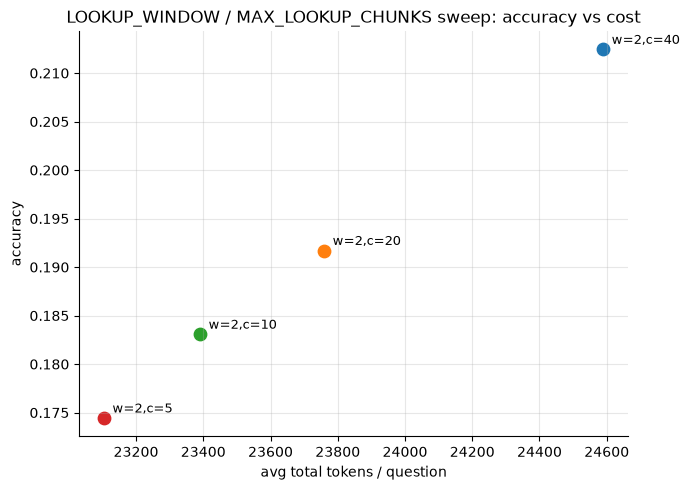

In [27]:
sweep_df = pd.read_csv(SWEEP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(SWEEP_RESULTS_PATH) else pd.DataFrame()

if sweep_df.empty:
    print(f"No data yet in {SWEEP_RESULTS_PATH} -- set SWEEP_CONFIRM_SPEND = True above and run the sweep first.")
else:
    summary = sweep_df.groupby(["window", "cap"]).agg(
        accuracy=("correct", "mean"),
        avg_tokens=("total_tokens", "mean"),
        lookup_rate=("lookup_used", "mean"),
        n=("correct", "count"),
    ).reset_index()
    summary["score"] = summary["accuracy"] - SWEEP_COST_LAMBDA * (summary["avg_tokens"] / 10_000)
    summary = summary.sort_values("score", ascending=False)
    print(summary.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 5))
    for _, r in summary.iterrows():
        ax.scatter(r["avg_tokens"], r["accuracy"], s=80)
        ax.annotate(f"w={r['window']},c={r['cap']}", (r["avg_tokens"], r["accuracy"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=9)
    ax.set_xlabel("avg total tokens / question")
    ax.set_ylabel("accuracy")
    ax.set_title("LOOKUP_WINDOW / MAX_LOOKUP_CHUNKS sweep: accuracy vs cost")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 13. Condition 4 — `full_context_rehearsal_lookup_adaptive` (adaptive-k lookup, generalizable, no per-genre tuning)

Replaces the retired per-genre cap with one mechanism: keep chunks within a relative margin of the top similarity score.


In [28]:
ADAPTIVE_RELATIVE_THRESHOLD = 0.85  # keep chunks scoring within this fraction of the top similarity score
ADAPTIVE_TARGET_WINDOW = 1  # small fixed window around the model's own named chunk(s), always included
ADAPTIVE_SAFETY_CAP = 40  # hard ceiling regardless of how many chunks pass the threshold -- a safety bound, not a tuned value


def _adaptive_chunk_selection(scored: list[tuple[int, float]], relative_threshold: float, safety_cap: int) -> list[int]:
    """Adaptive-k (arXiv:2506.08479): how many chunks are 'good enough' is
    decided by the shape of this question's own similarity-score
    distribution, not a fixed count or a per-genre table -- generalizes to
    any new document/domain without retuning."""
    if not scored:
        return []
    ranked = sorted(scored, key=lambda x: x[1], reverse=True)
    top_score = ranked[0][1]
    if top_score <= 0:
        return [ranked[0][0]]
    cutoff = top_score * relative_threshold
    selected = [i for i, score in ranked if score >= cutoff]
    return selected[:safety_cap]


def run_full_context_rehearsal_lookup_adaptive(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Same first call as the other lookup conditions. When lookup triggers,
    the raw chunks shown are chosen adaptively -- see \u00a714's header --
    instead of by any fixed count or genre-keyed table."""
    fmt = GENRES[genre]["format"]
    answer_hint = "a number 1-5" if fmt == "multiple_choice" else "a short answer"
    rehearsed_chunks = full_gists_by_genre[genre]
    max_index = len(rehearsed_chunks) - 1

    system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are an assistant that answers questions. You will be shown a "
            f"gist of every chunk of the source text, each labelled with its chunk number. If you can "
            f"answer confidently from the gists, output {answer_hint}. If not, output "
            f"'LOOKUP: <chunk numbers>' naming one or more chunk numbers most likely to contain the "
            f"answer, and you will be shown their original text."
        ),
    }
    gist_block = {"role": "user", "content": _format_gist_list(rehearsed_chunks)}
    messages = [system, gist_block, _question_turn(genre, row)]

    total_elapsed = 0.0
    total_tokens = {"prompt_tokens": 0, "completion_tokens": 0, "total_tokens": 0}
    api_calls = 0
    lookup_used = False

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    total_elapsed += time.time() - t0
    api_calls += 1
    usage = last_chat_usage() or {}
    for key in total_tokens:
        total_tokens[key] += usage.get(key) or 0

    lookup_targets = _parse_lookup_chunks(reply, max_index)

    if lookup_targets is None:
        candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)
    else:
        lookup_used = True

        query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
        if query_embedding is not None and genre in chunk_embeddings_by_genre:
            scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre])]
            adaptive_selected = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
        else:
            adaptive_selected = []

        target_window: set[int] = set()
        for target in lookup_targets:
            target_window |= set(range(max(0, target - ADAPTIVE_TARGET_WINDOW), min(max_index, target + ADAPTIVE_TARGET_WINDOW) + 1))

        window_indices = sorted(set(adaptive_selected) | target_window)[:ADAPTIVE_SAFETY_CAP]
        raw_block = "\n\n".join(f"[chunk {i}]\n{rehearsed_chunks[i].original_text}" for i in window_indices)

        followup_system = {
            "role": "system",
            "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
        }
        followup_messages = [
            followup_system,
            {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
            _question_turn(genre, row),
        ]

        t0 = time.time()
        reply2 = call_chat(followup_messages, model=model, api_key=api_key, timeout=120.0)
        total_elapsed += time.time() - t0
        api_calls += 1
        usage = last_chat_usage() or {}
        for key in total_tokens:
            total_tokens[key] += usage.get(key) or 0

        candidate = parse_option_number(reply2) if fmt == "multiple_choice" else reply2.strip()
        prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else candidate

    return {
        "prediction": prediction,
        "api_calls": api_calls,
        "lookup_used": lookup_used,
        "elapsed_seconds": round(total_elapsed, 1),
        "prompt_tokens": total_tokens["prompt_tokens"],
        "completion_tokens": total_tokens["completion_tokens"],
        "total_tokens": total_tokens["total_tokens"],
    }

### Cost gate


In [29]:
ADAPTIVE_CONDITION = "full_context_rehearsal_lookup_adaptive"
ADAPTIVE_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_rehearsal_lookup_adaptive_condition.csv")
ADAPTIVE_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model (reset 2026-08-07 before testing the new checkpoint)
ADAPTIVE_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, up to {2 * total_questions} QA calls (1-2 per question) "
      f"plus 1 query-embedding call per lookup-triggered question")
print(f"ADAPTIVE_RELATIVE_THRESHOLD = {ADAPTIVE_RELATIVE_THRESHOLD}   ADAPTIVE_SAFETY_CAP = {ADAPTIVE_SAFETY_CAP}")
print(f"ADAPTIVE_CONFIRM_SPEND = {ADAPTIVE_CONFIRM_SPEND}   ADAPTIVE_PILOT_LIMIT = {ADAPTIVE_PILOT_LIMIT}")

questions: 579, up to 1158 QA calls (1-2 per question) plus 1 query-embedding call per lookup-triggered question
ADAPTIVE_RELATIVE_THRESHOLD = 0.85   ADAPTIVE_SAFETY_CAP = 40
ADAPTIVE_CONFIRM_SPEND = True   ADAPTIVE_PILOT_LIMIT = None


### Run the quiz


In [30]:
def _run_one_adaptive_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_full_context_rehearsal_lookup_adaptive(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": ADAPTIVE_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(ADAPTIVE_RESULTS_PATH):
    existing_adaptive_df = pd.read_csv(ADAPTIVE_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {ADAPTIVE_RESULTS_PATH} ({len(existing_adaptive_df)} rows)")
else:
    existing_adaptive_df = pd.DataFrame()

if not ADAPTIVE_CONFIRM_SPEND:
    print("skipped \u2014 ADAPTIVE_CONFIRM_SPEND is False")
    adaptive_df = existing_adaptive_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    adaptive_df = existing_adaptive_df
else:
    MAX_WORKERS_ADAPTIVE = 4
    results = existing_adaptive_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:ADAPTIVE_PILOT_LIMIT] if ADAPTIVE_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_ADAPTIVE) as executor:
            futures = [executor.submit(_run_one_adaptive_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(ADAPTIVE_RESULTS_PATH, index=False)

    adaptive_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(adaptive_df)}")


loaded checkpoint: results/qa_stage2_rehearsal_lookup_adaptive_condition_ratio0chk.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


### Compare against `full_context` and every prior condition

Also reports avg chunks selected per genre — should be small for caselaw-like cases, larger elsewhere.


In [31]:
full_context_acc = baseline_df[baseline_df["condition"] == "full_context"].groupby("genre")["correct"].mean()
lookup_acc_cmp2 = pd.read_csv(LOOKUP_RESULTS_PATH, encoding="utf-8-sig").groupby("genre")["correct"].mean() if os.path.exists(LOOKUP_RESULTS_PATH) else pd.Series(dtype=float)
retrieval_acc_cmp2 = pd.read_csv(RETRIEVAL_RESULTS_PATH, encoding="utf-8-sig").groupby("genre")["correct"].mean() if os.path.exists(RETRIEVAL_RESULTS_PATH) else pd.Series(dtype=float)
adaptive_df = pd.read_csv(ADAPTIVE_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(ADAPTIVE_RESULTS_PATH) else pd.DataFrame()
adaptive_acc_cmp = adaptive_df.groupby("genre")["correct"].mean() if not adaptive_df.empty else pd.Series(dtype=float)

print(f"{'genre':10} {'full_context':>13} {'lookup':>9} {'+retrieval':>11} {'+adaptive':>10}")
for g in GENRE_ORDER:
    fc = full_context_acc.get(g, float("nan"))
    lk = lookup_acc_cmp2.get(g, float("nan"))
    rt = retrieval_acc_cmp2.get(g, float("nan"))
    ad = adaptive_acc_cmp.get(g, float("nan"))
    print(f"{g:10} {fc:>13.3f} {lk:>9.3f} {rt:>11.3f} {ad:>10.3f}")

if not adaptive_df.empty:
    triggered = adaptive_df[adaptive_df["lookup_used"] == True]
    if not triggered.empty:
        avg_tokens_triggered = triggered.groupby("genre")["total_tokens"].mean()
        print("\navg total tokens on lookup-triggered questions, by genre (proxy for how many chunks the adaptive selection chose):")
        print(avg_tokens_triggered)


genre       full_context    lookup  +retrieval  +adaptive
wiki               0.810     0.400       0.660      0.760
news               0.395     0.080       0.255      0.255
novel              0.494     0.063       0.215      0.177
caselaw            0.360     0.255       0.235      0.275

avg total tokens on lookup-triggered questions, by genre (proxy for how many chunks the adaptive selection chose):
genre
caselaw    33658.565657
news       28193.111940
novel      35147.770833
wiki       10022.144444
Name: total_tokens, dtype: float64


### 13b. Tuning `ADAPTIVE_RELATIVE_THRESHOLD`

0.85 was never tuned. `cutoff = top_score * relative_threshold` — higher threshold = stricter. Swept {0.75, 0.85, 0.90, 0.95, 0.98} x n=10/genre over all 4 genres.


In [32]:
ADAPTIVE_SWEEP_GRID = [0.75, 0.85, 0.90, 0.95, 0.98]  # current default (0.85) included as a reference point
ADAPTIVE_SWEEP_PILOT_LIMIT = 10  # questions per genre per threshold value
ADAPTIVE_SWEEP_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
ADAPTIVE_SWEEP_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_adaptive_threshold_sweep.csv")

questions_per_threshold = sum(min(len(questions[g]), ADAPTIVE_SWEEP_PILOT_LIMIT) for g in GENRES)
print(f"{len(ADAPTIVE_SWEEP_GRID)} thresholds x {questions_per_threshold} questions/threshold x up to 2 calls "
      f"= up to {len(ADAPTIVE_SWEEP_GRID) * questions_per_threshold * 2} calls")
print(f"ADAPTIVE_SWEEP_CONFIRM_SPEND = {ADAPTIVE_SWEEP_CONFIRM_SPEND}")

5 thresholds x 40 questions/threshold x up to 2 calls = up to 400 calls
ADAPTIVE_SWEEP_CONFIRM_SPEND = True


In [33]:
def _run_adaptive_sweep_value(threshold: float, done_keys: set) -> list[dict]:
    global ADAPTIVE_RELATIVE_THRESHOLD
    ADAPTIVE_RELATIVE_THRESHOLD = threshold

    def _one(genre, row):
        try:
            outcome = run_full_context_rehearsal_lookup_adaptive(genre, row, QA_MODEL, QA_API_KEY)
        except Exception as e:
            outcome = {
                "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
                "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
            }
            tqdm.write(f"  [t={threshold} {genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
        return {
            "threshold": threshold, "genre": genre, "question_id": row["question_id"],
            "correct": is_correct(genre, row, outcome["prediction"]),
            **outcome,
        }

    todo = [
        (genre, row) for genre in GENRES
        for _, row in questions[genre].iloc[:ADAPTIVE_SWEEP_PILOT_LIMIT].iterrows()
        if (threshold, genre, str(row["question_id"])) not in done_keys
    ]
    if not todo:
        return []

    rows = []
    with ThreadPoolExecutor(max_workers=4) as executor:
        futures = [executor.submit(_one, genre, row) for genre, row in todo]
        for future in tqdm(as_completed(futures), total=len(futures), desc=f"threshold={threshold}"):
            rows.append(future.result())
    return rows


if os.path.exists(ADAPTIVE_SWEEP_RESULTS_PATH):
    existing_adaptive_sweep_df = pd.read_csv(ADAPTIVE_SWEEP_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {ADAPTIVE_SWEEP_RESULTS_PATH} ({len(existing_adaptive_sweep_df)} rows)")
else:
    existing_adaptive_sweep_df = pd.DataFrame()

if not ADAPTIVE_SWEEP_CONFIRM_SPEND:
    print("skipped \u2014 ADAPTIVE_SWEEP_CONFIRM_SPEND is False")
    adaptive_sweep_df = existing_adaptive_sweep_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    adaptive_sweep_df = existing_adaptive_sweep_df
else:
    _orig_threshold = ADAPTIVE_RELATIVE_THRESHOLD
    results = existing_adaptive_sweep_df.to_dict("records")
    done_keys = {(r["threshold"], r["genre"], str(r["question_id"])) for r in results}

    for threshold in ADAPTIVE_SWEEP_GRID:
        new_rows = _run_adaptive_sweep_value(threshold, done_keys)
        results.extend(new_rows)
        adaptive_sweep_df = pd.DataFrame(results)
        adaptive_sweep_df.to_csv(ADAPTIVE_SWEEP_RESULTS_PATH, index=False, encoding="utf-8-sig")

    ADAPTIVE_RELATIVE_THRESHOLD = _orig_threshold  # restore -- the sweep's job is to inform this, not silently change it
    print(f"done. ADAPTIVE_RELATIVE_THRESHOLD restored to {ADAPTIVE_RELATIVE_THRESHOLD} (set it above by hand once you've read the results below)")

loaded checkpoint: results/qa_stage2_adaptive_threshold_sweep_ratio0chk.csv (200 rows)
done. ADAPTIVE_RELATIVE_THRESHOLD restored to 0.85 (set it above by hand once you've read the results below)


### Sweep results


genre      wiki  news  novel  caselaw  overall
threshold                                     
0.75        0.9   0.1    0.2      0.4     0.40
0.85        0.9   0.1    0.4      0.4     0.45
0.90        0.9   0.1    0.4      0.4     0.45
0.95        0.9   0.1    0.2      0.4     0.40
0.98        0.9   0.1    0.3      0.5     0.45

best caselaw threshold: 0.98 (caselaw 0.500 vs current-default 0.85's 0.400, per-genre-cap reference 0.450)


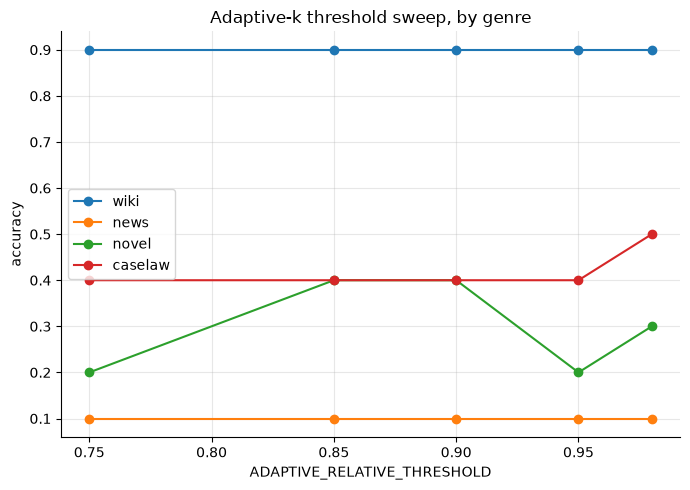

In [34]:
adaptive_sweep_df = pd.read_csv(ADAPTIVE_SWEEP_RESULTS_PATH, encoding="utf-8-sig") if os.path.exists(ADAPTIVE_SWEEP_RESULTS_PATH) else pd.DataFrame()

if adaptive_sweep_df.empty:
    print(f"No data yet in {ADAPTIVE_SWEEP_RESULTS_PATH} -- set ADAPTIVE_SWEEP_CONFIRM_SPEND = True above and run the sweep first.")
else:
    per_genre = adaptive_sweep_df.groupby(["threshold", "genre"])["correct"].mean().unstack("genre")
    per_genre = per_genre.reindex(columns=[g for g in GENRE_ORDER if g in per_genre.columns])
    per_genre["overall"] = adaptive_sweep_df.groupby("threshold")["correct"].mean()
    print(per_genre.round(3).to_string())

    best_caselaw_threshold = per_genre["caselaw"].idxmax() if "caselaw" in per_genre.columns else None
    print(f"\nbest caselaw threshold: {best_caselaw_threshold} "
          f"(caselaw {per_genre.loc[best_caselaw_threshold, 'caselaw']:.3f} vs current-default 0.85's "
          f"{per_genre.loc[0.85, 'caselaw'] if 0.85 in per_genre.index else float('nan'):.3f}, "
          f"per-genre-cap reference 0.450)")

    fig, ax = plt.subplots(figsize=(7, 5))
    for genre in [g for g in GENRE_ORDER if g in per_genre.columns]:
        ax.plot(per_genre.index, per_genre[genre], marker="o", label=genre, color=CONDITION_COLORS.get(genre))
    ax.set_xlabel("ADAPTIVE_RELATIVE_THRESHOLD")
    ax.set_ylabel("accuracy")
    ax.set_title("Adaptive-k threshold sweep, by genre")
    ax.legend()
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 13c. Condition 5 — `raw_retrieval_adaptive` (pure RAG ablation, no rehearsal anywhere)

Every condition above compresses first (B's rehearsal/gisting), whether or not it then also retrieves. This one strips that out entirely: **no rehearsal checkpoint, no teacher, no compression step of any kind** — embed the question, score it against the same raw-chunk embeddings `chunk_embeddings_by_genre` (§10c) already computed, select chunks with the *same* Adaptive-k mechanism `full_context_rehearsal_lookup_adaptive` uses (`_adaptive_chunk_selection`, `ADAPTIVE_RELATIVE_THRESHOLD` — identical, not just similarly-shaped), and answer from their **raw** text in one call.

`full_gists_by_genre[genre]`'s chunk objects are reused only for their boundaries and `.original_text` — `.text` (the rehearsed gist) is never read here. Without this condition, nothing in this notebook actually shows that B's rolling rehearsal step earns its cost over plain similarity search on the untouched source — `full_context_rehearsal_lookup_adaptive` could in principle be winning entirely on the *retrieval* half, with the *rehearsal* half contributing nothing (or hurting). This is that missing control.

**Not `_embedding_top_k`** despite reusing the same embeddings: that helper returns a pre-truncated fixed-K list, which can't feed `_adaptive_chunk_selection` (needs the *full* scored list to find its own cutoff). The scoring below is inlined the same way `run_full_context_rehearsal_lookup_adaptive` does it, so the selection logic is identical between the two conditions — the only difference is rehearsed vs. raw text.

In [35]:
def run_raw_retrieval_adaptive(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Pure RAG floor: embedding-similarity retrieval over the *raw* source
    chunks, Adaptive-k selection (identical mechanism/threshold to
    full_context_rehearsal_lookup_adaptive), one QA call, no rehearsal
    checkpoint anywhere in the loop. See \u00a713c's header for why this
    exists."""
    fmt = GENRES[genre]["format"]
    chunks = full_gists_by_genre[genre]  # boundaries only -- .original_text used exclusively below, never .text

    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None and genre in chunk_embeddings_by_genre:
        scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre])]
        selected = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
    else:
        selected = []

    raw_block = "\n\n".join(f"[chunk {i}]\n{chunks[i].original_text}" for i in sorted(selected))

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,  # not applicable -- there is no gist-first call to trigger a lookup from
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }

### Cost gate

In [36]:
RAG_CONDITION = "raw_retrieval_adaptive"
RAG_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_raw_retrieval_adaptive_condition.csv")
RAG_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
RAG_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, exactly 1 QA call each (no lookup branch) "
      f"+ 1 query-embedding call each = {total_questions} + {total_questions} calls")
print(f"ADAPTIVE_RELATIVE_THRESHOLD = {ADAPTIVE_RELATIVE_THRESHOLD}   ADAPTIVE_SAFETY_CAP = {ADAPTIVE_SAFETY_CAP}")
print(f"RAG_CONFIRM_SPEND = {RAG_CONFIRM_SPEND}   RAG_PILOT_LIMIT = {RAG_PILOT_LIMIT}")

questions: 579, exactly 1 QA call each (no lookup branch) + 1 query-embedding call each = 579 + 579 calls
ADAPTIVE_RELATIVE_THRESHOLD = 0.85   ADAPTIVE_SAFETY_CAP = 40
RAG_CONFIRM_SPEND = True   RAG_PILOT_LIMIT = None


### Run the quiz

In [37]:
def _run_one_rag_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_raw_retrieval_adaptive(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": RAG_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(RAG_RESULTS_PATH):
    existing_rag_df = pd.read_csv(RAG_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {RAG_RESULTS_PATH} ({len(existing_rag_df)} rows)")
else:
    existing_rag_df = pd.DataFrame()

if not RAG_CONFIRM_SPEND:
    print("skipped \u2014 RAG_CONFIRM_SPEND is False")
    rag_df = existing_rag_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    rag_df = existing_rag_df
else:
    MAX_WORKERS_RAG = 4
    results = existing_rag_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed chunks): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:RAG_PILOT_LIMIT] if RAG_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_RAG) as executor:
            futures = [executor.submit(_run_one_rag_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(RAG_RESULTS_PATH, index=False)

    rag_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(rag_df)}")

loaded checkpoint: results/qa_stage2_raw_retrieval_adaptive_condition_ratio0chk.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


## 13d. Condition 6 — `gist_retrieval_adaptive` (does rehearsal itself help, controlling for architecture?)

`raw_retrieval_adaptive` (\u00a713c) isolated rehearsal from retrieval by removing rehearsal entirely — but that comparison confounds two things at once: rehearsed vs. raw *content*, and a costly two-call gist-map-then-lookup *architecture* vs. a cheap single-call retrieve-then-answer one. `full_context_rehearsal_lookup_adaptive` always pays for showing every chunk's gist up front, whether or not lookup ever triggers; `raw_retrieval_adaptive` never does. If rehearsal loses that comparison, it isn't clear whether the *content* (gists) or the *architecture* (paying for the full map regardless) is responsible.

This condition holds the architecture fixed at `raw_retrieval_adaptive`'s (single call, same Adaptive-k selection, same embeddings) and swaps only the content it reads: `.text` (the rehearsed gist) instead of `.original_text` (the raw chunk). Same retrieval, same call shape, same token-cost profile as \u00a713c \u2014 the only variable left is whether *compressed, thread-integrated* content answers better than *raw* content when both are retrieved and shown the same way. If this beats `raw_retrieval_adaptive`, rehearsal's content is earning something the architecture in \u00a74.1 was hiding under overhead. If it doesn't, rehearsal isn't helping even with the architecture confound removed.

In [38]:
def run_gist_retrieval_adaptive(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Identical to run_raw_retrieval_adaptive (\u00a713c) except the retrieved
    text is `.text` (the rehearsed gist) instead of `.original_text` (raw) --
    same selection mechanism, same single-call shape, so this isolates
    content (gist vs. raw) from architecture (which \u00a713c already isolated
    from rehearsal vs. no rehearsal). See \u00a713d's header."""
    fmt = GENRES[genre]["format"]
    chunks = full_gists_by_genre[genre]  # .text used exclusively below, never .original_text

    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None and genre in chunk_embeddings_by_genre:
        scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre])]
        selected = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
    else:
        selected = []

    gist_block = "\n\n".join(f"[chunk {i}]\n{chunks[i].text}" for i in sorted(selected))

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the passage summaries below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Passage summaries:\n\n{gist_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }

### Cost gate

In [39]:
GIST_RETRIEVAL_CONDITION = "gist_retrieval_adaptive"
GIST_RETRIEVAL_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_gist_retrieval_adaptive_condition.csv")
GIST_RETRIEVAL_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
GIST_RETRIEVAL_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, exactly 1 QA call each + 1 query-embedding call each "
      f"= {total_questions} + {total_questions} calls")
print(f"ADAPTIVE_RELATIVE_THRESHOLD = {ADAPTIVE_RELATIVE_THRESHOLD}   ADAPTIVE_SAFETY_CAP = {ADAPTIVE_SAFETY_CAP}")
print(f"GIST_RETRIEVAL_CONFIRM_SPEND = {GIST_RETRIEVAL_CONFIRM_SPEND}   GIST_RETRIEVAL_PILOT_LIMIT = {GIST_RETRIEVAL_PILOT_LIMIT}")

questions: 579, exactly 1 QA call each + 1 query-embedding call each = 579 + 579 calls
ADAPTIVE_RELATIVE_THRESHOLD = 0.85   ADAPTIVE_SAFETY_CAP = 40
GIST_RETRIEVAL_CONFIRM_SPEND = True   GIST_RETRIEVAL_PILOT_LIMIT = None


### Run the quiz

In [40]:
def _run_one_gist_retrieval_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_gist_retrieval_adaptive(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": GIST_RETRIEVAL_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(GIST_RETRIEVAL_RESULTS_PATH):
    existing_gist_retrieval_df = pd.read_csv(GIST_RETRIEVAL_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {GIST_RETRIEVAL_RESULTS_PATH} ({len(existing_gist_retrieval_df)} rows)")
else:
    existing_gist_retrieval_df = pd.DataFrame()

if not GIST_RETRIEVAL_CONFIRM_SPEND:
    print("skipped \u2014 GIST_RETRIEVAL_CONFIRM_SPEND is False")
    gist_retrieval_df = existing_gist_retrieval_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    gist_retrieval_df = existing_gist_retrieval_df
else:
    MAX_WORKERS_GIST_RETRIEVAL = 4
    results = existing_gist_retrieval_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed chunks): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:GIST_RETRIEVAL_PILOT_LIMIT] if GIST_RETRIEVAL_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_GIST_RETRIEVAL) as executor:
            futures = [executor.submit(_run_one_gist_retrieval_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(GIST_RETRIEVAL_RESULTS_PATH, index=False)

    gist_retrieval_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(gist_retrieval_df)}")

loaded checkpoint: results/qa_stage2_gist_retrieval_adaptive_condition_ratio0chk.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


## 13e. Condition 7 — `gist_retrieval_gistembed` (is gist_retrieval's loss a selection artifact or pure content loss?)

`gist_retrieval_adaptive` (\u00a713d) lost to `raw_retrieval_adaptive` on every genre at full scale (\u00a714), reversing an encouraging n=20 pilot signal on caselaw. But `gist_retrieval_adaptive` has a hidden confound: `chunk_embeddings_by_genre` (\u00a77) is built from `.original_text`, so *which* chunks get selected is always decided by raw-text similarity \u2014 even when the content it goes on to show is the gist. If the gist of the correctly-selected chunk is simply too lossy to answer from, that's a genuine content-quality finding. But if raw-text-based selection is quietly mismatched with what the gist itself would say is relevant, part of the loss could be a retrieval artifact rather than a fact about gists.

This condition holds `raw_retrieval_adaptive`'s architecture and `gist_retrieval_adaptive`'s content (`.text`, still never `.original_text`) fixed, and changes only the embeddings used for selection: chunks are scored by similarity between the query and each chunk's *own gist text*, not its raw text. If this does no better than \u00a713d, the selection-mismatch theory is ruled out and the full-scale loss is attributable to gist content quality alone. (Expectation going in, stated for the record before running: likely *no better or worse* \u2014 gist embeddings drop the same specific entities/numbers that make retrieval work well in the first place \u2014 but this hasn't been tested, so it's run rather than assumed.)

In [41]:
gist_embeddings_by_genre: dict[str, list] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    for genre, rehearsed_chunks in full_gists_by_genre.items():
        gist_texts = [c.text for c in rehearsed_chunks]
        embeddings = embed_with_retry(gist_texts, "passage", embed_cfg, embed_texts)
        if embeddings is None:
            print(f"{genre:10} gist embedding failed \u2014 gistembed condition unavailable for this genre")
            continue
        gist_embeddings_by_genre[genre] = embeddings
        print(f"{genre:10} embedded {len(embeddings)} gist chunks for retrieval")

wiki       embedded 107 gist chunks for retrieval
news       embedded 390 gist chunks for retrieval
novel      embedded 498 gist chunks for retrieval
caselaw    embedded 400 gist chunks for retrieval


In [42]:
def run_gist_retrieval_gistembed(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Identical to run_gist_retrieval_adaptive (\u00a713d) except selection
    is scored against gist_embeddings_by_genre (embeddings of .text) instead
    of chunk_embeddings_by_genre (embeddings of .original_text) -- isolates
    whether \u00a713d's full-scale loss is a raw-text-selection/gist-content
    mismatch or pure gist content quality. See \u00a713e's header."""
    fmt = GENRES[genre]["format"]
    chunks = full_gists_by_genre[genre]  # .text used exclusively below, never .original_text

    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None and genre in gist_embeddings_by_genre:
        scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(gist_embeddings_by_genre[genre])]
        selected = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
    else:
        selected = []

    gist_block = "\n\n".join(f"[chunk {i}]\n{chunks[i].text}" for i in sorted(selected))

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the passage summaries below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Passage summaries:\n\n{gist_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }

### Cost gate

In [43]:
GISTEMBED_CONDITION = "gist_retrieval_gistembed"
GISTEMBED_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_gist_retrieval_gistembed_condition.csv")
GISTEMBED_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
GISTEMBED_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, exactly 1 QA call each + 1 query-embedding call each "
      f"= {total_questions} + {total_questions} calls")
print(f"ADAPTIVE_RELATIVE_THRESHOLD = {ADAPTIVE_RELATIVE_THRESHOLD}   ADAPTIVE_SAFETY_CAP = {ADAPTIVE_SAFETY_CAP}")
print(f"GISTEMBED_CONFIRM_SPEND = {GISTEMBED_CONFIRM_SPEND}   GISTEMBED_PILOT_LIMIT = {GISTEMBED_PILOT_LIMIT}")

questions: 579, exactly 1 QA call each + 1 query-embedding call each = 579 + 579 calls
ADAPTIVE_RELATIVE_THRESHOLD = 0.85   ADAPTIVE_SAFETY_CAP = 40
GISTEMBED_CONFIRM_SPEND = True   GISTEMBED_PILOT_LIMIT = None


### Run the quiz

In [44]:
def _run_one_gistembed_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_gist_retrieval_gistembed(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": GISTEMBED_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(GISTEMBED_RESULTS_PATH):
    existing_gistembed_df = pd.read_csv(GISTEMBED_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {GISTEMBED_RESULTS_PATH} ({len(existing_gistembed_df)} rows)")
else:
    existing_gistembed_df = pd.DataFrame()

if not GISTEMBED_CONFIRM_SPEND:
    print("skipped \u2014 GISTEMBED_CONFIRM_SPEND is False")
    gistembed_df = existing_gistembed_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    gistembed_df = existing_gistembed_df
else:
    MAX_WORKERS_GISTEMBED = 4
    results = existing_gistembed_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed chunks): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:GISTEMBED_PILOT_LIMIT] if GISTEMBED_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_GISTEMBED) as executor:
            futures = [executor.submit(_run_one_gistembed_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(GISTEMBED_RESULTS_PATH, index=False)

    gistembed_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(gistembed_df)}")

loaded checkpoint: results/qa_stage2_gist_retrieval_gistembed_condition_ratio0chk.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


## 13f. Condition 8 — `hybrid_gistselect_rawanswer` (gist as router, raw text as the only answer source)

\u00a713c-e tested three of four selection x content combinations (raw-embed/raw-content = RAG; raw-embed/gist-content and gist-embed/gist-content = gist_retrieval's two variants, both losing on every genre). The fourth combination — select using gist embeddings, but answer from raw text, never gist — hasn't been tried. This is a genuine, different hypothesis from the other three: gist embeddings may capture thematic/semantic similarity that raw-text embeddings miss (smoothing over surface lexical mismatch between a question's wording and the source's), while keeping RAG's answer-quality floor by never actually answering from lossy gist content. If gist_retrieval's full-scale loss (\u00a713d) was purely a content problem (as \u00a713e's near-identical gistembed result suggests), this should land close to `raw_retrieval_adaptive`. If gist embeddings are a *better* retriever than raw-text embeddings for this task, it could beat it. If gist embeddings are a *worse* retriever full stop, it'll do worse — that's a real, uncertain outcome, not something decided in advance.

In [45]:
def run_hybrid_gistselect_rawanswer(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Selects candidate chunks by embedding similarity between the query and
    each chunk's GIST (gist_embeddings_by_genre, \u00a713e) rather than raw
    text (chunk_embeddings_by_genre, \u00a77) -- but answers from the
    selected chunks' RAW text (.original_text), never their gist. See
    \u00a713f's header for why this is the one selection x content
    combination not yet tested."""
    fmt = GENRES[genre]["format"]
    chunks = full_gists_by_genre[genre]  # .original_text used exclusively for the answer, never .text

    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None and genre in gist_embeddings_by_genre:
        scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(gist_embeddings_by_genre[genre])]
        selected = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
    else:
        selected = []

    raw_block = "\n\n".join(f"[chunk {i}]\n{chunks[i].original_text}" for i in sorted(selected))

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }

### Cost gate

In [46]:
HYBRID_CONDITION = "hybrid_gistselect_rawanswer"
HYBRID_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_hybrid_gistselect_rawanswer_condition.csv")
HYBRID_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
HYBRID_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, exactly 1 QA call each + 1 query-embedding call each "
      f"= {total_questions} + {total_questions} calls")
print(f"ADAPTIVE_RELATIVE_THRESHOLD = {ADAPTIVE_RELATIVE_THRESHOLD}   ADAPTIVE_SAFETY_CAP = {ADAPTIVE_SAFETY_CAP}")
print(f"HYBRID_CONFIRM_SPEND = {HYBRID_CONFIRM_SPEND}   HYBRID_PILOT_LIMIT = {HYBRID_PILOT_LIMIT}")

questions: 579, exactly 1 QA call each + 1 query-embedding call each = 579 + 579 calls
ADAPTIVE_RELATIVE_THRESHOLD = 0.85   ADAPTIVE_SAFETY_CAP = 40
HYBRID_CONFIRM_SPEND = True   HYBRID_PILOT_LIMIT = None


### Run the quiz

In [47]:
def _run_one_hybrid_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_hybrid_gistselect_rawanswer(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": HYBRID_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(HYBRID_RESULTS_PATH):
    existing_hybrid_df = pd.read_csv(HYBRID_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {HYBRID_RESULTS_PATH} ({len(existing_hybrid_df)} rows)")
else:
    existing_hybrid_df = pd.DataFrame()

if not HYBRID_CONFIRM_SPEND:
    print("skipped \u2014 HYBRID_CONFIRM_SPEND is False")
    hybrid_df = existing_hybrid_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    hybrid_df = existing_hybrid_df
else:
    MAX_WORKERS_HYBRID = 4
    results = existing_hybrid_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed chunks): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:HYBRID_PILOT_LIMIT] if HYBRID_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_HYBRID) as executor:
            futures = [executor.submit(_run_one_hybrid_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(HYBRID_RESULTS_PATH, index=False)

    hybrid_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(hybrid_df)}")

loaded checkpoint: results/qa_stage2_hybrid_gistselect_rawanswer_condition_ratio0chk.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


## 13g. Condition 9 — `extractive_query_aware_adaptive` (RAPTOR/EXIT-inspired: extractive, not abstractive; query-aware, not query-agnostic)

Literature check (2026-08-13) on why every gist-content condition (\u00a713d-f) lost to RAG: EXIT (Kim et al., ACL 2025 Findings, arXiv:2412.12559) finds extractive compression (selecting existing sentences verbatim) beats abstractive summarization (RECOMP-style extractive: EM 41.4 vs LLM summarization's 36.9) for RAG -- exactly the failure this project's own teacher-gist pilot showed directly (\u00a713.4 of the progress note: wiki chunk 5's teacher gist dropped every specific term -- "ice sheet", "bedrock", "Long Island" -- for unrelated retrieved-thread content). Separately, LongLLMLingua/SmartChunk-style work finds query-*aware* compression (done after the question is known) beats query-agnostic (done blind, this project's own design principle for B). Both axes point the same direction, and neither has been tested here: every condition so far either rewrites (abstractive, \u00a713d-f's gists) or compresses before the question exists (all of B).

This condition changes both axes at once, holding architecture and chunk selection identical to `raw_retrieval_adaptive` (\u00a713c): Adaptive-k selects candidate chunks by raw-text embedding similarity to the question (unchanged), but *within* those chunks, only the sentences that score highest against the *same question* are kept -- verbatim wording (extractive), scored after the question is known (query-aware). If EXIT/LongLLMLingua's findings transfer here, this should approach or beat RAG's accuracy while using fewer tokens (RAG shows the selected chunks whole; this shows only the sentences of them that matter to this specific question). If it doesn't, that's informative too -- it would mean this project's earlier losses weren't fully explained by the abstractive/query-agnostic framing either.

In [48]:
from src.pipeline.gisting import split_into_sentences

EXTRACTIVE_SENTENCE_SAFETY_CAP = 60  # sentence-level analogue of ADAPTIVE_SAFETY_CAP -- untuned, a safety bound not a tuned value (see \u00a714's header on ADAPTIVE_SAFETY_CAP for the same caveat)


def run_extractive_query_aware_adaptive(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Same Adaptive-k chunk selection as run_raw_retrieval_adaptive (\u00a713c,
    raw-text embeddings), then prunes to the sentences within those chunks
    that score highest against the SAME question embedding -- extractive
    (verbatim, no rewriting) and query-aware (scored after the question is
    known, unlike B's gisting). See \u00a713g's header for the EXIT/
    LongLLMLingua literature motivating this."""
    fmt = GENRES[genre]["format"]
    chunks = full_gists_by_genre[genre]  # .original_text used exclusively below, never .text

    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None and genre in chunk_embeddings_by_genre:
        chunk_scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre])]
        selected_chunks = _adaptive_chunk_selection(chunk_scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
    else:
        selected_chunks = []

    sentence_records = []  # (chunk_index, text), in document order
    for ci in sorted(selected_chunks):
        for sentence in split_into_sentences(chunks[ci].original_text):
            sentence_records.append((ci, sentence))

    selected_sentence_idx: set[int] = set()
    if sentence_records and query_embedding is not None:
        sentence_embeddings = embed_with_retry([s[1] for s in sentence_records], "passage", embed_cfg, embed_texts)
        if sentence_embeddings is not None:
            sentence_scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(sentence_embeddings)]
            selected_sentence_idx = set(_adaptive_chunk_selection(sentence_scored, ADAPTIVE_RELATIVE_THRESHOLD, EXTRACTIVE_SENTENCE_SAFETY_CAP))
        else:
            selected_sentence_idx = set(range(len(sentence_records)))  # embedding failed -- fall back to keeping every candidate sentence

    # Reassemble in original document order (chunk order, then sentence order within chunk) -- extractive, never reordered by score.
    pruned_by_chunk: dict[int, list[str]] = {}
    for i, (ci, sentence) in enumerate(sentence_records):
        if i in selected_sentence_idx:
            pruned_by_chunk.setdefault(ci, []).append(sentence)

    raw_block = "\n\n".join(f"[chunk {ci}]\n{' '.join(pruned_by_chunk[ci])}" for ci in sorted(pruned_by_chunk))

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }

### Cost gate

In [49]:
EXTRACTIVE_CONDITION = "extractive_query_aware_adaptive"
EXTRACTIVE_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_extractive_query_aware_adaptive_condition.csv")
EXTRACTIVE_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
EXTRACTIVE_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, 1 QA call + 1 query-embedding call + 1 batched sentence-embedding call each")
print(f"ADAPTIVE_RELATIVE_THRESHOLD = {ADAPTIVE_RELATIVE_THRESHOLD}   ADAPTIVE_SAFETY_CAP = {ADAPTIVE_SAFETY_CAP}   EXTRACTIVE_SENTENCE_SAFETY_CAP = {EXTRACTIVE_SENTENCE_SAFETY_CAP}")
print(f"EXTRACTIVE_CONFIRM_SPEND = {EXTRACTIVE_CONFIRM_SPEND}   EXTRACTIVE_PILOT_LIMIT = {EXTRACTIVE_PILOT_LIMIT}")

questions: 579, 1 QA call + 1 query-embedding call + 1 batched sentence-embedding call each
ADAPTIVE_RELATIVE_THRESHOLD = 0.85   ADAPTIVE_SAFETY_CAP = 40   EXTRACTIVE_SENTENCE_SAFETY_CAP = 60
EXTRACTIVE_CONFIRM_SPEND = True   EXTRACTIVE_PILOT_LIMIT = None


### Run the quiz

In [50]:
def _run_one_extractive_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_extractive_query_aware_adaptive(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": EXTRACTIVE_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(EXTRACTIVE_RESULTS_PATH):
    existing_extractive_df = pd.read_csv(EXTRACTIVE_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {EXTRACTIVE_RESULTS_PATH} ({len(existing_extractive_df)} rows)")
else:
    existing_extractive_df = pd.DataFrame()

if not EXTRACTIVE_CONFIRM_SPEND:
    print("skipped \u2014 EXTRACTIVE_CONFIRM_SPEND is False")
    extractive_df = existing_extractive_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    extractive_df = existing_extractive_df
else:
    MAX_WORKERS_EXTRACTIVE = 4
    results = existing_extractive_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre:
            print(f"skip (no precomputed chunks): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:EXTRACTIVE_PILOT_LIMIT] if EXTRACTIVE_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_EXTRACTIVE) as executor:
            futures = [executor.submit(_run_one_extractive_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(EXTRACTIVE_RESULTS_PATH, index=False)

    extractive_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(extractive_df)}")

loaded checkpoint: results/qa_stage2_extractive_query_aware_adaptive_condition_ratio0chk.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


## 13h. Condition 10 — `gist_retrieval_adaptive_mnt128` (does less-aggressive compression recover gist_retrieval's accuracy loss?)

`gist_retrieval_adaptive` (§13d) gists each thread with `rehearse_elaborative`'s default `max_new_tokens=64` -- a cap on the *entire accumulated thread's* content per write-back, tightening as a thread absorbs more chunks. The student was trained on teacher targets capped at 512 (`configs/curation.yaml`), so 64 is a real train/inference budget mismatch, not evidence that 64 is where B's own ceiling actually sits. The length-stress test (`length_stress_rag_vs_gist.py`, 2026-08-13) already showed raising this cap is a bad idea for the *document-length-scaling* question (gist size balloons past RAG's well before 10,000 words) -- but that measured size only, never accuracy, and at a very different scale (single documents up to 10,000 words) than nb10's actual eval corpora (wiki 107 / news 390 / novel 498 / caselaw 400 chunks total, gisted once as one corpus per genre). This condition tests the *accuracy* question directly, at nb10's real scale: same chunk selection as `gist_retrieval_adaptive` (raw-text embeddings, Adaptive-k, §7's `chunk_embeddings_by_genre` -- unchanged), same architecture (single call), only the gist content itself is regenerated with `max_new_tokens=128` instead of 64. If §13d's loss was mostly information truncated by the tight cap, this should close some of the gap to RAG (0.439) without costing much more than §13d's 1,105 avg tokens. If it barely moves, the loss isn't primarily a truncation problem.

In [ ]:
MNT128_GIST_LIMIT = None  # <- cap on how many chunks per genre to re-gist at max_new_tokens=128; None = all (local inference, no API cost either way)

full_gists_by_genre_mnt128: dict[str, list] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping — need both an API key and the stage-2 checkpoint.")
else:
    for genre, chunk_list in chunks_by_genre.items():
        source_chunks = chunk_list if MNT128_GIST_LIMIT is None else chunk_list[:MNT128_GIST_LIMIT]
        full_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(source_chunks)]
        rehearsed, _ = rehearse_elaborative(
            full_chunks, stage2_model, stage2_tokenizer, embed_cfg, embed_texts, max_new_tokens=128,
        )
        full_gists_by_genre_mnt128[genre] = rehearsed
        raw_words = sum(len(c.original_text.split()) for c in rehearsed)
        gist_words = sum(len(c.text.split()) for c in rehearsed)
        gist_words_mnt64 = sum(len(c.text.split()) for c in full_gists_by_genre[genre][:len(rehearsed)])
        print(f"{genre:10} {len(rehearsed):
              4} chunks | raw {raw_words:6} words -> "
              f"gist(mnt128) {gist_words:6} words ({gist_words / raw_words:.1%}) "
              f"[gist(mnt64) was {gist_words_mnt64:6} words]")

wiki        107 chunks | raw  14936 words -> gist(mnt128)  10590 words (70.9%) [gist(mnt64) was   5216 words]
news        390 chunks | raw  50444 words -> gist(mnt128)  35205 words (69.8%) [gist(mnt64) was  17466 words]
novel       498 chunks | raw  59031 words -> gist(mnt128)  40839 words (69.2%) [gist(mnt64) was  20374 words]
caselaw     400 chunks | raw  54420 words -> gist(mnt128)  26355 words (48.4%) [gist(mnt64) was  15684 words]


In [53]:
def run_gist_retrieval_adaptive_mnt128(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Identical to run_gist_retrieval_adaptive (§13d) -- same selection
    via chunk_embeddings_by_genre (raw-text embeddings, unchanged) -- except
    the displayed content comes from full_gists_by_genre_mnt128 (max_new_
    tokens=128) instead of full_gists_by_genre (max_new_tokens=64). See
    §13h's header for why this isolates the compression-cap question
    from everything §13d-g already isolated."""
    fmt = GENRES[genre]["format"]
    chunks = full_gists_by_genre_mnt128[genre]  # .text used exclusively below, never .original_text

    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None and genre in chunk_embeddings_by_genre:
        scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre]) if i < len(chunks)]
        selected = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
    else:
        selected = []

    gist_block = "\n\n".join(f"[chunk {i}]\n{chunks[i].text}" for i in sorted(selected))

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the passage summaries below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Passage summaries:\n\n{gist_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }

### Cost gate

In [54]:
MNT128_CONDITION = "gist_retrieval_adaptive_mnt128"
MNT128_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_gist_retrieval_adaptive_mnt128_condition.csv")
MNT128_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
MNT128_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, exactly 1 QA call each + 1 query-embedding call each "
      f"= {total_questions} + {total_questions} calls")
print(f"MNT128_CONFIRM_SPEND = {MNT128_CONFIRM_SPEND}   MNT128_PILOT_LIMIT = {MNT128_PILOT_LIMIT}")

questions: 579, exactly 1 QA call each + 1 query-embedding call each = 579 + 579 calls
MNT128_CONFIRM_SPEND = True   MNT128_PILOT_LIMIT = None


### Run the quiz

In [56]:
def _run_one_mnt128_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_gist_retrieval_adaptive_mnt128(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": MNT128_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(MNT128_RESULTS_PATH):
    existing_mnt128_df = pd.read_csv(MNT128_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {MNT128_RESULTS_PATH} ({len(existing_mnt128_df)} rows)")
else:
    existing_mnt128_df = pd.DataFrame()

if not MNT128_CONFIRM_SPEND:
    print("skipped — MNT128_CONFIRM_SPEND is False")
    mnt128_df = existing_mnt128_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped — need API key + stage-2 checkpoint")
    mnt128_df = existing_mnt128_df
else:
    MAX_WORKERS_MNT128 = 4
    results = existing_mnt128_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre_mnt128:
            print(f"skip (no precomputed mnt128 gists): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:MNT128_PILOT_LIMIT] if MNT128_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_MNT128) as executor:
            futures = [executor.submit(_run_one_mnt128_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(MNT128_RESULTS_PATH, index=False)

    mnt128_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(mnt128_df)}")

loaded checkpoint: results/qa_stage2_gist_retrieval_adaptive_mnt128_condition_ratio0chk.csv (160 rows)
skip (already done): wiki
running: news (180 questions this batch)


news: 100%|██████████| 180/180 [06:00<00:00,  2.00s/it]


running: novel (59 questions this batch)


novel: 100%|██████████| 59/59 [01:59<00:00,  2.02s/it]


running: caselaw (180 questions this batch)


caselaw: 100%|██████████| 180/180 [06:00<00:00,  2.00s/it]


total results: 579


## 13i. Condition 11 — `structural_map_extractive` (functional specialization, not one mechanism doing everything)

§4.3.3's root-cause finding was that `ThreadMemory`'s single retrieve-and-replace mechanism was being asked to do three distinct jobs at once -- track document structure, integrate new information into existing context, and preserve verbatim detail -- and collapses under that load regardless of model size. Human memory does not run this in one mechanism either: hippocampal indexing/structural mapping, prefrontal executive control over when to retrieve, and sensory/verbatim detail are functionally separate, coordinating systems (HippoRAG, arXiv:2405.14831, makes exactly this hippocampal-indexing analogy for RAG; PDFTriage and structure-aware long-document QA work make the case for using document structure to route retrieval rather than flat similarity alone).

This condition splits the job into three specialized, independently-built pieces instead of one mechanism carrying all three:

1. **Structural map** (analogue: entorhinal/hippocampal indexing) -- a short topic label per chunk, generated with NO cross-chunk conditioning at all (no "related thread" field exists in this call), so it cannot trigger §4.3.3's collapse mechanism by construction.
2. **Executive control** (analogue: prefrontal retrieval-timing) -- the map (labels only, cheap) plus the question is shown to the model, which names which chunk(s) to examine by semantic judgment over the labels -- not embedding similarity, so it can catch matches embedding search misses on surface wording.
3. **Detail extraction** (analogue: sensory/verbatim recall) -- reuses §13g's exact sentence-level, query-aware, extractive mechanism within the chosen chunks.

Nothing here is newly invented in isolation -- (2) and (3) are the already-validated `full_context_rehearsal_lookup`-style targeting and `extractive_query_aware_adaptive` mechanisms, respectively. Only (1) is new. The question this isolates: does giving the model a genre-wide, LLM-legible structural map to reason over (instead of pure embedding-based Adaptive-k selection) recover any of extractive_query_aware_adaptive's novel-genre weakness (§4.3.5), or do better generally, without reintroducing the collapse this project has spent the day tracking down?

In [57]:
STRUCTURAL_MAP_BATCH_SIZE = 25  # chunks per labeling call -- keeps each prompt small regardless of genre length

def build_structural_map(genre: str, model: str, api_key: str) -> dict[int, str]:
    """One short topic label per chunk (<=6 words), generated in batches with
    NO cross-chunk conditioning -- no "related thread" field, no ThreadMemory,
    so \u00a74.3.3's collapse mechanism (which requires that field) cannot
    trigger here by construction. See \u00a713i's header."""
    chunks = full_gists_by_genre[genre]
    labels: dict[int, str] = {}
    indexed = list(enumerate(chunks))
    for batch_start in range(0, len(indexed), STRUCTURAL_MAP_BATCH_SIZE):
        batch = indexed[batch_start:batch_start + STRUCTURAL_MAP_BATCH_SIZE]
        passages = "\n\n".join(f"[{i}] {c.original_text[:300]}" for i, c in batch)
        system = {
            "role": "system",
            "content": (
                f"{_NO_TOOLS_SENTENCE} For each numbered passage below, give a topic label of at most "
                f"6 words -- specific enough to distinguish it from the other passages shown. Output "
                f"exactly one line per passage, format '<number>: <label>'. No other text."
            ),
        }
        reply = call_chat([system, {"role": "user", "content": passages}], model=model, api_key=api_key, timeout=120.0)
        for line in reply.strip().splitlines():
            m = re.match(r"\s*\[?(\d+)\]?\s*[:.]\s*(.+)", line)
            if m and int(m.group(1)) < len(chunks):
                labels[int(m.group(1))] = m.group(2).strip()
    for i, c in indexed:
        labels.setdefault(i, " ".join(c.original_text.split()[:6]))  # fallback: first few words, never unlabeled
    return labels


def run_structural_extractive(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Three specialized steps -- structural map (query-agnostic, collapse-free
    by construction), executive chunk selection (query-aware, LLM judgment
    over labels), extractive sentence-level answer (reuses \u00a713g). See
    \u00a713i's header."""
    fmt = GENRES[genre]["format"]
    chunks = full_gists_by_genre[genre]
    labels = structural_map_by_genre[genre]
    max_index = len(chunks) - 1

    map_text = "\n".join(f"[{i}] {labels.get(i, '')}" for i in range(len(chunks)))
    select_system = {
        "role": "system",
        "content": (
            f"{_NO_TOOLS_SENTENCE} You are shown a topic map of every passage in a document, then a "
            f"question. Name the passage number(s) most likely to contain the answer. Output "
            f"'LOOKUP: <numbers>' only, nothing else."
        ),
    }
    select_messages = [select_system, {"role": "user", "content": f"Topic map:\n{map_text}"}, _question_turn(genre, row)]

    t0 = time.time()
    select_reply = call_chat(select_messages, model=model, api_key=api_key, timeout=120.0)
    elapsed1 = time.time() - t0
    usage1 = last_chat_usage() or {}

    targets = _parse_lookup_chunks(select_reply, max_index) or [0]

    sentence_records = []  # (chunk_index, text), in document order
    for ci in sorted(targets):
        for sentence in split_into_sentences(chunks[ci].original_text):
            sentence_records.append((ci, sentence))

    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    selected_sentence_idx: set[int] = set()
    if sentence_records and query_embedding is not None:
        sentence_embeddings = embed_with_retry([s[1] for s in sentence_records], "passage", embed_cfg, embed_texts)
        if sentence_embeddings is not None:
            sentence_scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(sentence_embeddings)]
            selected_sentence_idx = set(_adaptive_chunk_selection(sentence_scored, ADAPTIVE_RELATIVE_THRESHOLD, EXTRACTIVE_SENTENCE_SAFETY_CAP))
        else:
            selected_sentence_idx = set(range(len(sentence_records)))

    pruned_by_chunk: dict[int, list[str]] = {}
    for i, (ci, sentence) in enumerate(sentence_records):
        if i in selected_sentence_idx:
            pruned_by_chunk.setdefault(ci, []).append(sentence)
    raw_block = "\n\n".join(f"[chunk {ci}]\n{' '.join(pruned_by_chunk[ci])}" for ci in sorted(pruned_by_chunk))

    answer_system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
    }
    answer_messages = [answer_system, {"role": "user", "content": f"Original passage text:\n\n{raw_block}"}, _question_turn(genre, row)]

    t0 = time.time()
    answer_reply = call_chat(answer_messages, model=model, api_key=api_key, timeout=120.0)
    elapsed2 = time.time() - t0
    usage2 = last_chat_usage() or {}

    candidate = parse_option_number(answer_reply) if fmt == "multiple_choice" else answer_reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 2,
        "lookup_used": True,
        "elapsed_seconds": round(elapsed1 + elapsed2, 1),
        "prompt_tokens": (usage1.get("prompt_tokens") or 0) + (usage2.get("prompt_tokens") or 0),
        "completion_tokens": (usage1.get("completion_tokens") or 0) + (usage2.get("completion_tokens") or 0),
        "total_tokens": (usage1.get("total_tokens") or 0) + (usage2.get("total_tokens") or 0),
    }

### Build the structural map (once per genre, query-agnostic, cheap)

In [58]:
structural_map_by_genre: dict[str, dict[int, str]] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    for genre in full_gists_by_genre:
        structural_map_by_genre[genre] = build_structural_map(genre, QA_MODEL, QA_API_KEY)
        n = len(structural_map_by_genre[genre])
        print(f"{genre:10} {n:4} labels built")
        for i in list(structural_map_by_genre[genre])[:3]:
            print(f"    [{i}] {structural_map_by_genre[genre][i]}")

wiki        107 labels built
    [1] Manhattan's Street Grid Plan History
    [2] New York City's Geographical Location
    [3] New York City's Environmental Efforts
news        390 labels built
    [1] Volunteers Help Orme with Water Supply.
    [2] Company Donates Water-Saving Devices.
    [3] Kim Jong Nam Discusses Succession.
novel       498 labels built
    [1] Disagreement Over Clerical Life.
    [2] Harry's Desire for a Different Life.
    [3] Mr. Saul's Unconventional Behavior.
caselaw     400 labels built
    [1] Insurer's Duty to Defend Judgment
    [2] Appellate Counsel's Failure to Pursue Issue
    [3] Ninth Circuit Rule 36-3 Citation


### Cost gate

In [59]:
STRUCTURAL_CONDITION = "structural_map_extractive"
STRUCTURAL_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_structural_map_extractive_condition.csv")
STRUCTURAL_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
STRUCTURAL_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, 2 QA calls each (select + answer) + embedding calls for sentence extraction")
print(f"STRUCTURAL_CONFIRM_SPEND = {STRUCTURAL_CONFIRM_SPEND}   STRUCTURAL_PILOT_LIMIT = {STRUCTURAL_PILOT_LIMIT}")

questions: 579, 2 QA calls each (select + answer) + embedding calls for sentence extraction
STRUCTURAL_CONFIRM_SPEND = True   STRUCTURAL_PILOT_LIMIT = None


### Run the quiz

In [60]:
def _run_one_structural_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_structural_extractive(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": STRUCTURAL_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(STRUCTURAL_RESULTS_PATH):
    existing_structural_df = pd.read_csv(STRUCTURAL_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {STRUCTURAL_RESULTS_PATH} ({len(existing_structural_df)} rows)")
else:
    existing_structural_df = pd.DataFrame()

if not STRUCTURAL_CONFIRM_SPEND:
    print("skipped \u2014 STRUCTURAL_CONFIRM_SPEND is False")
    structural_df = existing_structural_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped \u2014 need API key + stage-2 checkpoint")
    structural_df = existing_structural_df
else:
    MAX_WORKERS_STRUCTURAL = 4
    results = existing_structural_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in structural_map_by_genre:
            print(f"skip (no structural map): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:STRUCTURAL_PILOT_LIMIT] if STRUCTURAL_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_STRUCTURAL) as executor:
            futures = [executor.submit(_run_one_structural_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(STRUCTURAL_RESULTS_PATH, index=False)

    structural_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(structural_df)}")

loaded checkpoint: results/qa_stage2_structural_map_extractive_condition_ratio0chk.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


## 13j. Condition 12 — `maintenance_extractive_adaptive` (A revived: query-agnostic but verbatim)

§4.3.4's literature grounding said gist_retrieval_adaptive is disadvantaged on two axes at once: abstractive (rewritten, prone to §4.3.3's collapse) and query-agnostic (compressed before the question exists). extractive_query_aware_adaptive (§13g) fixes both axes together. This condition isolates just the *abstractive vs. extractive* axis, holding *query-agnostic* timing fixed — using maintenance rehearsal (A)'s already-trained RoBERTa sentence scorer (`experiments/rehearsal_maintenance_roberta/sentence_scorer.pt`, scoped out of the pipeline on 2026-08-12, never wired into `10`) to build a query-agnostic but **verbatim** (never rewritten) compressed representation, selected via the same Adaptive-k chunk mechanism every other condition here uses.

Content is never rewritten, so it cannot exhibit §4.3.3's collapse (there is no generation step at all — sentences are selected, not generated). If this beats `gist_retrieval_adaptive` by a wide margin, being extractive is most of what matters. If it still trails `extractive_query_aware_adaptive` by a wide margin, query-agnostic timing is *also* costing real accuracy on its own.

In [61]:
from transformers import AutoTokenizer as _AutoTokenizerA
from src.pipeline.extractive import SentenceScorer, score_sentences
from src.pipeline.rehearsal import rehearse_maintenance_extractive

MAINTENANCE_CHECKPOINT_DIR = Path("experiments/rehearsal_maintenance_roberta")
MAINTENANCE_COMPRESSION_RATIO = 0.3  # matches 05's measured R=0.3 config (recall@k 0.571, MAP 0.493)

full_gists_by_genre_maintenance: dict[str, list] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping — need both an API key and the stage-2 checkpoint.")
else:
    maintenance_tokenizer = _AutoTokenizerA.from_pretrained(MAINTENANCE_CHECKPOINT_DIR)
    maintenance_model = SentenceScorer("roberta-base")
    maintenance_model.load_state_dict(torch.load(MAINTENANCE_CHECKPOINT_DIR / "sentence_scorer.pt", map_location="cpu"))
    maintenance_model.eval()

    for genre, chunk_list in chunks_by_genre.items():
        full_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(chunk_list)]
        rehearsed = rehearse_maintenance_extractive(
            full_chunks, maintenance_model, maintenance_tokenizer,
            compression_ratio=MAINTENANCE_COMPRESSION_RATIO, score_fn=score_sentences,
        )
        full_gists_by_genre_maintenance[genre] = rehearsed
        raw_words = sum(len(c.original_text.split()) for c in rehearsed)
        kept_words = sum(len(c.text.split()) for c in rehearsed)
        print(f"{genre:10} {len(rehearsed):4} chunks | raw {raw_words:6} words -> "
              f"kept {kept_words:6} words ({kept_words / raw_words:.1%}, verbatim)")

wiki        107 chunks | raw  14936 words -> kept   6056 words (40.5%, verbatim)
news        390 chunks | raw  50444 words -> kept  21431 words (42.5%, verbatim)
novel       498 chunks | raw  59031 words -> kept  21221 words (35.9%, verbatim)
caselaw     400 chunks | raw  54420 words -> kept  24025 words (44.1%, verbatim)


In [62]:
def run_maintenance_extractive_adaptive(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Same Adaptive-k chunk selection as gist_retrieval_adaptive (§13d) --
    raw-text embeddings, unchanged -- except the displayed content comes from
    full_gists_by_genre_maintenance (A's verbatim sentence selection) instead
    of full_gists_by_genre (B's rewritten gist). See §13j's header."""
    fmt = GENRES[genre]["format"]
    chunks = full_gists_by_genre_maintenance[genre]  # .text = A's kept sentences (verbatim), never rewritten

    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None and genre in chunk_embeddings_by_genre:
        scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre]) if i < len(chunks)]
        selected = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
    else:
        selected = []

    kept_block = "\n\n".join(f"[chunk {i}]\n{chunks[i].text}" for i in sorted(selected))

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Original passage text:\n\n{kept_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }

### Cost gate

In [63]:
MAINTENANCE_CONDITION = "maintenance_extractive_adaptive"
MAINTENANCE_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_maintenance_extractive_adaptive_condition.csv")
MAINTENANCE_CONFIRM_SPEND = True     # <- flip to True to actually call the QA model
MAINTENANCE_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions}, exactly 1 QA call each + 1 query-embedding call each")
print(f"MAINTENANCE_CONFIRM_SPEND = {MAINTENANCE_CONFIRM_SPEND}   MAINTENANCE_PILOT_LIMIT = {MAINTENANCE_PILOT_LIMIT}")

questions: 579, exactly 1 QA call each + 1 query-embedding call each
MAINTENANCE_CONFIRM_SPEND = True   MAINTENANCE_PILOT_LIMIT = None


### Run the quiz

In [64]:
def _run_one_maintenance_question(genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_maintenance_extractive_adaptive(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": MAINTENANCE_CONDITION,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(MAINTENANCE_RESULTS_PATH):
    existing_maintenance_df = pd.read_csv(MAINTENANCE_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {MAINTENANCE_RESULTS_PATH} ({len(existing_maintenance_df)} rows)")
else:
    existing_maintenance_df = pd.DataFrame()

if not MAINTENANCE_CONFIRM_SPEND:
    print("skipped — MAINTENANCE_CONFIRM_SPEND is False")
    maintenance_df = existing_maintenance_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped — need API key + stage-2 checkpoint")
    maintenance_df = existing_maintenance_df
else:
    MAX_WORKERS_MAINTENANCE = 4
    results = existing_maintenance_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre_maintenance:
            print(f"skip (no maintenance data): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:MAINTENANCE_PILOT_LIMIT] if MAINTENANCE_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_MAINTENANCE) as executor:
            futures = [executor.submit(_run_one_maintenance_question, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(MAINTENANCE_RESULTS_PATH, index=False)

    maintenance_df = pd.DataFrame(results)
    print(f"\ntotal results: {len(maintenance_df)}")

loaded checkpoint: results/qa_stage2_maintenance_extractive_adaptive_condition_ratio0chk.csv (579 rows)
skip (already done): wiki
skip (already done): news
skip (already done): novel
skip (already done): caselaw

total results: 579


## 13k-m. Conditions 13-15 — three variants on `maintenance_extractive_adaptive`

§13j found that the extractive-vs-abstractive axis matters far more than the query-aware-vs-query-agnostic axis (A alone: 0.325 overall, closing most of gist_retrieval_adaptive's gap to RAG using only a query-agnostic verbatim selector), and that A specifically wins on novel (0.241 vs extractive_query_aware_adaptive's 0.114) — plausibly because a broader, pre-selected set of "generally important" sentences preserves narrative context that a single question's narrow similarity match discards. Three follow-ups, in order of cost:

1. **`maintenance_extractive_r50`** — same architecture as §13j, `compression_ratio` loosened 0.3\u21920.5. At R=0.3, 05's own held-out measurement found 43% of oracle-important sentences don't survive (recall@k 0.571); at R=0.5 that drops to 26% (recall@k 0.741). Unlike \u00a713h's mnt128 (which made gist *worse* because the underlying content was wrong from collapse, not merely insufficient), A's content is verbatim and correct, so a looser budget should behave as a real "more of the right thing" test, not a collapse-amplifier.
2. **`maintenance_extractive_combined`** — A's R=0.5 pre-filter as the *candidate pool*, then \u00a713g's query-aware sentence re-selection *within* that pool (not the full raw chunk). Tests whether combining A's broad, question-agnostic "generally important" filter with extractive_query_aware_adaptive's sharp, question-specific final cut recovers novel's context loss while keeping most of the token efficiency.
3. **`maintenance_extractive_dynamic`** — `compression_ratio` replaced with `dependent_ratio`'s `target_context_tokens` (already implemented in `rehearsal.py`, unused until now): R = target/|D| computed per genre from actual token counts, instead of one flat 0.3 for every genre regardless of density. Target set to 32,000 tokens per genre's full chunk sequence -- the same NoLiMa reliability threshold \u00a74.3.6's length-stress analysis already used, so a genre's *whole* compressed representation is sized to stay under the context length where model reliability is known to start degrading.

In [65]:
from src.pipeline.rehearsal import dependent_ratio

MAINTENANCE_R50_RATIO = 0.5
MAINTENANCE_DYNAMIC_TARGET_TOKENS = 32_000  # ties to \u00a74.3.6's NoLiMa reliability threshold

full_gists_by_genre_maintenance_r50: dict[str, list] = {}
full_gists_by_genre_maintenance_dynamic: dict[str, list] = {}

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping \u2014 need both an API key and the stage-2 checkpoint.")
else:
    for genre, chunk_list in chunks_by_genre.items():
        full_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(chunk_list)]

        rehearsed_r50 = rehearse_maintenance_extractive(
            full_chunks, maintenance_model, maintenance_tokenizer,
            compression_ratio=MAINTENANCE_R50_RATIO, score_fn=score_sentences,
        )
        full_gists_by_genre_maintenance_r50[genre] = rehearsed_r50
        raw_words = sum(len(c.original_text.split()) for c in rehearsed_r50)
        kept_words_r50 = sum(len(c.text.split()) for c in rehearsed_r50)

        r_dynamic = dependent_ratio(full_chunks, maintenance_tokenizer, MAINTENANCE_DYNAMIC_TARGET_TOKENS)
        rehearsed_dynamic = rehearse_maintenance_extractive(
            full_chunks, maintenance_model, maintenance_tokenizer,
            compression_ratio=r_dynamic, score_fn=score_sentences,
        )
        full_gists_by_genre_maintenance_dynamic[genre] = rehearsed_dynamic
        kept_words_dynamic = sum(len(c.text.split()) for c in rehearsed_dynamic)

        print(f"{genre:10} raw {raw_words:6} words | R=0.5 -> {kept_words_r50:6} words ({kept_words_r50/raw_words:.1%}) "
              f"| dynamic R={r_dynamic:.3f} -> {kept_words_dynamic:6} words ({kept_words_dynamic/raw_words:.1%})")

wiki       raw  14936 words | R=0.5 ->   8429 words (56.4%) | dynamic R=1.000 ->  14936 words (100.0%)
news       raw  50444 words | R=0.5 ->  29824 words (59.1%) | dynamic R=0.499 ->  29824 words (59.1%)
novel      raw  59031 words | R=0.5 ->  31247 words (52.9%) | dynamic R=0.420 ->  28922 words (49.0%)
caselaw    raw  54420 words | R=0.5 ->  32801 words (60.3%) | dynamic R=0.378 ->  28826 words (53.0%)


### Run functions (all three share \u00a713j's Adaptive-k chunk selection; only the content source differs)

In [66]:
def run_maintenance_extractive_r50(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Identical to run_maintenance_extractive_adaptive (\u00a713j) except the
    content source is full_gists_by_genre_maintenance_r50 (compression_ratio=0.5
    instead of 0.3). See \u00a713k-m's header."""
    return _run_maintenance_variant(genre, row, model, api_key, full_gists_by_genre_maintenance_r50[genre])


def run_maintenance_extractive_dynamic(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Identical to run_maintenance_extractive_adaptive (\u00a713j) except the
    content source is full_gists_by_genre_maintenance_dynamic (dependent_ratio,
    target_context_tokens=32,000, instead of a flat compression_ratio=0.3).
    See \u00a713k-m's header."""
    return _run_maintenance_variant(genre, row, model, api_key, full_gists_by_genre_maintenance_dynamic[genre])


def _run_maintenance_variant(genre: str, row: pd.Series, model: str, api_key: str, chunks) -> dict:
    fmt = GENRES[genre]["format"]
    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None and genre in chunk_embeddings_by_genre:
        scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre]) if i < len(chunks)]
        selected = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
    else:
        selected = []

    kept_block = "\n\n".join(f"[chunk {i}]\n{chunks[i].text}" for i in sorted(selected))

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Original passage text:\n\n{kept_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }


def run_maintenance_extractive_combined(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Two-stage extractive: \u00a713j's Adaptive-k chunk selection, then
    within the selected chunks, A's R=0.5 pre-filtered sentences (not the
    full raw chunk) are re-selected query-aware via \u00a713g's exact
    sentence-level mechanism. See \u00a713k-m's header."""
    fmt = GENRES[genre]["format"]
    chunks = full_gists_by_genre_maintenance_r50[genre]  # .text = A's R=0.5 kept sentences, joined

    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None and genre in chunk_embeddings_by_genre:
        scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(chunk_embeddings_by_genre[genre]) if i < len(chunks)]
        selected_chunks = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
    else:
        selected_chunks = []

    # Candidate pool = A's already-filtered sentences (not the full raw chunk) -- this is the second, sharper cut.
    sentence_records = []
    for ci in sorted(selected_chunks):
        for sentence in split_into_sentences(chunks[ci].text):
            sentence_records.append((ci, sentence))

    selected_sentence_idx: set[int] = set()
    if sentence_records and query_embedding is not None:
        sentence_embeddings = embed_with_retry([s[1] for s in sentence_records], "passage", embed_cfg, embed_texts)
        if sentence_embeddings is not None:
            sentence_scored = [(i, cosine_similarity(query_embedding[0], emb)) for i, emb in enumerate(sentence_embeddings)]
            selected_sentence_idx = set(_adaptive_chunk_selection(sentence_scored, ADAPTIVE_RELATIVE_THRESHOLD, EXTRACTIVE_SENTENCE_SAFETY_CAP))
        else:
            selected_sentence_idx = set(range(len(sentence_records)))

    pruned_by_chunk: dict[int, list[str]] = {}
    for i, (ci, sentence) in enumerate(sentence_records):
        if i in selected_sentence_idx:
            pruned_by_chunk.setdefault(ci, []).append(sentence)
    raw_block = "\n\n".join(f"[chunk {ci}]\n{' '.join(pruned_by_chunk[ci])}" for ci in sorted(pruned_by_chunk))

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Original passage text:\n\n{raw_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }

### Cost gate (all three share one gate + one pilot limit)

In [67]:
MAINT_VARIANTS = {
    "maintenance_extractive_r50": run_maintenance_extractive_r50,
    "maintenance_extractive_combined": run_maintenance_extractive_combined,
    "maintenance_extractive_dynamic": run_maintenance_extractive_dynamic,
}
MAINT_VARIANTS_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
MAINT_VARIANTS_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all

total_questions = sum(len(questions[g]) for g in GENRES)
print(f"questions: {total_questions} x 3 variants, 1 QA call + 1 query-embedding call each (+1 more embedding call for the combined variant)")
print(f"MAINT_VARIANTS_CONFIRM_SPEND = {MAINT_VARIANTS_CONFIRM_SPEND}   MAINT_VARIANTS_PILOT_LIMIT = {MAINT_VARIANTS_PILOT_LIMIT}")

questions: 579 x 3 variants, 1 QA call + 1 query-embedding call each (+1 more embedding call for the combined variant)
MAINT_VARIANTS_CONFIRM_SPEND = True   MAINT_VARIANTS_PILOT_LIMIT = None


### Run the quiz (all three variants)

In [68]:
def _run_one_maint_variant_question(condition: str, run_fn, genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_fn(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{condition}/{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": condition,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


maint_variant_dfs = {}
for condition, run_fn in MAINT_VARIANTS.items():
    results_path = _ckpt_results_path(f"results/qa_stage2_{condition}_condition.csv")
    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path, encoding="utf-8-sig")
        print(f"loaded checkpoint: {results_path} ({len(existing_df)} rows)")
    else:
        existing_df = pd.DataFrame()

    if not MAINT_VARIANTS_CONFIRM_SPEND:
        print(f"[{condition}] skipped \u2014 MAINT_VARIANTS_CONFIRM_SPEND is False")
        maint_variant_dfs[condition] = existing_df
        continue
    if not (API_KEY_SET and STAGE2_READY):
        print(f"[{condition}] skipped \u2014 need API key + stage-2 checkpoint")
        maint_variant_dfs[condition] = existing_df
        continue

    MAX_WORKERS_MAINT_VARIANT = 4
    results = existing_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        if genre not in full_gists_by_genre_maintenance_r50:
            print(f"[{condition}] skip (no maintenance data): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:MAINT_VARIANTS_PILOT_LIMIT] if MAINT_VARIANTS_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"[{condition}] skip (already done): {genre}")
            continue

        print(f"[{condition}] running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=MAX_WORKERS_MAINT_VARIANT) as executor:
            futures = [executor.submit(_run_one_maint_variant_question, condition, run_fn, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=f"{condition}/{genre}"):
                results.append(future.result())

        pd.DataFrame(results).to_csv(results_path, index=False)

    maint_variant_dfs[condition] = pd.DataFrame(results)
    print(f"[{condition}] total results: {len(maint_variant_dfs[condition])}")

maintenance_extractive_r50_df = maint_variant_dfs.get("maintenance_extractive_r50", pd.DataFrame())
maintenance_extractive_combined_df = maint_variant_dfs.get("maintenance_extractive_combined", pd.DataFrame())
maintenance_extractive_dynamic_df = maint_variant_dfs.get("maintenance_extractive_dynamic", pd.DataFrame())

loaded checkpoint: results/qa_stage2_maintenance_extractive_r50_condition_ratio0chk.csv (579 rows)
[maintenance_extractive_r50] skip (already done): wiki
[maintenance_extractive_r50] skip (already done): news
[maintenance_extractive_r50] skip (already done): novel
[maintenance_extractive_r50] skip (already done): caselaw
[maintenance_extractive_r50] total results: 579
loaded checkpoint: results/qa_stage2_maintenance_extractive_combined_condition_ratio0chk.csv (579 rows)
[maintenance_extractive_combined] skip (already done): wiki
[maintenance_extractive_combined] skip (already done): news
[maintenance_extractive_combined] skip (already done): novel
[maintenance_extractive_combined] skip (already done): caselaw
[maintenance_extractive_combined] total results: 579
loaded checkpoint: results/qa_stage2_maintenance_extractive_dynamic_condition_ratio0chk.csv (579 rows)
[maintenance_extractive_dynamic] skip (already done): wiki
[maintenance_extractive_dynamic] skip (already done): news
[mainte

## 13n. Cheap diagnostic — does seam padding close novel's remaining gap? (pilot, novel only)

§13k-m found `maintenance_extractive_dynamic` (A, dynamic ratio) scores 0.278 on novel vs RAG's 0.316 (a 0.038 gap) -- the smallest gap of any extractive alternative on this genre, but still a gap. §13k-m's own markdown already flagged the likely cause: A selects sentences by a query-agnostic importance score, and joining non-adjacent selected sentences creates a seam -- `extractive.py`'s `seam_report` documents this is unavoidable and grows with compression rate. If narrative continuity lost at that seam (not sentence *choice*) is what costs novel its remaining accuracy, padding each selected sentence with its immediate neighbors should recover some of it, cheaply -- no retraining, no new API cost for content generation (`select_sentences_windowed` in `extractive.py`, `window` param on `rehearse_maintenance_extractive` in `rehearsal.py`, both additive -- `window=0` is byte-identical to the existing behavior).

This is deliberately a **pilot, novel genre only**: builds `window=1` gists for novel alone (no API cost -- RoBERTa inference only) and calls the QA model on a small subset of novel questions. The `window=0` baseline for the *same* question subset is reused from §13m's already-completed full-scale run rather than re-querying the API for it, so this costs roughly `NOVEL_PAD_PILOT_N` QA calls total, not `2x`. If this closes most of the gap, it's worth running to full scale and folding into the paper; if not, the seam isn't the driver and the next step is the heavier RST-relation-graph idea discussed with the user, not more padding tuning.

In [69]:
NOVEL_PAD_WINDOW = 1  # sentences of context padded on each side of every selected sentence

novel_chunks_full = [Chunk(text=c.text, index=i) for i, c in enumerate(chunks_by_genre["novel"])]
r_dynamic_novel = dependent_ratio(novel_chunks_full, maintenance_tokenizer, MAINTENANCE_DYNAMIC_TARGET_TOKENS)

if not (API_KEY_SET and STAGE2_READY):
    print("Skipping — need both an API key and the stage-2 checkpoint.")
    full_gists_novel_maintenance_dynamic_w1 = []
else:
    full_gists_novel_maintenance_dynamic_w1 = rehearse_maintenance_extractive(
        novel_chunks_full, maintenance_model, maintenance_tokenizer,
        compression_ratio=r_dynamic_novel, score_fn=score_sentences, window=NOVEL_PAD_WINDOW,
    )
    raw_words = sum(len(c.original_text.split()) for c in full_gists_novel_maintenance_dynamic_w1)
    kept_words = sum(len(c.text.split()) for c in full_gists_novel_maintenance_dynamic_w1)
    kept_words_w0 = sum(len(c.text.split()) for c in full_gists_by_genre_maintenance_dynamic["novel"])
    print(f"novel  R={r_dynamic_novel:.3f}  window=0 -> {kept_words_w0:6} words  |  "
          f"window={NOVEL_PAD_WINDOW} -> {kept_words:6} words (raw {raw_words})")

novel  R=0.420  window=0 ->  28922 words  |  window=1 ->  51443 words (raw 59031)


### Run function (identical to `_run_maintenance_variant` — just a different content source)

In [70]:
def run_maintenance_extractive_dynamic_novel_w1(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """Same Adaptive-k chunk selection + prompt shape as §13m's dynamic-ratio
    variant, but content comes from full_gists_novel_maintenance_dynamic_w1
    (window=1 padding around every selected sentence) instead of the
    unpadded §13m gists. Novel only — see §13n's header."""
    return _run_maintenance_variant(genre, row, model, api_key, full_gists_novel_maintenance_dynamic_w1)

### Cost gate + pilot run (novel only, small n)

In [71]:
NOVEL_PAD_PILOT_N = None  # <- test at most this many NEW novel questions; None = all
NOVEL_PAD_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
NOVEL_PAD_RESULTS_PATH = _ckpt_results_path("results/qa_stage2_maintenance_extractive_dynamic_novel_w1_pilot.csv")

print(f"pilot: {NOVEL_PAD_PILOT_N} novel questions, window={NOVEL_PAD_WINDOW} only "
      f"(window=0 baseline reused from §13m's completed full-scale run, no re-query)")
print(f"NOVEL_PAD_CONFIRM_SPEND = {NOVEL_PAD_CONFIRM_SPEND}")

pilot: None novel questions, window=1 only (window=0 baseline reused from §13m's completed full-scale run, no re-query)
NOVEL_PAD_CONFIRM_SPEND = True


In [72]:
def _run_one_novel_pad_question(row: pd.Series) -> dict:
    try:
        outcome = run_maintenance_extractive_dynamic_novel_w1("novel", row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [novel/w1] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": "novel",
        "question_id": row["question_id"],
        "condition": "maintenance_extractive_dynamic_novel_w1_pilot",
        "correct": is_correct("novel", row, outcome["prediction"]),
        **outcome,
    }


if os.path.exists(NOVEL_PAD_RESULTS_PATH):
    existing_novel_pad_df = pd.read_csv(NOVEL_PAD_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {NOVEL_PAD_RESULTS_PATH} ({len(existing_novel_pad_df)} rows)")
else:
    existing_novel_pad_df = pd.DataFrame()

if not NOVEL_PAD_CONFIRM_SPEND:
    print("skipped — NOVEL_PAD_CONFIRM_SPEND is False")
    novel_pad_df = existing_novel_pad_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped — need API key + stage-2 checkpoint")
    novel_pad_df = existing_novel_pad_df
else:
    novel_qdf = questions["novel"].iloc[:NOVEL_PAD_PILOT_N]
    done_ids = set(existing_novel_pad_df["question_id"].astype(str)) if not existing_novel_pad_df.empty else set()
    todo_rows = [row for _, row in novel_qdf.iterrows() if str(row["question_id"]) not in done_ids]

    results = existing_novel_pad_df.to_dict("records")
    if todo_rows:
        with ThreadPoolExecutor(max_workers=4) as executor:
            futures = [executor.submit(_run_one_novel_pad_question, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc="novel/w1"):
                results.append(future.result())
        pd.DataFrame(results).to_csv(NOVEL_PAD_RESULTS_PATH, index=False)
    else:
        print("skip (already done)")

    novel_pad_df = pd.DataFrame(results)
    print(f"total results: {len(novel_pad_df)}")

novel/w1: 100%|██████████| 79/79 [02:06<00:00,  1.61s/it]

total results: 79


### Compare — window=0 (existing) vs window=1 (this pilot), same question subset

In [73]:
_baseline_path = _ckpt_results_path("results/qa_stage2_maintenance_extractive_dynamic_condition.csv")
_baseline_df = pd.read_csv(_baseline_path, encoding="utf-8-sig")
_baseline_novel = _baseline_df[_baseline_df["genre"] == "novel"]

if novel_pad_df.empty:
    print("no pilot results yet — set NOVEL_PAD_CONFIRM_SPEND = True and rerun")
else:
    pilot_ids = set(novel_pad_df["question_id"].astype(str))
    baseline_subset = _baseline_novel[_baseline_novel["question_id"].astype(str).isin(pilot_ids)]

    acc_w0 = baseline_subset["correct"].mean()
    acc_w1 = novel_pad_df["correct"].mean()
    tok_w0 = baseline_subset["total_tokens"].mean()
    tok_w1 = novel_pad_df["total_tokens"].mean()

    print(f"same {len(baseline_subset)} novel question_ids, paired comparison:")
    print(f"  window=0 (§13m, existing):  accuracy {acc_w0:.3f}  |  avg tokens {tok_w0:.0f}")
    print(f"  window={NOVEL_PAD_WINDOW} (this pilot):        accuracy {acc_w1:.3f}  |  avg tokens {tok_w1:.0f}")
    print(f"  RAG (novel, reference):     accuracy 0.316")
    print(f"\ndelta vs window=0: {acc_w1 - acc_w0:+.3f}   |   remaining gap to RAG: {0.316 - acc_w1:+.3f}")

same 79 novel question_ids, paired comparison:
  window=0 (§13m, existing):  accuracy 0.278  |  avg tokens 538
  window=1 (this pilot):        accuracy 0.316  |  avg tokens 858
  RAG (novel, reference):     accuracy 0.316

delta vs window=0: +0.038   |   remaining gap to RAG: -0.000


## 13o. No-merge thread clustering — two new conditions (gist and A, threaded)

2026-08-14 chat discussion: `ThreadMemory`'s "revise" branch collapses because it asks a model to regenerate "retrieved thread + current chunk" into one merged text, and that regeneration reproduces the retrieved thread near-verbatim (§4.3.3). The *clustering decision* (C-DIC Eq. 4-5, cosine similarity) is not what collapses -- it never calls a model. This section keeps the decision and discards the regeneration: `thread_grouping.cluster_into_threads` groups chunks by embedding similarity, but every thread's content is just its members' independently-produced texts concatenated, never merged.

Two content sources feed the same clustering function, giving two new conditions from one mechanism:

- **`gist_threaded_nomerge`** -- B's compressor run per chunk with *no* retrieved context at all (`rehearse_elaborative_independent`, new in `rehearsal.py`) -- structurally cannot collapse, the same reason A can't. This is deliberately the stage-2 checkpoint fed `format_elaborative_input(chunk, [])`, i.e. exactly the "no-context fallback" path §4.3.3's 20-chunk anti-collapse pilot already validated (0 collapse, every chunk accurate) -- not a new, unvalidated path.
- **`maintenance_threaded_nomerge`** -- A's already-computed dynamic-ratio extraction (§13m, `full_gists_by_genre_maintenance_dynamic`) clustered the same way. Free to build: the content already exists, this only adds grouping + a new QA runner.

Both select **threads** at QA time (Adaptive-k over each thread's anchor embedding, same mechanism RAG/A/B all already use for chunks) instead of individual chunks, and show every selected thread's full member list. Clustering uses `chunk_embeddings_by_genre` (already computed for every other condition) -- no new embedding calls.

Deliberately piloted across **all 4 genres** (not just novel) at small n, since this targets the general collapse mechanism, not novel's seam issue specifically (that's §13n, running independently).

In [106]:
from src.pipeline.thread_grouping import cluster_into_threads

THREAD_CLUSTER_TAU = 0.35  # matches ThreadMemory's own default write-back threshold

full_gists_by_genre_independent: dict[str, list] = {}
gist_threads_by_genre: dict[str, list] = {}
maintenance_threads_by_genre: dict[str, list] = {}

if not STAGE2_READY:
    print("Skipping — need the stage-2 checkpoint (no API key required, local inference only).")
else:
    for genre, chunk_list in chunks_by_genre.items():
        full_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(chunk_list)]

        # B, independently per chunk -- no retrieved context, so nothing to collapse toward.
        independent_gists = rehearse_elaborative_independent(full_chunks, stage2_model, stage2_tokenizer)
        full_gists_by_genre_independent[genre] = independent_gists

        embeddings = chunk_embeddings_by_genre[genre]
        gist_threads_by_genre[genre] = cluster_into_threads(
            [c.text for c in independent_gists], embeddings, tau=THREAD_CLUSTER_TAU,
        )
        maintenance_threads_by_genre[genre] = cluster_into_threads(
            [c.text for c in full_gists_by_genre_maintenance_dynamic[genre]], embeddings, tau=THREAD_CLUSTER_TAU,
        )

        n_gist_threads = len(gist_threads_by_genre[genre])
        n_maint_threads = len(maintenance_threads_by_genre[genre])
        print(f"{genre:10} {len(full_chunks):4} chunks -> "
              f"{n_gist_threads:3} gist threads (avg {len(full_chunks)/n_gist_threads:.1f} members/thread), "
              f"{n_maint_threads:3} maintenance threads (avg {len(full_chunks)/n_maint_threads:.1f} members/thread)")

wiki        107 chunks ->  34 gist threads (avg 3.1 members/thread),  34 maintenance threads (avg 3.1 members/thread)
news        390 chunks -> 162 gist threads (avg 2.4 members/thread), 162 maintenance threads (avg 2.4 members/thread)
novel       498 chunks ->  80 gist threads (avg 6.2 members/thread),  80 maintenance threads (avg 6.2 members/thread)
caselaw     400 chunks -> 148 gist threads (avg 2.7 members/thread), 148 maintenance threads (avg 2.7 members/thread)


### Run functions (thread-level Adaptive-k selection, otherwise identical prompt shape to §13j-m)

In [107]:
def _run_threaded_variant(genre: str, row: pd.Series, model: str, api_key: str, threads: list) -> dict:
    fmt = GENRES[genre]["format"]
    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None:
        scored = [(i, cosine_similarity(query_embedding[0], t.anchor_embedding)) for i, t in enumerate(threads)]
        selected = _adaptive_chunk_selection(scored, ADAPTIVE_RELATIVE_THRESHOLD, ADAPTIVE_SAFETY_CAP)
    else:
        selected = []

    kept_block = "\n\n".join(f"[thread {i}]\n{threads[i].text}" for i in sorted(selected))

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Original passage text:\n\n{kept_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }


def run_gist_threaded_nomerge(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """B's independently-gisted chunks (no retrieved context, cannot collapse),
    grouped into threads by embedding similarity with no merging. Selects
    threads (not chunks) via Adaptive-k. See §13o's header."""
    return _run_threaded_variant(genre, row, model, api_key, gist_threads_by_genre[genre])


def run_maintenance_threaded_nomerge(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """A's dynamic-ratio extraction (§13m), grouped into threads the same way
    as run_gist_threaded_nomerge. Content is already verbatim; this only adds
    cross-chunk grouping on top. See §13o's header."""
    return _run_threaded_variant(genre, row, model, api_key, maintenance_threads_by_genre[genre])

### Cost gate + pilot run (all 4 genres, small n each)

In [110]:
THREADED_VARIANTS = {
    "gist_threaded_nomerge": run_gist_threaded_nomerge,
    "maintenance_threaded_nomerge": run_maintenance_threaded_nomerge,
}
THREADED_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
THREADED_PILOT_LIMIT = None  # <- test at most this many NEW questions per genre; None = all (2026-08-14: pilot signal strong enough, promoted to full scale)

if THREADED_PILOT_LIMIT is None:
    total_questions = sum(len(questions[g]) for g in GENRES)
    print(f"full scale: up to {total_questions} questions/genre-total x 2 conditions "
          f"= up to {total_questions * 2} QA calls (+ 1 query-embedding call each; "
          f"already-completed n=15/genre pilot rows are skipped, not re-called)")
else:
    print(f"pilot: {THREADED_PILOT_LIMIT} questions/genre x 2 conditions x 4 genres "
          f"= up to {THREADED_PILOT_LIMIT * 2 * len(GENRES)} QA calls (+ 1 query-embedding call each)")
print(f"THREADED_CONFIRM_SPEND = {THREADED_CONFIRM_SPEND}   THREADED_PILOT_LIMIT = {THREADED_PILOT_LIMIT}")
print("goal (pilot) / confirmation (full scale): no collapse + accuracy signal vs. RAG and the collapsed baseline")

full scale: up to 579 questions/genre-total x 2 conditions = up to 1158 QA calls (+ 1 query-embedding call each; already-completed n=15/genre pilot rows are skipped, not re-called)
THREADED_CONFIRM_SPEND = True   THREADED_PILOT_LIMIT = None
goal (pilot) / confirmation (full scale): no collapse + accuracy signal vs. RAG and the collapsed baseline


In [112]:
def _run_one_threaded_question(condition: str, run_fn, genre: str, row: pd.Series) -> dict:
    try:
        outcome = run_fn(genre, row, QA_MODEL, QA_API_KEY)
    except Exception as e:
        outcome = {
            "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
            "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
        }
        tqdm.write(f"  [{condition}/{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
    return {
        "genre": genre,
        "question_id": row["question_id"],
        "condition": condition,
        "correct": is_correct(genre, row, outcome["prediction"]),
        **outcome,
    }


threaded_variant_dfs = {}
for condition, run_fn in THREADED_VARIANTS.items():
    results_path = _ckpt_results_path(f"results/qa_stage2_{condition}_condition.csv")
    if os.path.exists(results_path):
        existing_df = pd.read_csv(results_path, encoding="utf-8-sig")
        print(f"loaded checkpoint: {results_path} ({len(existing_df)} rows)")
    else:
        existing_df = pd.DataFrame()

    if not THREADED_CONFIRM_SPEND:
        print(f"[{condition}] skipped — THREADED_CONFIRM_SPEND is False")
        threaded_variant_dfs[condition] = existing_df
        continue
    if not (API_KEY_SET and STAGE2_READY):
        print(f"[{condition}] skipped — need API key + stage-2 checkpoint")
        threaded_variant_dfs[condition] = existing_df
        continue

    results = existing_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    for genre in GENRES:
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:THREADED_PILOT_LIMIT] if THREADED_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"[{condition}] skip (already done): {genre}")
            continue

        print(f"[{condition}] running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=4) as executor:
            futures = [executor.submit(_run_one_threaded_question, condition, run_fn, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=f"{condition}/{genre}"):
                results.append(future.result())

        pd.DataFrame(results).to_csv(results_path, index=False)

    threaded_variant_dfs[condition] = pd.DataFrame(results)
    print(f"[{condition}] total results: {len(threaded_variant_dfs[condition])}")

gist_threaded_nomerge_df = threaded_variant_dfs.get("gist_threaded_nomerge", pd.DataFrame())
maintenance_threaded_nomerge_df = threaded_variant_dfs.get("maintenance_threaded_nomerge", pd.DataFrame())

loaded checkpoint: results/qa_stage2_gist_threaded_nomerge_condition_ratio0chk.csv (60 rows)
[gist_threaded_nomerge] running: wiki (85 questions this batch)


gist_threaded_nomerge/wiki: 100%|██████████| 85/85 [02:07<00:00,  1.50s/it]


[gist_threaded_nomerge] running: news (185 questions this batch)


gist_threaded_nomerge/news: 100%|██████████| 185/185 [06:01<00:00,  1.96s/it]


[gist_threaded_nomerge] running: novel (64 questions this batch)


...

[maintenance_threaded_nomerge] running: novel (64 questions this batch)


maintenance_threaded_nomerge/novel: 100%|██████████| 64/64 [02:01<00:00,  1.90s/it]


[maintenance_threaded_nomerge] running: caselaw (185 questions this batch)


maintenance_threaded_nomerge/caselaw: 100%|██████████| 185/185 [06:05<00:00,  1.97s/it]

[maintenance_threaded_nomerge] total results: 579


### Sanity check — collapse rate and accuracy (pilot)

In [113]:
for name, df in [("gist_threaded_nomerge", gist_threaded_nomerge_df), ("maintenance_threaded_nomerge", maintenance_threaded_nomerge_df)]:
    if df.empty:
        print(f"{name}: no results yet")
        continue
    acc = df.groupby("genre")["correct"].mean()
    tok = df.groupby("genre")["total_tokens"].mean()
    print(f"\n{name} (n={len(df)}):")
    for genre in GENRES:
        if genre in acc.index:
            print(f"  {genre:10} accuracy {acc[genre]:.3f}  avg tokens {tok[genre]:.0f}")
    print(f"  overall accuracy {df['correct'].mean():.3f}")

# Collapse check on the independent gists specifically -- distinct chunks should
# not have produced near-identical text the way rehearse_elaborative's rolling
# loop did (§4.3.3). Compare each genre's first two chunk gists as a cheap probe.
print("\ncollapse spot-check (first 2 chunks per genre, independent gists):")
for genre, gists in full_gists_by_genre_independent.items():
    if len(gists) >= 2:
        same = gists[0].text.strip() == gists[1].text.strip()
        print(f"  {genre:10} chunk0 == chunk1: {same}  "
              f"(chunk0: {gists[0].text[:60]!r}...)")


gist_threaded_nomerge (n=579):
  wiki       accuracy 0.330  avg tokens 636
  news       accuracy 0.220  avg tokens 383
  novel      accuracy 0.228  avg tokens 1220
  caselaw    accuracy 0.290  avg tokens 1383
  overall accuracy 0.264

maintenance_threaded_nomerge (n=579):
  wiki       accuracy 0.650  avg tokens 1628
  news       accuracy 0.410  avg tokens 578
  novel      accuracy 0.241  avg tokens 1821
  caselaw    accuracy 0.300  avg tokens 2287
  overall accuracy 0.390

collapse spot-check (first 2 chunks per genre, independent gists):
  wiki       chunk0 == chunk1: False  (chunk0: 'New York is the most populous city in the United States and '...)
  news       chunk0 == chunk1: False  (chunk0: 'One Australian soldier, three civilians and Taliban militant'...)
  novel      chunk0 == chunk1: False  (chunk0: 'Produced by Greg Weeks, Mary Meehan and the Online Distribut'...)
  caselaw    chunk0 == chunk1: False  (chunk0: 'Drapeau’s cohorts, the cohort would be a “victim” of making '...

## 13p. Soft-weighted budget allocation — extending attention's scoring past selection

Adaptive-k (and §13o's thread selection) computes the cosine similarity between the query embedding and each chunk's (or thread's) embedding — the same operation as attention's QK dot-product scoring step. It stops there, though: it applies a **binary cutoff** based on a threshold (above it, keep everything; below it, keep nothing), rather than a softmax-weighted combination, and there are no learned Q/K/V projections. The final QA call itself does use real (multi-head, learned) attention, but only over content that has already survived selection.

This condition carries the attention idea one step further, past scoring: similarity scores are passed through a temperature-scaled softmax to get per-thread weights, and instead of deciding whether to show a thread at all, that weight decides *how much of it* to show (a word budget). Threads near the decision boundary are no longer cut off abruptly — they still get a small, proportional share — while irrelevant threads still end up effectively excluded (their weight collapses toward zero).

As with `select_sentences_windowed`/`select_threads_windowed`, existing functions are left untouched — this only adds new functions to `thread_grouping.py`.

In [165]:
import math

def attention_weighted_budget(
    scores: list[float],
    total_word_budget: int,
    temperature: float = 0.5,
    min_weight_ratio: float = 0.05,
) -> list[int]:
    """Softmax-weighted word budget per thread, instead of Adaptive-k's
    all-or-nothing cutoff.

    `scores[i]` is thread i's similarity to the query (same cosine score
    Adaptive-k already computes against `GistThread.anchor_embedding`).
    Turns those scores into attention weights via a temperature-scaled
    softmax, then allocates `total_word_budget` proportionally -- the same
    QK-scoring step every selection mechanism in this project already uses,
    carried one step further into a soft weighted-value step instead of a
    hard top-k cut.

    `temperature` controls how peaked the allocation is: near 0 approaches
    Adaptive-k's hard top-1 behavior; large values approach a uniform split
    regardless of relevance.

    `min_weight_ratio` zeroes out any thread whose weight falls below this
    fraction of the *top* thread's weight -- relative, not absolute.
    (2026-08-14 bugfix: an earlier version used an absolute floor. With N
    threads and a roughly uniform softmax, each weight is ~1/N -- past
    N=50 that already undercuts a fixed floor of 0.02, so every thread got
    zeroed and the whole budget silently vanished. Confirmed in practice:
    wiki, with few threads, worked; news/novel/caselaw, with hundreds of
    source chunks and correspondingly many threads, returned an all-zero
    budget every time, and the QA model answered from an essentially empty
    prompt. A relative floor can never zero out the top thread -- at least
    one candidate always survives, regardless of N.)

    Returns one integer word budget per thread, in the same order as
    `scores`, summing to at most `total_word_budget` (less, if any threads
    were zeroed by `min_weight_ratio`).
    """
    if not scores:
        return []

    max_score = max(scores)
    exp_scores = [math.exp((s - max_score) / temperature) for s in scores]
    total = sum(exp_scores)
    weights = [e / total for e in exp_scores]

    max_weight = max(weights)
    weights = [w if w >= min_weight_ratio * max_weight else 0.0 for w in weights]

    total_weight = sum(weights)
    if total_weight == 0:
        return [0] * len(scores)
    weights = [w / total_weight for w in weights]

    return [round(w * total_word_budget) for w in weights]


In [166]:
def truncate_thread_to_budget(thread: "GistThread", word_budget: int) -> str:
    """Thread text, truncated to (approximately) `word_budget` words.

    Truncates member texts in source order, keeping whole members until the
    budget runs out rather than cutting mid-sentence -- if the first member
    alone exceeds the budget, keeps that member's leading `word_budget`
    words rather than returning nothing (mirrors `select_sentences`'s "at
    least something survives" guarantee).
    """
    if word_budget <= 0 or not thread.member_texts:
        return ""

    kept: list[str] = []
    remaining = word_budget
    for text in thread.member_texts:
        words = text.split()
        if len(words) <= remaining:
            kept.append(text)
            remaining -= len(words)
        else:
            if remaining > 0:
                kept.append(" ".join(words[:remaining]))
            break
    return "\n".join(kept)

### Document-length-adaptive word budget (replaces the flat 2000-word default)

A fixed `total_word_budget` repeats §4.3.9's original mistake (`maintenance_extractive_adaptive`'s flat R=0.3) rather than its fix (`maintenance_extractive_dynamic`'s R=K/|D|, which was the single biggest lever in this project — 0.325 -> 0.428). Reuses the same `dependent_ratio` and 32K-token target already validated there, converted from a token ratio to a word budget since `attention_weighted_budget`/`truncate_thread_to_budget` operate in words.

In [167]:
WEIGHTED_TARGET_TOKENS = 2_500  # 2026-08-14 recalibration: 32,000 (maintenance_extractive_dynamic's target)
# sizes a one-time *whole-document compression pass* -- a different layer than this budget, which
# sizes *what's shown for one question*. Reusing 32K here gave news/novel/caselaw multi-thousand-word
# budgets (R stayed <1 but total_words is huge), which the pilot confirmed as a real bug: prompt
# tokens hit 15-20K/question, ~18x gist_threaded_nomerge's hard-cutoff cost and 5.8x RAG's, for
# *worse* accuracy than RAG. 2,500 targets the same order of magnitude RAG/gist_threaded_nomerge
# actually spend per question -- still genre-adaptive (a genre whose whole document is under 2,500
# tokens gets R=1, i.e. no compression), just calibrated to the right layer.

weighted_word_budget_by_genre: dict[str, int] = {}
for genre, chunk_list in chunks_by_genre.items():
    full_chunks = [Chunk(text=c.text, index=i) for i, c in enumerate(chunk_list)]
    r_dynamic = dependent_ratio(full_chunks, stage2_tokenizer, WEIGHTED_TARGET_TOKENS)
    total_words = sum(len(c.text.split()) for c in full_chunks)
    weighted_word_budget_by_genre[genre] = round(r_dynamic * total_words)
    print(f"{genre:10} R={r_dynamic:.3f}  total_words={total_words:6}  -> word budget {weighted_word_budget_by_genre[genre]:6}")

wiki       R=0.122  total_words= 14936  -> word budget   1828
news       R=0.035  total_words= 50444  -> word budget   1746
novel      R=0.029  total_words= 59031  -> word budget   1691
caselaw    R=0.027  total_words= 54420  -> word budget   1448


In [168]:
def _run_threaded_variant_weighted(
    genre: str, row: pd.Series, model: str, api_key: str, threads: list,
    total_word_budget: int = 2000, temperature: float = 0.5,
) -> dict:
    """Same prompt/call shape as §13o's _run_threaded_variant, but selection
    is soft: every thread gets a word budget proportional to a
    temperature-scaled softmax over its similarity to the query
    (`attention_weighted_budget`), instead of an Adaptive-k hard cutoff.
    Threads whose weight rounds to 0 words are simply omitted from the
    prompt. See §13p's header."""
    fmt = GENRES[genre]["format"]
    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None:
        scores = [cosine_similarity(query_embedding[0], t.anchor_embedding) for t in threads]
        budgets = attention_weighted_budget(scores, total_word_budget, temperature=temperature)
    else:
        budgets = [0] * len(threads)

    kept_block = "\n\n".join(
        f"[thread {i}]\n{truncate_thread_to_budget(t, b)}"
        for i, (t, b) in enumerate(zip(threads, budgets)) if b > 0
    )

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Original passage text:\n\n{kept_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }


def run_gist_threaded_weighted(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """gist_threaded_nomerge's same B-independent-gist threads (§13o), but
    selected via attention_weighted_budget instead of Adaptive-k, with a
    document-length-adaptive total word budget (weighted_word_budget_by_genre)
    instead of a flat constant. Applied only to gist content -- §13o found
    thread grouping actively hurts A's already-good content, so soft-selecting
    within a grouping that hurts to begin with isn't expected to help; see
    §13p's header and the 2026-08-14 chat discussion for why this is scoped
    to gist only."""
    return _run_threaded_variant_weighted(
        genre, row, model, api_key, gist_threads_by_genre[genre],
        total_word_budget=weighted_word_budget_by_genre[genre],
    )


### Cost gate + pilot run (gist content only, n=15/genre first)

In [169]:
WEIGHTED_CONDITION = "gist_threaded_weighted"
WEIGHTED_RESULTS_PATH = _ckpt_results_path(f"results/qa_stage2_{WEIGHTED_CONDITION}_condition.csv")
WEIGHTED_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
WEIGHTED_PILOT_LIMIT = 15  # <- test at most this many NEW questions per genre; None = all
WEIGHTED_TEMPERATURE = 0.5

print(f"pilot: {WEIGHTED_PILOT_LIMIT} questions/genre, gist_threaded_weighted only "
        f"(maintenance skipped -- §13o found grouping itself hurts A, so soft-selecting within it isn't expected to help)")
print(f"WEIGHTED_CONFIRM_SPEND = {WEIGHTED_CONFIRM_SPEND}   WEIGHTED_PILOT_LIMIT = {WEIGHTED_PILOT_LIMIT}   "
        f"temperature={WEIGHTED_TEMPERATURE}   word budgets (per genre): {weighted_word_budget_by_genre}")


if os.path.exists(WEIGHTED_RESULTS_PATH):
    existing_weighted_df = pd.read_csv(WEIGHTED_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {WEIGHTED_RESULTS_PATH} ({len(existing_weighted_df)} rows)")
else:
    existing_weighted_df = pd.DataFrame()

if not WEIGHTED_CONFIRM_SPEND:
    print("skipped — WEIGHTED_CONFIRM_SPEND is False")
    gist_threaded_weighted_df = existing_weighted_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped — need API key + stage-2 checkpoint")
    gist_threaded_weighted_df = existing_weighted_df
else:
    results = existing_weighted_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    def _run_one(genre, row):
        try:
            outcome = run_gist_threaded_weighted(genre, row, QA_MODEL, QA_API_KEY)
        except Exception as e:
            outcome = {
                "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
                "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
            }
            tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
        return {
            "genre": genre,
            "question_id": row["question_id"],
            "condition": WEIGHTED_CONDITION,
            "correct": is_correct(genre, row, outcome["prediction"]),
            **outcome,
        }

    for genre in GENRES:
        if genre not in gist_threads_by_genre:
            print(f"skip (no gist threads): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:WEIGHTED_PILOT_LIMIT] if WEIGHTED_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=4) as executor:
            futures = [executor.submit(_run_one, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(WEIGHTED_RESULTS_PATH, index=False)

    gist_threaded_weighted_df = pd.DataFrame(results)
    print(f"total results: {len(gist_threaded_weighted_df)}")

if not gist_threaded_weighted_df.empty:
    acc = gist_threaded_weighted_df.groupby("genre")["correct"].mean()
    tok = gist_threaded_weighted_df.groupby("genre")["total_tokens"].mean()
    for genre in GENRES:
        if genre in acc.index:
            print(f"  {genre:10} accuracy {acc[genre]:.3f}  avg tokens {tok[genre]:.0f}")
    overall = gist_threaded_weighted_df["correct"].mean()
    print(f"  overall accuracy {overall:.3f}  (gist_threaded_nomerge reference: 0.264)")

pilot: 15 questions/genre, gist_threaded_weighted only (maintenance skipped -- §13o found grouping itself hurts A, so soft-selecting within it isn't expected to help)
WEIGHTED_CONFIRM_SPEND = True   WEIGHTED_PILOT_LIMIT = 15   temperature=0.5   word budgets (per genre): {'wiki': 1828, 'news': 1746, 'novel': 1691, 'caselaw': 1448}
running: wiki (15 questions this batch)


wiki: 100%|██████████| 15/15 [00:06<00:00,  2.32it/s]


running: news (15 questions this batch)


news: 100%|██████████| 15/15 [00:05<00:00,  2.71it/s]


running: novel (15 questions this batch)


novel: 100%|██████████| 15/15 [00:54<00:00,  3.61s/it]


running: caselaw (15 questions this batch)


caselaw: 100%|██████████| 15/15 [00:05<00:00,  2.63it/s]

total results: 60
  wiki       accuracy 0.467  avg tokens 2539
  news       accuracy 0.067  avg tokens 3144
  novel      accuracy 0.133  avg tokens 2658
  caselaw    accuracy 0.333  avg tokens 2994
  overall accuracy 0.250  (gist_threaded_nomerge reference: 0.264)


### Attempt 2: nucleus selection, no truncation

§13p's first version allocated a soft word *budget* per thread, truncating each included thread's content proportionally to its softmax weight. Confirmed empirically to hurt: at a matched token budget (~2,800, comparable to RAG), accuracy came in *below* the hard-cutoff version (0.25 vs. 0.317) on 3 of 4 genres -- truncating the top-relevant thread to make room for marginal ones cost more than the smoother boundary gained.

This version keeps the same softmax scoring but changes what it decides. Instead of *how much of each* thread to show, it decides *how many* threads to include -- in **full**, never truncated. Threads are ranked by softmax weight and included, highest first, until cumulative weight crosses `top_p` (nucleus/top-p sampling's selection rule, applied to thread inclusion instead of token generation). This is the graded, attention-weighted analog of Adaptive-k's single-biggest-gap cutoff -- it reads the whole shape of the similarity distribution rather than only the largest gap -- without reintroducing the truncation that just failed.

In [186]:
def nucleus_thread_selection(scores: list[float], temperature: float = 0.5, top_p: float = 0.8) -> list[bool]:
    """Which threads to include, by cumulative softmax weight -- the soft-
    selection half of §13p's original idea, kept; the per-thread truncation
    that turned out to hurt (see this section's header), dropped. Every
    included thread is shown in full.

    Ranks threads by softmax weight (temperature-scaled, same as
    attention_weighted_budget) and includes them highest-first until
    cumulative weight reaches `top_p`. Lower `top_p` -> fewer, more
    confident inclusions (approaches Adaptive-k's top-1 in the limit);
    higher `top_p` -> more inclusions, more tolerant of long tails.
    """
    if not scores:
        return []
    max_score = max(scores)
    exp_scores = [math.exp((s - max_score) / temperature) for s in scores]
    total = sum(exp_scores)
    weights = [e / total for e in exp_scores]

    order = sorted(range(len(scores)), key=lambda i: weights[i], reverse=True)
    included = [False] * len(scores)
    cumulative = 0.0
    for i in order:
        included[i] = True
        cumulative += weights[i]
        if cumulative >= top_p:
            break
    return included


def _run_threaded_variant_nucleus(
    genre: str, row: pd.Series, model: str, api_key: str, threads: list,
    temperature: float = 0.5, top_p: float = 0.8,
) -> dict:
    """Same prompt/call shape as §13o's _run_threaded_variant and §13p's
    _run_threaded_variant_weighted, but selection is nucleus_thread_selection
    instead of Adaptive-k or budget-weighted truncation -- see this
    subsection's header."""
    fmt = GENRES[genre]["format"]
    query_embedding = embed_with_retry([row["question"]], "query", embed_cfg, embed_texts)
    if query_embedding is not None:
        scores = [cosine_similarity(query_embedding[0], t.anchor_embedding) for t in threads]
        included = nucleus_thread_selection(scores, temperature=temperature, top_p=top_p)
    else:
        included = [False] * len(threads)

    kept_block = "\n\n".join(
        f"[thread {i}]\n{threads[i].text}" for i in range(len(threads)) if included[i]
    )

    system = {
        "role": "system",
        "content": f"{_NO_TOOLS_SENTENCE} Answer the question using only the original passage text below.",
    }
    messages = [
        system,
        {"role": "user", "content": f"Original passage text:\n\n{kept_block}"},
        _question_turn(genre, row),
    ]

    t0 = time.time()
    reply = call_chat(messages, model=model, api_key=api_key, timeout=120.0)
    elapsed = time.time() - t0
    usage = last_chat_usage() or {}

    candidate = parse_option_number(reply) if fmt == "multiple_choice" else reply.strip()
    prediction = str(candidate) if (fmt == "multiple_choice" and candidate is not None) else (candidate or None)

    return {
        "prediction": prediction,
        "api_calls": 1,
        "lookup_used": None,
        "elapsed_seconds": round(elapsed, 1),
        "prompt_tokens": usage.get("prompt_tokens") or 0,
        "completion_tokens": usage.get("completion_tokens") or 0,
        "total_tokens": usage.get("total_tokens") or 0,
    }


def run_gist_threaded_nucleus(genre: str, row: pd.Series, model: str, api_key: str) -> dict:
    """gist_threaded_nomerge's same B-independent-gist threads (§13o),
    selected via nucleus_thread_selection instead of Adaptive-k or
    budget-weighted truncation. See this subsection's header.

    Reads NUCLEUS_TEMPERATURE/NUCLEUS_TOP_P from the gate cell below at call
    time (bugfix, 2026-08-14: this used to call _run_threaded_variant_nucleus
    with no temperature/top_p at all, silently falling back to its hardcoded
    defaults -- so changing NUCLEUS_TOP_P in the gate cell never actually
    reached the run. Confirmed by a top_p 0.8->0.3 change producing identical
    results on rerun.)"""
    return _run_threaded_variant_nucleus(
        genre, row, model, api_key, gist_threads_by_genre[genre],
        temperature=NUCLEUS_TEMPERATURE, top_p=NUCLEUS_TOP_P,
    )

### Cost gate + pilot run (gist content only, n=15/genre)

In [187]:
NUCLEUS_CONDITION = "gist_threaded_nucleus"
NUCLEUS_RESULTS_PATH = _ckpt_results_path(f"results/qa_stage2_{NUCLEUS_CONDITION}_condition.csv")
NUCLEUS_CONFIRM_SPEND = True  # <- flip to True to actually call the QA model
NUCLEUS_PILOT_LIMIT = 15  # <- test at most this many NEW questions per genre; None = all
NUCLEUS_TEMPERATURE = 0.5
NUCLEUS_TOP_P = 0.3  # 2026-08-14: 0.8 forced near-full-document inclusion for news/novel/caselaw (flat similarity distribution over many threads -- reaching 80% cumulative weight needed dozens of threads) -- 16.6K avg tokens, ~6x RAG. Testing whether a tighter nucleus keeps novels accuracy gain under control.

print(f"pilot: {NUCLEUS_PILOT_LIMIT} questions/genre, gist_threaded_nucleus only "
      f"(same scope decision as gist_threaded_weighted -- maintenance skipped, §13o found grouping itself hurts A)")
print(f"NUCLEUS_CONFIRM_SPEND = {NUCLEUS_CONFIRM_SPEND}   NUCLEUS_PILOT_LIMIT = {NUCLEUS_PILOT_LIMIT}   "
      f"temperature={NUCLEUS_TEMPERATURE}   top_p={NUCLEUS_TOP_P}")

if os.path.exists(NUCLEUS_RESULTS_PATH):
    existing_nucleus_df = pd.read_csv(NUCLEUS_RESULTS_PATH, encoding="utf-8-sig")
    print(f"loaded checkpoint: {NUCLEUS_RESULTS_PATH} ({len(existing_nucleus_df)} rows)")
else:
    existing_nucleus_df = pd.DataFrame()

if not NUCLEUS_CONFIRM_SPEND:
    print("skipped — NUCLEUS_CONFIRM_SPEND is False")
    gist_threaded_nucleus_df = existing_nucleus_df
elif not (API_KEY_SET and STAGE2_READY):
    print("skipped — need API key + stage-2 checkpoint")
    gist_threaded_nucleus_df = existing_nucleus_df
else:
    results = existing_nucleus_df.to_dict("records")
    done_keys = {(r["genre"], str(r["question_id"])) for r in results}

    def _run_one(genre, row):
        try:
            outcome = run_gist_threaded_nucleus(genre, row, QA_MODEL, QA_API_KEY)
        except Exception as e:
            outcome = {
                "prediction": None, "api_calls": None, "lookup_used": None, "elapsed_seconds": None,
                "prompt_tokens": None, "completion_tokens": None, "total_tokens": None,
            }
            tqdm.write(f"  [{genre}] question {row['question_id']} failed: {type(e).__name__}: {e}")
        return {
            "genre": genre,
            "question_id": row["question_id"],
            "condition": NUCLEUS_CONDITION,
            "correct": is_correct(genre, row, outcome["prediction"]),
            **outcome,
        }

    for genre in GENRES:
        if genre not in gist_threads_by_genre:
            print(f"skip (no gist threads): {genre}")
            continue
        qdf = questions[genre]
        todo_rows = [row for _, row in qdf.iterrows() if (genre, str(row["question_id"])) not in done_keys]
        todo_rows = todo_rows[:NUCLEUS_PILOT_LIMIT] if NUCLEUS_PILOT_LIMIT is not None else todo_rows
        if not todo_rows:
            print(f"skip (already done): {genre}")
            continue

        print(f"running: {genre} ({len(todo_rows)} questions this batch)")
        with ThreadPoolExecutor(max_workers=4) as executor:
            futures = [executor.submit(_run_one, genre, row) for row in todo_rows]
            for future in tqdm(as_completed(futures), total=len(futures), desc=genre):
                results.append(future.result())

        pd.DataFrame(results).to_csv(NUCLEUS_RESULTS_PATH, index=False)

    gist_threaded_nucleus_df = pd.DataFrame(results)
    print(f"total results: {len(gist_threaded_nucleus_df)}")

if not gist_threaded_nucleus_df.empty:
    acc = gist_threaded_nucleus_df.groupby("genre")["correct"].mean()
    tok = gist_threaded_nucleus_df.groupby("genre")["total_tokens"].mean()
    for genre in GENRES:
        if genre in acc.index:
            print(f"  {genre:10} accuracy {acc[genre]:.3f}  avg tokens {tok[genre]:.0f}")
    overall = gist_threaded_nucleus_df["correct"].mean()
    print(f"  overall accuracy {overall:.3f}  (gist_threaded_nomerge/hard-cutoff reference: 0.264 full scale, 0.317 on this pilot subset)")

pilot: 15 questions/genre, gist_threaded_nucleus only (same scope decision as gist_threaded_weighted -- maintenance skipped, §13o found grouping itself hurts A)
NUCLEUS_CONFIRM_SPEND = True   NUCLEUS_PILOT_LIMIT = 15   temperature=0.5   top_p=0.3
running: wiki (15 questions this batch)


wiki: 100%|██████████| 15/15 [00:05<00:00,  2.75it/s]


running: news (15 questions this batch)


news: 100%|██████████| 15/15 [00:45<00:00,  3.01s/it]


running: novel (15 questions this batch)


novel: 100%|██████████| 15/15 [00:17<00:00,  1.18s/it]


running: caselaw (15 questions this batch)


caselaw: 100%|██████████| 15/15 [00:42<00:00,  2.84s/it]

total results: 60
  wiki       accuracy 0.667  avg tokens 1820
  news       accuracy 0.067  avg tokens 6349
  novel      accuracy 0.467  avg tokens 9282
  caselaw    accuracy 0.267  avg tokens 8207
  overall accuracy 0.367  (gist_threaded_nomerge/hard-cutoff reference: 0.264 full scale, 0.317 on this pilot subset)


## 14. Compare all conditions

Loads `03`'s baselines + this notebook's conditions into one combined table; everything below reads from it.


In [188]:
rehearsal_path = Path(_ckpt_results_path("results/qa_stage2_rehearsal_condition.csv"))
rehearsal_df = pd.read_csv(rehearsal_path, encoding="utf-8-sig") if rehearsal_path.exists() else pd.DataFrame()
lookup_path = Path(_ckpt_results_path("results/qa_stage2_rehearsal_lookup_condition.csv"))
lookup_df = pd.read_csv(lookup_path, encoding="utf-8-sig") if lookup_path.exists() else pd.DataFrame()
retrieval_path = Path(_ckpt_results_path("results/qa_stage2_rehearsal_lookup_retrieval_condition.csv"))
retrieval_df = pd.read_csv(retrieval_path, encoding="utf-8-sig") if retrieval_path.exists() else pd.DataFrame()
adaptive_path = Path(_ckpt_results_path("results/qa_stage2_rehearsal_lookup_adaptive_condition.csv"))
adaptive_df = pd.read_csv(adaptive_path, encoding="utf-8-sig") if adaptive_path.exists() else pd.DataFrame()
rag_path = Path(_ckpt_results_path("results/qa_stage2_raw_retrieval_adaptive_condition.csv"))
rag_df = pd.read_csv(rag_path, encoding="utf-8-sig") if rag_path.exists() else pd.DataFrame()
gist_retrieval_path = Path(_ckpt_results_path("results/qa_stage2_gist_retrieval_adaptive_condition.csv"))
gist_retrieval_df = pd.read_csv(gist_retrieval_path, encoding="utf-8-sig") if gist_retrieval_path.exists() else pd.DataFrame()
gistembed_path = Path(_ckpt_results_path("results/qa_stage2_gist_retrieval_gistembed_condition.csv"))
gistembed_df = pd.read_csv(gistembed_path, encoding="utf-8-sig") if gistembed_path.exists() else pd.DataFrame()
hybrid_path = Path(_ckpt_results_path("results/qa_stage2_hybrid_gistselect_rawanswer_condition.csv"))
hybrid_df = pd.read_csv(hybrid_path, encoding="utf-8-sig") if hybrid_path.exists() else pd.DataFrame()
extractive_path = Path(_ckpt_results_path("results/qa_stage2_extractive_query_aware_adaptive_condition.csv"))
extractive_df = pd.read_csv(extractive_path, encoding="utf-8-sig") if extractive_path.exists() else pd.DataFrame()
mnt128_path = Path(_ckpt_results_path("results/qa_stage2_gist_retrieval_adaptive_mnt128_condition.csv"))
mnt128_df = pd.read_csv(mnt128_path, encoding="utf-8-sig") if mnt128_path.exists() else pd.DataFrame()
structural_path = Path(_ckpt_results_path("results/qa_stage2_structural_map_extractive_condition.csv"))
structural_df = pd.read_csv(structural_path, encoding="utf-8-sig") if structural_path.exists() else pd.DataFrame()
maintenance_path = Path(_ckpt_results_path("results/qa_stage2_maintenance_extractive_adaptive_condition.csv"))
maintenance_df = pd.read_csv(maintenance_path, encoding="utf-8-sig") if maintenance_path.exists() else pd.DataFrame()
maintenance_extractive_r50_path = Path(_ckpt_results_path("results/qa_stage2_maintenance_extractive_r50_condition.csv"))
maintenance_extractive_r50_df = pd.read_csv(maintenance_extractive_r50_path, encoding="utf-8-sig") if maintenance_extractive_r50_path.exists() else pd.DataFrame()
maintenance_extractive_combined_path = Path(_ckpt_results_path("results/qa_stage2_maintenance_extractive_combined_condition.csv"))
maintenance_extractive_combined_df = pd.read_csv(maintenance_extractive_combined_path, encoding="utf-8-sig") if maintenance_extractive_combined_path.exists() else pd.DataFrame()
maintenance_extractive_dynamic_path = Path(_ckpt_results_path("results/qa_stage2_maintenance_extractive_dynamic_condition.csv"))
maintenance_extractive_dynamic_df = pd.read_csv(maintenance_extractive_dynamic_path, encoding="utf-8-sig") if maintenance_extractive_dynamic_path.exists() else pd.DataFrame()
gist_threaded_nomerge_path = Path(_ckpt_results_path("results/qa_stage2_gist_threaded_nomerge_condition.csv"))
gist_threaded_nomerge_df = pd.read_csv(gist_threaded_nomerge_path, encoding="utf-8-sig") if gist_threaded_nomerge_path.exists() else pd.DataFrame()
maintenance_threaded_nomerge_path = Path(_ckpt_results_path("results/qa_stage2_maintenance_threaded_nomerge_condition.csv"))
maintenance_threaded_nomerge_df = pd.read_csv(maintenance_threaded_nomerge_path, encoding="utf-8-sig") if maintenance_threaded_nomerge_path.exists() else pd.DataFrame()
gist_threaded_weighted_path = Path(_ckpt_results_path("results/qa_stage2_gist_threaded_weighted_condition.csv"))
gist_threaded_weighted_df = pd.read_csv(gist_threaded_weighted_path, encoding="utf-8-sig") if gist_threaded_weighted_path.exists() else pd.DataFrame()
gist_threaded_nucleus_path = Path(_ckpt_results_path("results/qa_stage2_gist_threaded_nucleus_condition.csv"))
gist_threaded_nucleus_df = pd.read_csv(gist_threaded_nucleus_path, encoding="utf-8-sig") if gist_threaded_nucleus_path.exists() else pd.DataFrame()

combined = pd.concat([baseline_df, rehearsal_df, lookup_df, retrieval_df, adaptive_df, rag_df, gist_retrieval_df, gistembed_df, hybrid_df, extractive_df, mnt128_df, structural_df, maintenance_df, maintenance_extractive_r50_df, maintenance_extractive_combined_df, maintenance_extractive_dynamic_df, gist_threaded_nomerge_df, maintenance_threaded_nomerge_df, gist_threaded_weighted_df, gist_threaded_nucleus_df], ignore_index=True)
combined = combined[combined["condition"].isin(CONDITIONS_ORDER)]

accuracy = combined.pivot_table(index="genre", columns="condition", values="correct", aggfunc="mean")
accuracy = accuracy.reindex(GENRE_ORDER)[[c for c in CONDITIONS_ORDER if c in accuracy.columns]]
n = combined.pivot_table(index="genre", columns="condition", values="correct", aggfunc="count")
n = n.reindex(GENRE_ORDER)[[c for c in CONDITIONS_ORDER if c in n.columns]]
print("accuracy:")
print(accuracy)
print("\nn:")
print(n)

print("\nnote: gist_threaded_nomerge / maintenance_threaded_nomerge are pilot-scale "
      "(n=15/genre, 2026-08-14) -- every other condition above is full-scale (n=579). "
      "Compare with that in mind; this project has seen pilot signals reverse at scale before.")

if not lookup_df.empty:
    print("\nlookup triggered rate by genre (base lookup condition):")
    print(lookup_df.groupby("genre")["lookup_used"].mean())
if not retrieval_df.empty:
    print("\nlookup triggered rate by genre (retrieval-augmented condition):")
    print(retrieval_df.groupby("genre")["lookup_used"].mean())

accuracy:
condition  closed_book  full_context  chunked_sequential  \
genre                                                      
wiki          0.280000      0.810000            0.190000   
news          0.040000      0.395000            0.010000   
novel         0.025316      0.493671            0.063291   
caselaw       0.335000      0.360000            0.225000   

condition  chunked_sequential_rehearsal  full_context_rehearsal_lookup  \
genre                                                                    
wiki                           0.250000                       0.400000   
news                           0.010000                       0.080000   
novel                          0.050633                       0.063291   
caselaw                        0.210000                       0.255000   

condition  full_context_rehearsal_lookup_retrieval  \
genre                                                
wiki                                       0.66000   
news                  

## Accuracy by genre x condition

Key pairs: chunked_sequential vs +rehearsal (does B alone help?), full_context vs +lookup (does B+lookup close the gap?).


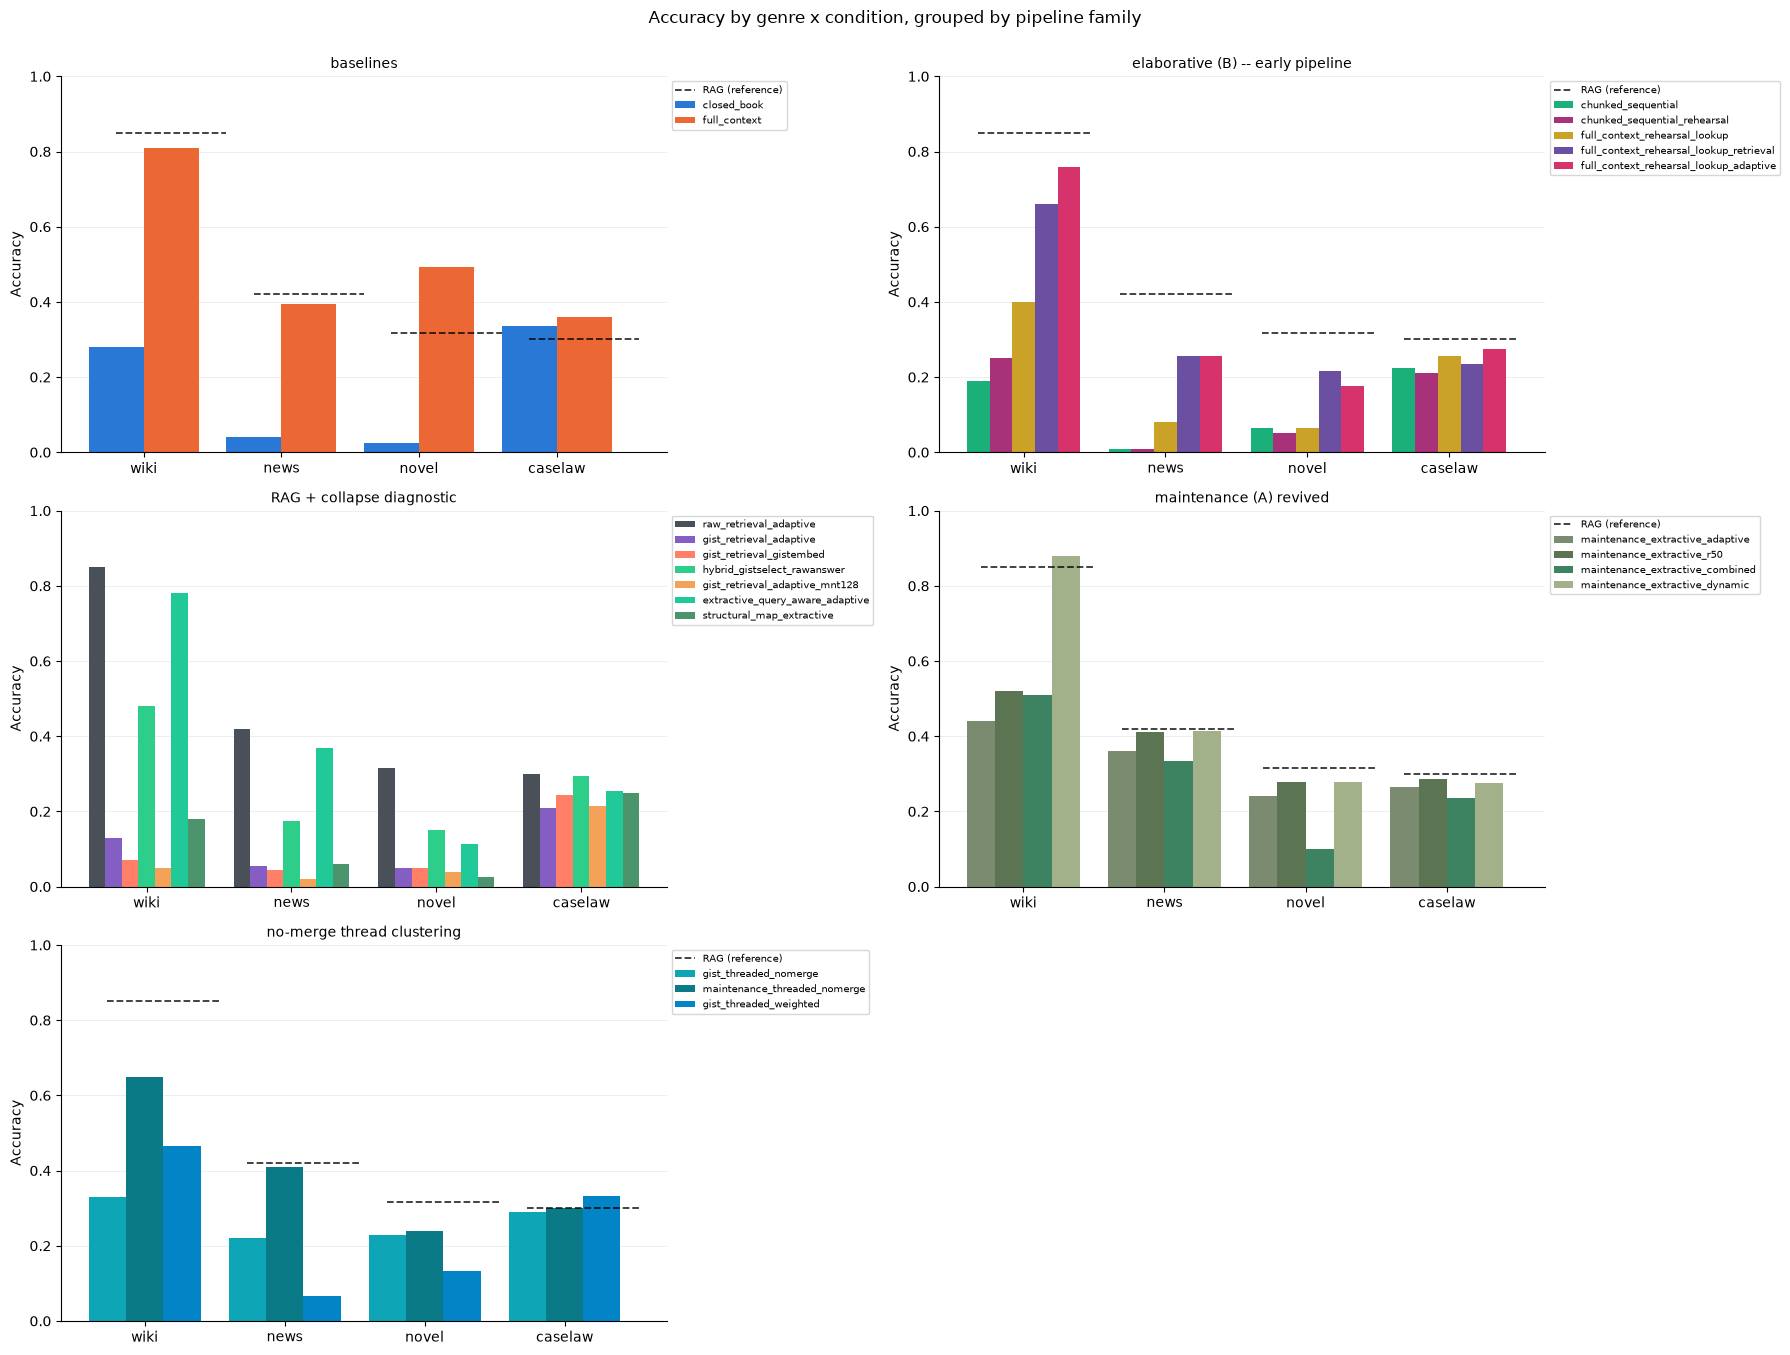

In [189]:
accuracy = combined.pivot_table(index="genre", columns="condition", values="correct", aggfunc="mean")
accuracy = accuracy.reindex(GENRE_ORDER)[[c for c in CONDITIONS_ORDER if c in accuracy.columns]]

groups_present = {name: [c for c in conds if c in accuracy.columns] for name, conds in CONDITION_GROUPS.items()}
groups_present = {name: conds for name, conds in groups_present.items() if conds}

ncols = 2
nrows = -(-len(groups_present) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 4.5 * nrows))
axes = axes.flatten()
x = list(range(len(GENRE_ORDER)))
for ax, (group_name, conds) in zip(axes, groups_present.items()):
    bar_width = 0.8 / len(conds)
    for i, condition in enumerate(conds):
        ax.bar([xi + i * bar_width for xi in x], accuracy[condition], width=bar_width,
               label=condition, color=CONDITION_COLORS[condition])
    if "raw_retrieval_adaptive" not in conds and "raw_retrieval_adaptive" in accuracy.columns:
        rag_acc = accuracy["raw_retrieval_adaptive"]
        cluster_width = bar_width * len(conds)
        added_label = False
        for xi, genre in zip(x, GENRE_ORDER):
            ax.plot([xi, xi + cluster_width], [rag_acc[genre]] * 2,
                     color="black", linestyle="--", linewidth=1.3, alpha=0.8,
                     label=None if added_label else "RAG (reference)")
            added_label = True
    ax.set_xticks([xi + bar_width * (len(conds) - 1) / 2 for xi in x])
    ax.set_xticklabels(GENRE_ORDER)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title(group_name, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))
for ax in axes[len(groups_present):]:
    ax.set_visible(False)
fig.suptitle("Accuracy by genre x condition, grouped by pipeline family", y=1.0)
plt.tight_layout()
plt.show()


## Accuracy per token — accuracy / efficiency

Divides accuracy by token cost so cheap+accurate conditions stand out.


accuracy per 10,000 tokens, by genre x condition:
condition  full_context  chunked_sequential  chunked_sequential_rehearsal  full_context_rehearsal_lookup  full_context_rehearsal_lookup_retrieval  full_context_rehearsal_lookup_adaptive  raw_retrieval_adaptive  gist_retrieval_adaptive  gist_retrieval_gistembed  hybrid_gistselect_rawanswer  extractive_query_aware_adaptive  gist_retrieval_adaptive_mnt128  structural_map_extractive  maintenance_extractive_adaptive  maintenance_extractive_r50  maintenance_extractive_combined  maintenance_extractive_dynamic  gist_threaded_nomerge  maintenance_threaded_nomerge  gist_threaded_weighted
genre                                                                                                                                                                                                                                                                                                                                                                        

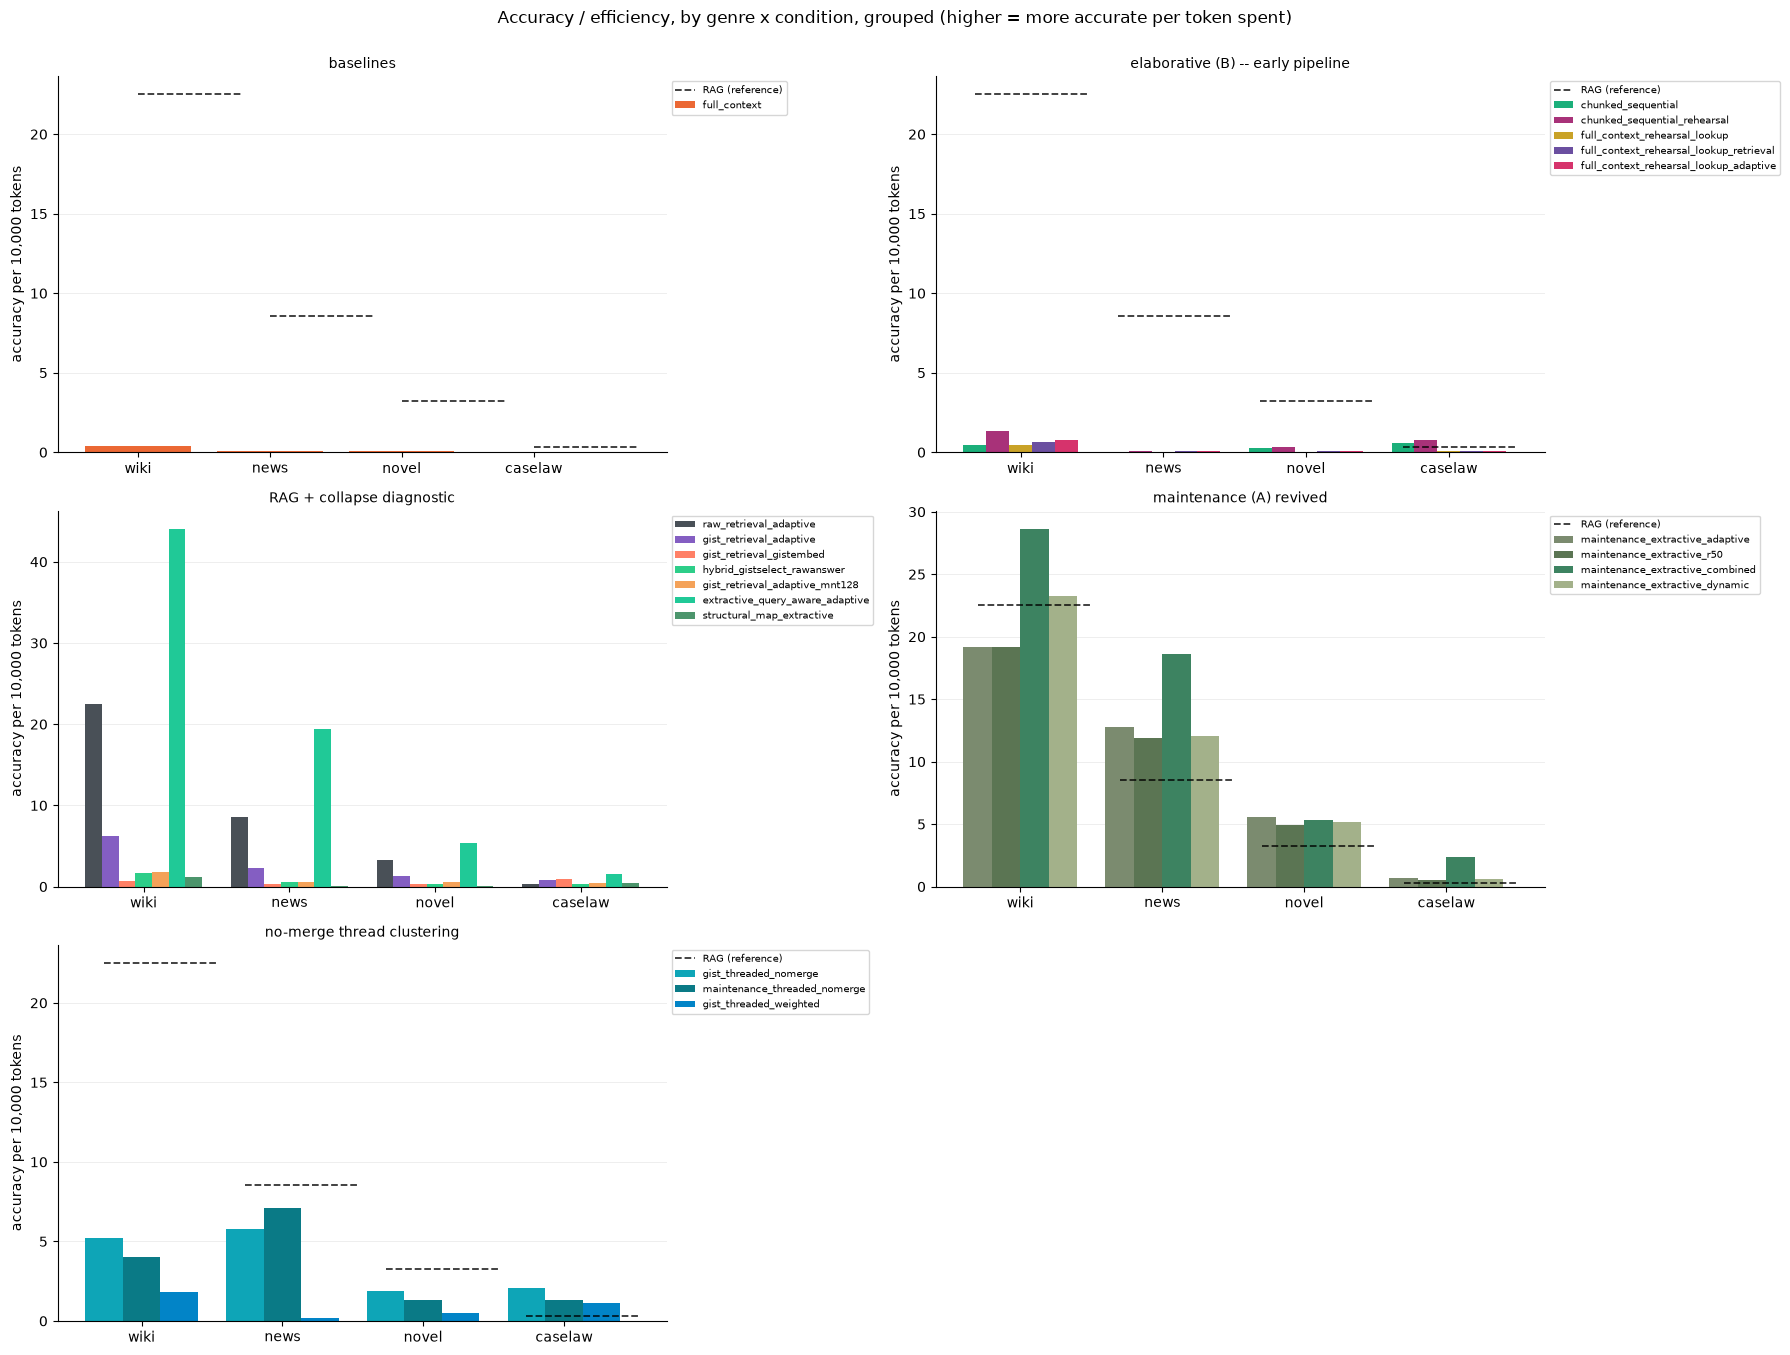

In [190]:
EFFICIENCY_CONDITIONS = [c for c in CONDITIONS_ORDER if c != "closed_book"]  # excluded: near-zero tokens makes its ratio a meaningless outlier, and it never reads the document anyway

tokens_by_genre_condition = combined.pivot_table(index="genre", columns="condition", values="total_tokens", aggfunc="mean")
tokens_by_genre_condition = tokens_by_genre_condition.reindex(GENRE_ORDER)[[c for c in EFFICIENCY_CONDITIONS if c in tokens_by_genre_condition.columns]]

# accuracy per 10,000 tokens -- raw accuracy/tokens is a tiny number (tokens are in the tens of thousands), scaled for readability
accuracy_for_efficiency = accuracy[[c for c in EFFICIENCY_CONDITIONS if c in accuracy.columns]]
accuracy_per_10k_tokens = accuracy_for_efficiency / tokens_by_genre_condition * 10_000
print("accuracy per 10,000 tokens, by genre x condition:")
print(accuracy_per_10k_tokens.round(3).to_string())

eff_groups_present = {
    name: [c for c in conds if c in accuracy_per_10k_tokens.columns]
    for name, conds in CONDITION_GROUPS.items()
}
eff_groups_present = {name: conds for name, conds in eff_groups_present.items() if conds}

ncols = 2
nrows = -(-len(eff_groups_present) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(9 * ncols, 4.5 * nrows))
axes = axes.flatten()
x = list(range(len(GENRE_ORDER)))
for ax, (group_name, conds) in zip(axes, eff_groups_present.items()):
    bar_width = 0.8 / len(conds)
    for i, condition in enumerate(conds):
        ax.bar([xi + i * bar_width for xi in x], accuracy_per_10k_tokens[condition], width=bar_width,
               label=condition, color=CONDITION_COLORS[condition])
    if "raw_retrieval_adaptive" not in conds and "raw_retrieval_adaptive" in accuracy_per_10k_tokens.columns:
        rag_eff = accuracy_per_10k_tokens["raw_retrieval_adaptive"]
        cluster_width = bar_width * len(conds)
        added_label = False
        for xi, genre in zip(x, GENRE_ORDER):
            ax.plot([xi, xi + cluster_width], [rag_eff[genre]] * 2,
                     color="black", linestyle="--", linewidth=1.3, alpha=0.8,
                     label=None if added_label else "RAG (reference)")
            added_label = True
    ax.set_xticks([xi + bar_width * (len(conds) - 1) / 2 for xi in x])
    ax.set_xticklabels(GENRE_ORDER)
    ax.set_ylabel("accuracy per 10,000 tokens")
    ax.set_title(group_name, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linewidth=0.5, alpha=0.3)
    ax.set_axisbelow(True)
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))
for ax in axes[len(eff_groups_present):]:
    ax.set_visible(False)
fig.suptitle("Accuracy / efficiency, by genre x condition, grouped (higher = more accurate per token spent)", y=1.0)
plt.tight_layout()
plt.show()


## Accuracy by evidence position in the document

chunked_sequential only sees the first 4 chunks — accuracy should fall off with evidence depth; B's memory should soften that.


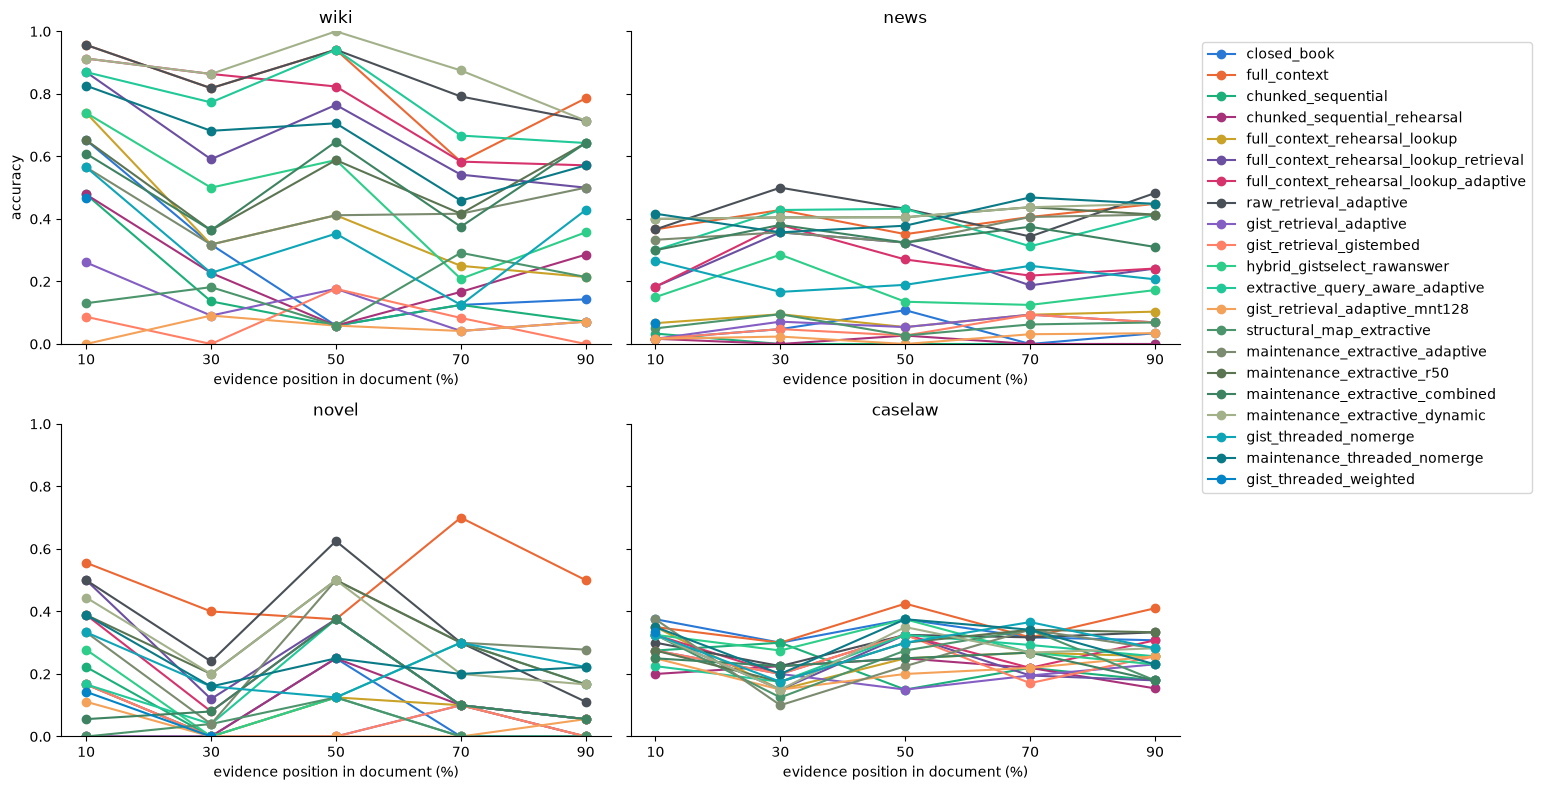

In [191]:
def evidence_fraction(genre: str, question_id) -> float | None:
    qdf = questions[genre]
    if "evidence_char_pos" not in qdf.columns:
        return None
    row = qdf[qdf["question_id"].astype(str) == str(question_id)]
    if row.empty or pd.isna(row["evidence_char_pos"].iloc[0]):
        return None
    return row["evidence_char_pos"].iloc[0] / len(corpora[genre])

combined["position_frac"] = combined.apply(
    lambda r: evidence_fraction(r["genre"], r["question_id"]), axis=1
)

bin_edges = [0, 0.2, 0.4, 0.6, 0.8, 1.0001]
bin_labels = [10, 30, 50, 70, 90]
combined["position_bin"] = pd.cut(
    combined["position_frac"], bins=bin_edges, labels=bin_labels, include_lowest=True
)

n_genres = len(GENRE_ORDER)
ncols = 2
nrows = -(-n_genres // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten()
for ax, genre in zip(axes, GENRE_ORDER):
    sub = combined[combined["genre"] == genre]
    for condition in CONDITIONS_ORDER:
        cond_sub = sub[sub["condition"] == condition]
        if cond_sub.empty:
            continue
        acc_by_bin = cond_sub.groupby("position_bin", observed=True)["correct"].mean().reindex(bin_labels)
        ax.plot(bin_labels, acc_by_bin.values, marker="o", label=condition, color=CONDITION_COLORS[condition])
    ax.set_title(genre)
    ax.set_xlabel("evidence position in document (%)")
    ax.set_xticks(bin_labels)
    ax.set_ylim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[n_genres:]:
    ax.set_visible(False)
axes[0].set_ylabel("accuracy")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.0, 0.95))
plt.tight_layout()
plt.show()

## Efficiency by genre, across methods

Same read as `03`'s efficiency table, extended to the new conditions.

avg tokens / question, by genre x condition (for reference -- the plot below shows 10,000/this):
condition  full_context  chunked_sequential  chunked_sequential_rehearsal  full_context_rehearsal_lookup  full_context_rehearsal_lookup_retrieval  full_context_rehearsal_lookup_adaptive  raw_retrieval_adaptive  gist_retrieval_adaptive  gist_retrieval_gistembed  hybrid_gistselect_rawanswer  extractive_query_aware_adaptive  gist_retrieval_adaptive_mnt128  structural_map_extractive  maintenance_extractive_adaptive  maintenance_extractive_r50  maintenance_extractive_combined  maintenance_extractive_dynamic  gist_threaded_nomerge  maintenance_threaded_nomerge  gist_threaded_weighted
genre                                                                                                                                                                                                                                                                                                                         

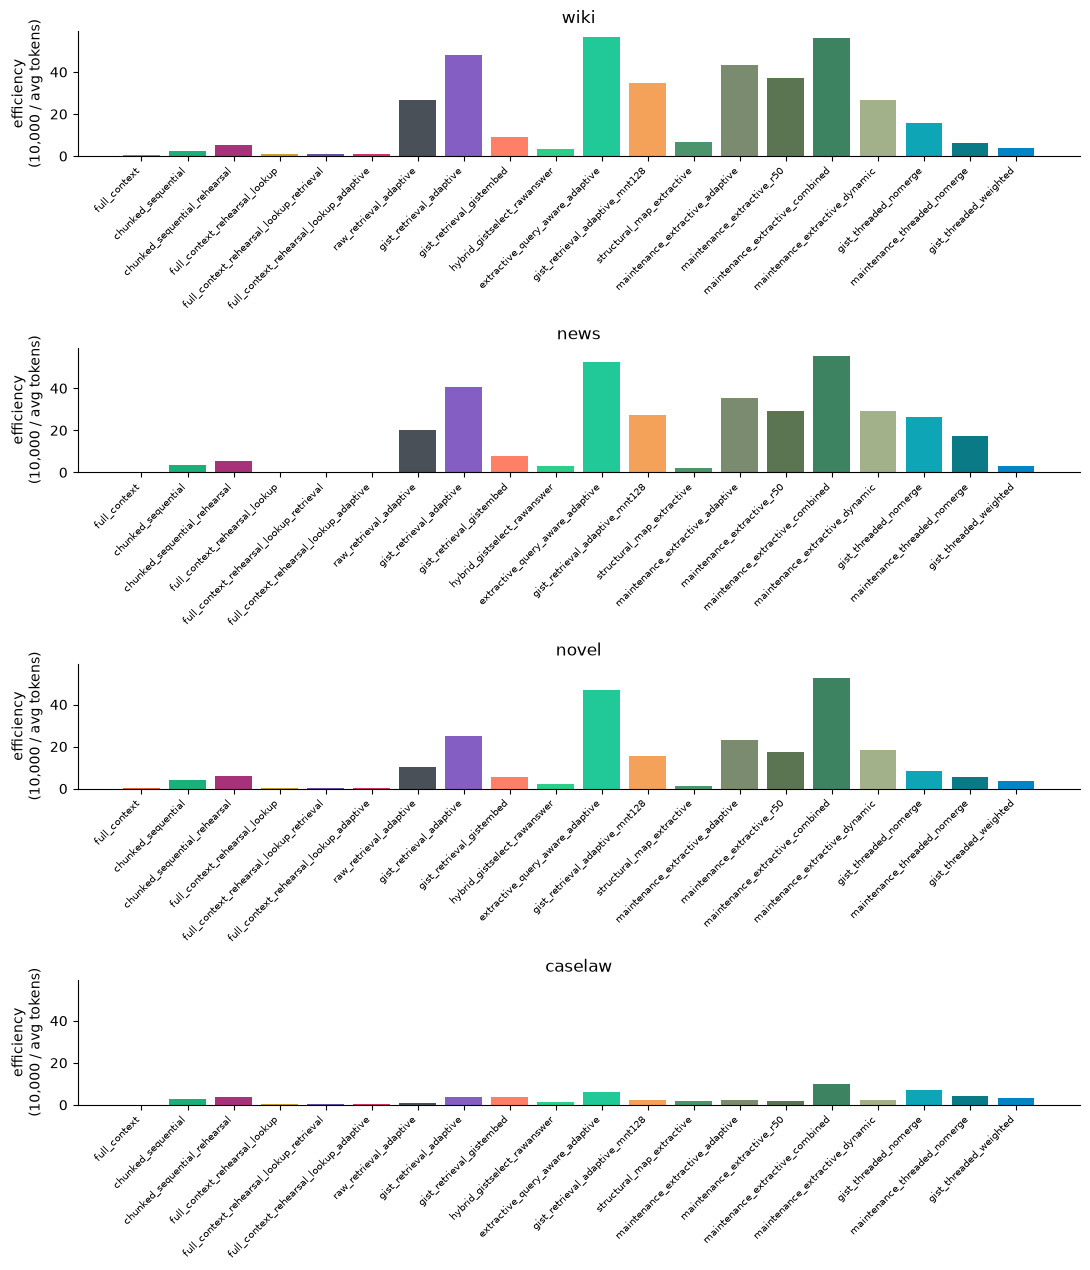

In [192]:
efficiency = combined.groupby(["genre", "condition"]).agg(
    avg_tokens=("total_tokens", "mean"),
    avg_api_calls=("api_calls", "mean"),
    avg_seconds=("elapsed_seconds", "mean"),
).reset_index()
# higher = cheaper, same 10,000-token scaling as the "accuracy per token" cell
# above -- closed_book is excluded (EFFICIENCY_CONDITIONS) for the same reason
# it's excluded there: ~100 tokens inverts into a score that dwarfs everything else
efficiency["efficiency_score"] = 10_000 / efficiency["avg_tokens"]

tokens_table = efficiency.pivot_table(index="genre", columns="condition", values="avg_tokens")
tokens_table = tokens_table.reindex(GENRE_ORDER)[[c for c in EFFICIENCY_CONDITIONS if c in tokens_table.columns]]
print("avg tokens / question, by genre x condition (for reference -- the plot below shows 10,000/this):")
print(tokens_table.round(0).to_string())

n_genres = len(GENRE_ORDER)
ncols = 1
nrows = n_genres
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.2 * nrows), sharey=True)
axes = axes.flatten()
for ax, genre in zip(axes, GENRE_ORDER):
    sub = efficiency[efficiency["genre"] == genre].set_index("condition").reindex(
        [c for c in EFFICIENCY_CONDITIONS if c in efficiency["condition"].unique()]
    )
    ax.bar(range(len(sub)), sub["efficiency_score"], color=[CONDITION_COLORS[c] for c in sub.index])
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub.index, rotation=45, ha="right", fontsize=7)
    ax.set_title(genre)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylabel("efficiency\n(10,000 / avg tokens)")
# 2026-08-14: plots 10,000/avg_tokens instead of raw avg_tokens so a taller bar
# means "better" here too, matching every other chart in this notebook -- raw
# token counts were the one place a taller bar meant worse. Exact token counts
# are in the printed table above, not on the bars, to avoid re-crowding labels
# right after the §14 legibility pass.
plt.tight_layout()
plt.show()

## Efficiency by method, across genres

Same numbers as the prior plot, transposed — spot cost outliers by genre.


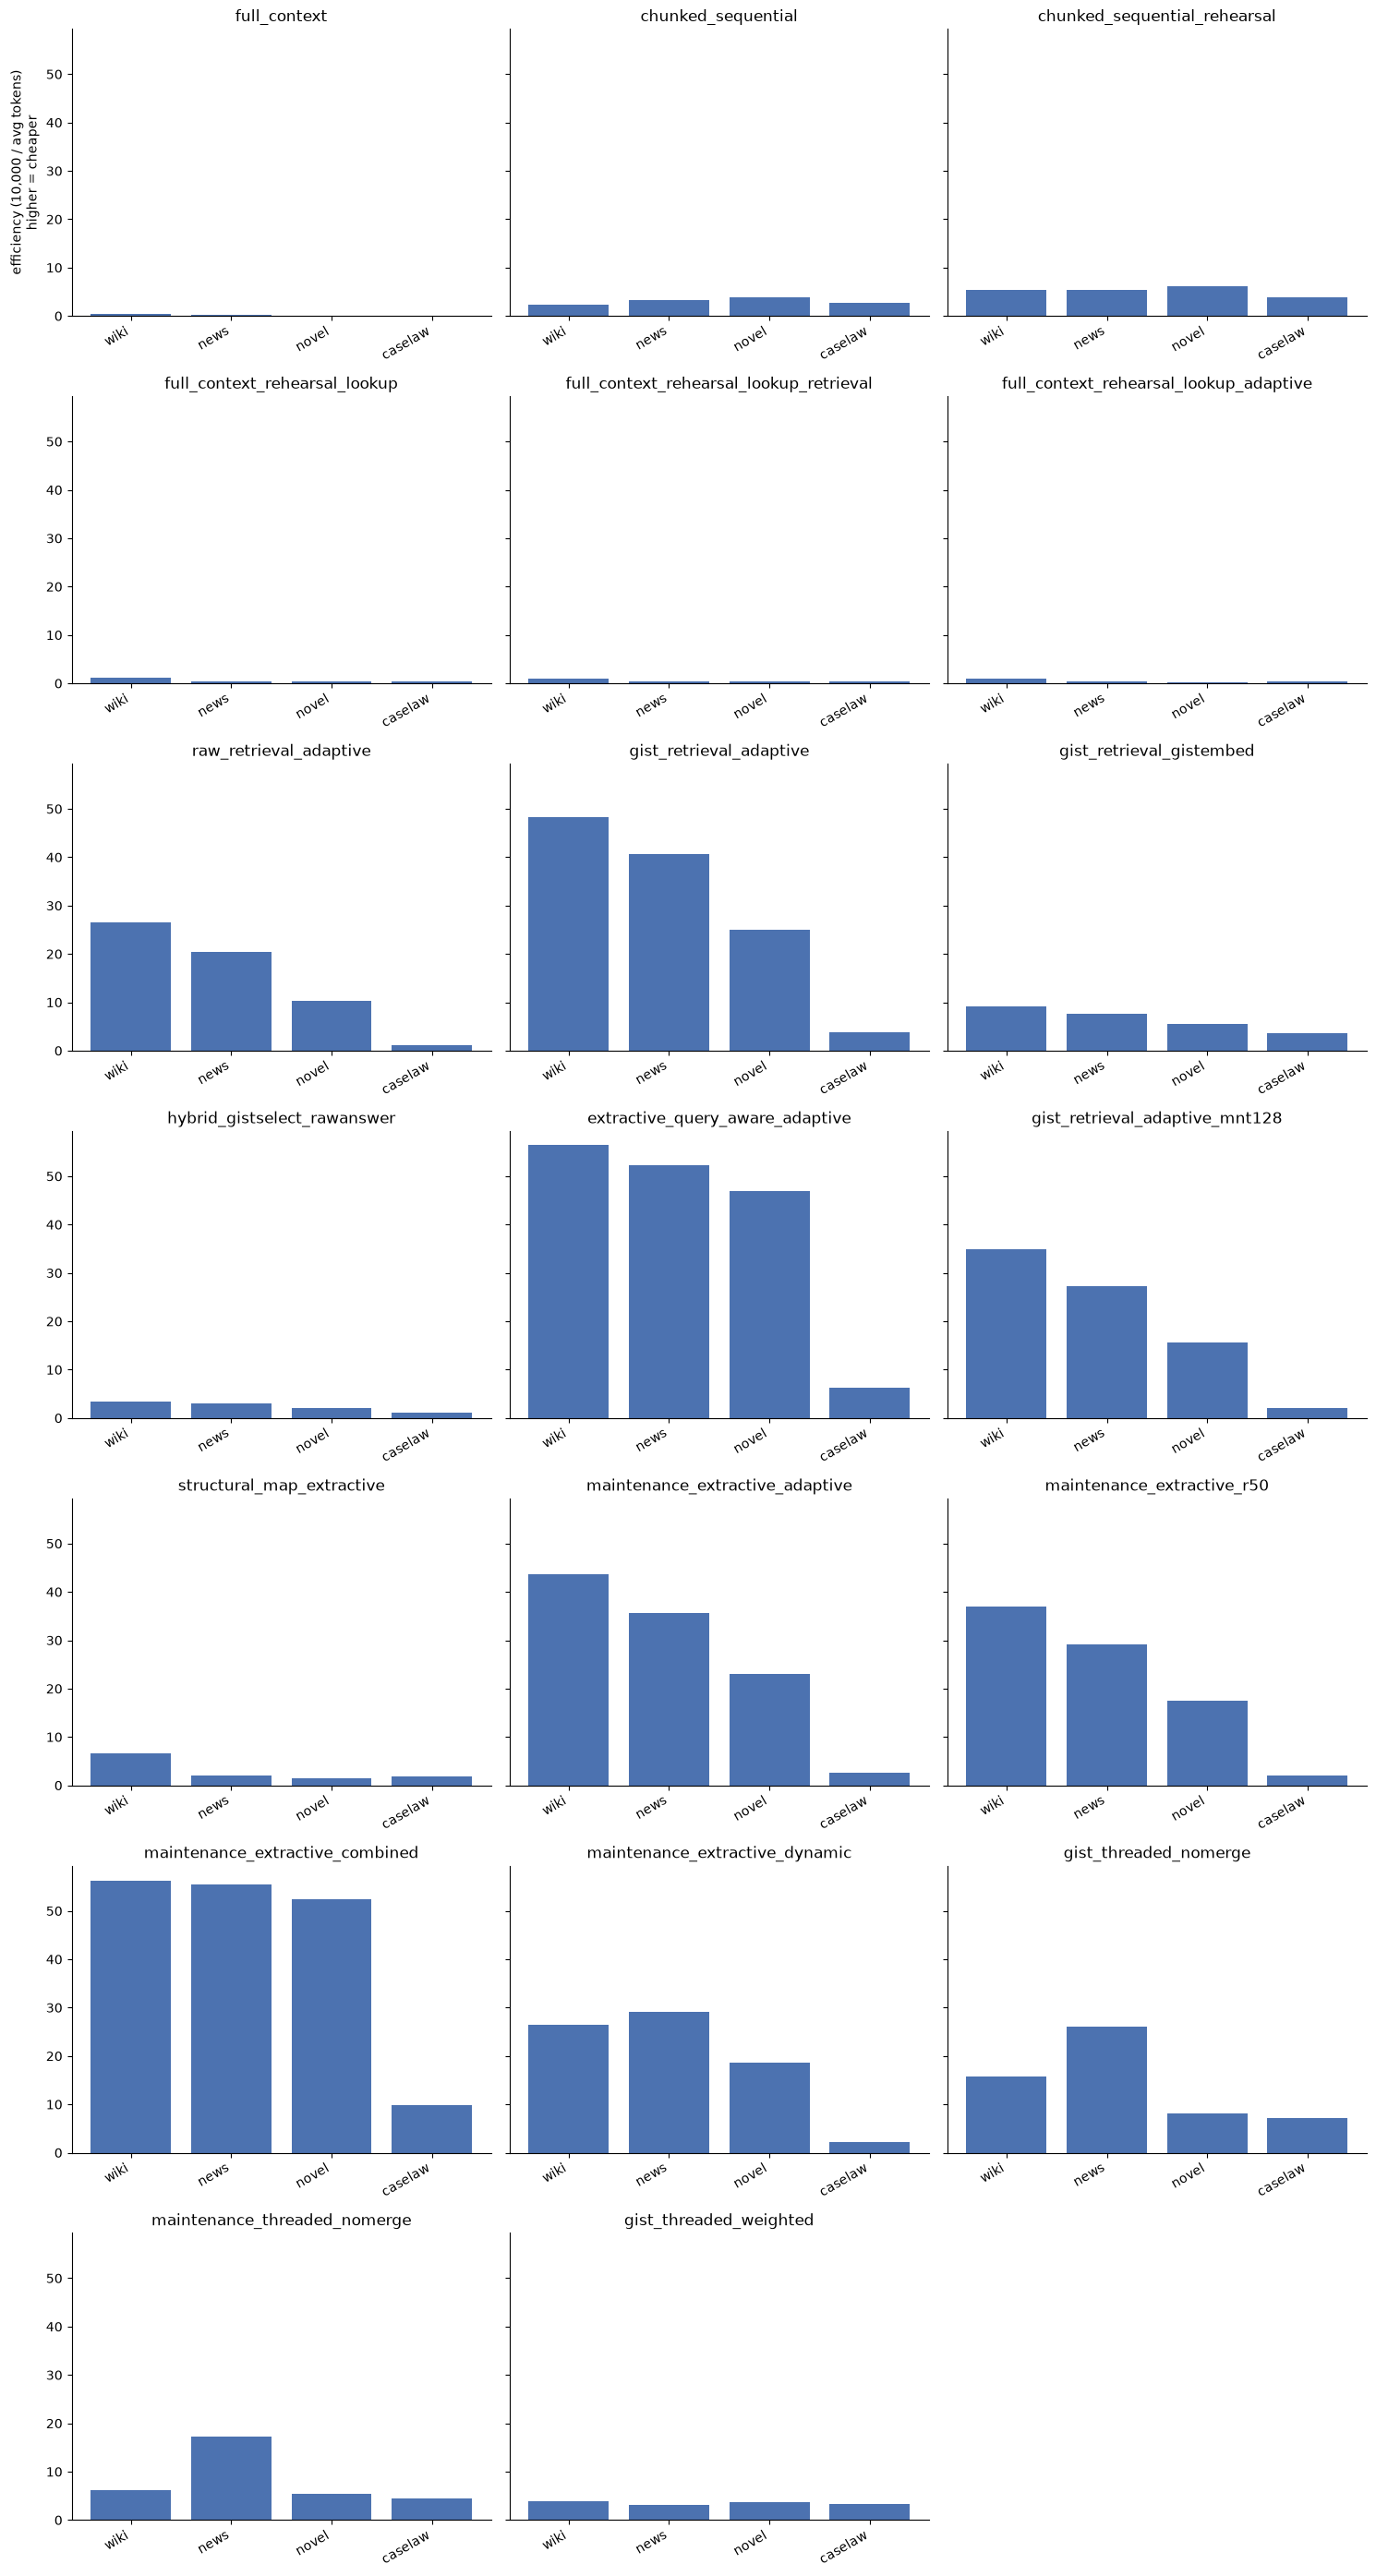

In [193]:
conditions_present = [c for c in EFFICIENCY_CONDITIONS if c in efficiency["condition"].unique()]

n_cond = len(conditions_present)
ncols = min(3, n_cond)  # up to 3 per row
nrows = -(-n_cond // ncols)  # ceil
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
axes = axes.flatten() if n_cond > 1 else [axes]
for ax, condition in zip(axes, conditions_present):
    sub = efficiency[efficiency["condition"] == condition].set_index("genre").reindex(GENRE_ORDER)
    ax.bar(range(len(sub)), sub["efficiency_score"], color="#4c72b0")
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub.index, rotation=30, ha="right")
    ax.set_title(condition)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[n_cond:]:
    ax.set_visible(False)
axes[0].set_ylabel("efficiency (10,000 / avg tokens)\nhigher = cheaper")
# Same score as the prior plot (higher = cheaper), transposed -- spot cost
# outliers by genre without the polarity flip raw tokens would need.
plt.tight_layout()
plt.show()

## Summary

**8 conditions total.** Headline result (2026-08-13, full scale n=579 unless noted): pure RAG (`raw_retrieval_adaptive` — no rehearsal, no teacher, single-call raw-text retrieval) beats every rehearsal-family condition on every genre, using 3-55x fewer tokens than `full_context_rehearsal_lookup_adaptive`.

| # | condition | idea | status |
|---|---|---|---|
| 1 | `chunked_sequential_rehearsal` | B's gist, same 4-chunk budget as uncompressed control | full scale (579) |
| 2 | `full_context_rehearsal_lookup` | full gist map + raw-text lookup (ReadAgent-P) | full scale (579) |
| 3 | `full_context_rehearsal_lookup_retrieval` | + embedding-similarity targeting | full scale (579) |
| 4 | `full_context_rehearsal_lookup_adaptive` | fixed top-K → similarity-distribution-driven selection | full scale (579) |
| 5 | `raw_retrieval_adaptive` | pure RAG floor — same Adaptive-k selection, raw text, no rehearsal anywhere | full scale (579) |
| 6 | `gist_retrieval_adaptive` | condition 5's architecture, gist content instead of raw | full scale (579) |
| 7 | `gist_retrieval_gistembed` | condition 6 + selection also by gist embeddings (not raw-text) | full scale (579) |
| 8 | `hybrid_gistselect_rawanswer` | selection by gist embeddings, answer from raw text — the one selection x content combination 5-7 didn't test | full scale (579) — loses to condition 5 on accuracy (0.266 vs 0.439) AND tokens (5,364 vs 3,588); gist embeddings are a worse retriever, not a better one |
| 9 | `extractive_query_aware_adaptive` | condition 5's chunk selection, then extractive (verbatim) + query-aware sentence pruning within selected chunks — RAPTOR/EXIT/LongLLMLingua-inspired | pilot/pending |

**Why conditions 5-7 exist**: condition 4 always pays for showing the *full* document's gist map on its first call, win or lose — a structural cost/architecture confound separate from whether rehearsed *content* itself helps. Condition 5 removes rehearsal entirely (architecture control). Condition 6 swaps only the content (gist vs raw) at the same single-call architecture — it loses on every genre, even to condition 4, meaning gist's survival in condition 4 comes from its raw-text lookup escape hatch, not the gist itself. Condition 7 rules out a selection-mismatch confound (gist-embedding selection vs raw-text-embedding selection) — near-identical to condition 6, so the loss is content quality, not retrieval mismatch.

**Teacher-gist ceiling test** (separate script, `results/teacher_gists_by_genre_pilot.json`, n=30 chunks/genre prefix pilot, 2026-08-13): even meta/llama-3.1-70b-instruct, run through the same thread-retrieve-replace mechanism condition 1-4's gists were built with, doesn't reliably compress — wiki/novel gists came out *longer* than the source (192%/148% word ratio) with visible topic drift on at least one inspected wiki chunk (retrieved-thread content dominating over the actual new chunk's content). Suggests the bottleneck may be the retrieve-and-replace architecture itself, not compressor model size — not yet confirmed at full scale.

**Cost framing**: the deployed pipeline gists with t5-small (local, not API-metered), so rehearsal conditions' *token* cost is already lower than RAG's from the first query (gist_retrieval_adaptive: 1,105 avg tokens/question vs RAG's 3,588) — there is no break-even point to compute, because rehearsal carries no amortizable per-query API cost to offset. The tradeoff is accuracy-for-tokens, not cost-crossing-over-time; see §"Accuracy per token" above for the current numbers across all 8 conditions.

**Caselaw caveat**: `<HOLDING>` artifact removed and offset-corrected (2026-08-12) — conditions 2/3/4 re-evaluated, the "wider retrieval hurts caselaw" pattern moved <0.03 across the board, so the artifact does not explain it.

**Scope**: A (maintenance rehearsal) and A→B are permanently out of scope (2026-08-12 decision). B (elaborative) only.
